NYC Yellow Taxi — Full Validation & Audit Pipeline for February 2025 Data
by Sebastian Löffler & Stefan Ganschow

Summary / Lessons Learned / Open topics

DataWrangler

Date Cleansing
- teilweise gibt es klare "Bereinigungen" teilweise gibt es Klärungsbedarf aufgrund unterschiedlicher Sichtweisen / Annahmen
- negative werte exkludiert und nicht bereinigt. Verbesserungsvorschlag: Korrekturwerte mit Link zum initialen "falschen" Datensatz via trip_id etc. evtl. mit Begründung der Korrekturwerte
- non-destructive: flagging für Verlustfreiheit, Nachverfolgung, Audit, etc. Nachteil der Datenmenge und Performance initial OK. evtl. zu einem späteren Zeitpunkt droppen damit ML performanter ist. 

Reporting
- Standard Output vs. Interquartile Range (IQR)
- report flag vs. create flag vs. explicit flag

Gesamtumsatz pro Taximeter (vendor_id) 
- Darstellung der Daten mit vs. ohne log Skala
- Darstellung der Original Werte vs. Bereinigte Werte  
- Für uns Klärungsbedarf mit Stakeholdern um eine einheitliche Sicht zu haben und unterschiedliche Annahmen auszuschließen. 

Für bessere Vorhersagen: evtl. Segmentierung der ML: Kernmodel (Standard City), Spezialisiertes Modell (Geografisches Model mit spezifischen Orten z.B. Midtown, Financial District), Flatrate Modell (Flughafen, Flex Fare, etc.)
- durch den Split wird man mit Sicherheit weitere Features entdecken (Stadtverkehr vs. Highway, Stau, Bauabschnitte, Unfälle, Events, etc.)
- wir betrachten nur trips die kein Fixpreis bzw. negotiated sind!

ML spezifisch
- One-Hot Encoding
- Heteroskedastizität

Data Leackage
- K-fold data leackage?!?!
- Berechnungen basierend auf dem gesamten DF (falsch) vs. basierend auf dem aktuellen Trainingsfold (richtig)
Feature Importance
- PU und DO locations

Laufzeiten und Ergebnisse der verschiedenen Splits und ML Modelle im Generellen und auch auf verschiedenen Rechnern (MAC vs. WIN PC)




Loading Data

In [1]:
# ---------------------------------------------------------------------
# NYC Yellow Taxi — Full Validation & Audit Pipeline for February 2025 Data
# ---------------------------------------------------------------------

# Core Data Handling and Analysis Libraries
import pandas as pd # Used for data manipulation and analysis, primarily with DataFrames and Series.
import numpy as np  # Used for numerical operations, especially with arrays and mathematical functions.

# Scikit-learn (sklearn) - Machine Learning Library
# Modules for Model Selection and Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, KFold 
# train_test_split: Splits data into training and testing sets.
# cross_val_score: Performs cross-validation on a model.
# KFold: Provides train/test indices to split data in K folds.

# Module for Data Preprocessing
from sklearn.preprocessing import StandardScaler # Used to standardize features by removing the mean and scaling to unit variance.

# Modules for Machine Learning Models (Regression)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor 
# RandomForestRegressor: An ensemble method for regression based on decision trees.
# GradientBoostingRegressor: Another ensemble method that builds trees sequentially, trying to correct previous errors.

from sklearn.linear_model import LinearRegression # A simple model for linear regression.

# Modules for Model Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# mean_absolute_error (MAE): Measures the average magnitude of the errors.
# mean_squared_error (MSE): Measures the average of the squares of the errors.
# r2_score (R-squared): Represents the proportion of the variance for a dependent variable that's explained by the independent variables.

# Data Visualization Libraries
import matplotlib.pyplot as plt # A foundational library for creating static, interactive, and animated visualizations in Python.
import seaborn as sns           # A high-level interface for drawing attractive and informative statistical graphics, often built on matplotlib.

# System and Utility Libraries
import os       # Provides a way of interacting with the operating system, useful for file path management.
import requests # A library for making HTTP requests, often used to download data from the web.

# Load the trip data from a local Parquet file 
data_file_path = os.path.expanduser("~/Downloads/TripData/yellow_tripdata_2025-02.parquet")
df = pd.read_parquet(data_file_path)

# ensure df exists
try:
    df
except NameError:
    raise RuntimeError("Please load your dataframe into the variable `df` before running this cell.")

# copy to avoid modifying user's original reference
df = df.copy()
INITIAL_ROWS = len(df)
print(f"Initial loaded rows: {INITIAL_ROWS:,} (100.00%)\nInfo:\n")

# Display initial DataFrame info and check for missing values
df.info(show_counts=True)
missing_values_count = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values_count[missing_values_count > 0])

# Load taxi zone lookup table
zone_file_path = r"C:\Users\Stefan\Documents\work\Studium\GitHub\Gansch83\Projektarbeit-NYC-yc-taxi\taxi_zone_lookup.csv"
zone_lookup = pd.read_csv(zone_file_path)
print("\nTaxi Zone Lookup Table loaded")

Initial loaded rows: 3,577,543 (100.00%)
Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3577543 entries, 0 to 3577542
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VendorID               3577543 non-null  int32         
 1   tpep_pickup_datetime   3577543 non-null  datetime64[us]
 2   tpep_dropoff_datetime  3577543 non-null  datetime64[us]
 3   passenger_count        2770606 non-null  float64       
 4   trip_distance          3577543 non-null  float64       
 5   RatecodeID             2770606 non-null  float64       
 6   store_and_fwd_flag     2770606 non-null  object        
 7   PULocationID           3577543 non-null  int32         
 8   DOLocationID           3577543 non-null  int32         
 9   payment_type           3577543 non-null  int64         
 10  fare_amount            3577543 non-null  float64       
 11  extra                  3577543 non-null  

CONFIGURABLE THRESHOLDS / ALLOWED VALUES

In [2]:
# --------- CONFIGURABLE THRESHOLDS / ALLOWED VALUES ----------
REPORTING_YEAR = 2025                       # Update as needed
REPORTING_MONTH = 2                         # Update as needed
# --------- Domain Validation First ---------
ALLOWED_VENDOR_IDS = {1, 2, 6, 7}
VENDOR_ID_NAMES = {1: "Creative Mobile Technologies, LLC", 2: "Curb Mobility, LLC",
                   6: "Myle Technologies Inc", 7: "Helix"}
# ALLOWED_RATECODES = {1,2,3,4,5,6,99}
ALLOWED_RATECODES = {1}  # only Standard rate to be used for trips PREDICTION within NYC
RATECODES_NAMES = {1: "Standard rate", 2: "JFK", 3: "Newark", 4: "Nassau or Westchester", 
                   5: "Negotiated fare", 6: "Group ride", 99: "Null/unknown"}
# ALLOWED_PAYMENT_TYPES = {0,1,2,3,4,5,6}
ALLOWED_PAYMENT_TYPES = {1,2}             # only the relevant once to be considered
PAYMENT_TYPE_NAMES = {0: "Flex Fare trip", 1: "Credit card", 2: "Cash", 3: "No charge", 
                      4: "Dispute", 5: "Unknown", 6: "Voided trip"}
ALLOWED_LOCATIONS = np.arange(1,266)        # allowed locations from 1 to 265, 264-N/A, 265-Outside of NYC

MIN_TRIP_DURATION = 1                       # in minutes
MAX_TRIP_DURATION = 300                     # in minutes (5 hours)  
MIN_PASSENGERS = 1                          # NYC taxis have a min of 1 passenger
MAX_PASSENGERS = 5                          # NYC taxis have a max of 4 passengers (STD) 5 passengers (Van)
MIN_TRIP_DISTANCE = 0.1                     # in miles
MAX_TRIP_DISTANCE = 50                      # NYC trips are usually short

# --------- NYC Taxi Fare Structure (as of June 2024) ----------
# Source: https://www.nyc.gov/site/tlc/passengers/taxi-fare.page
MIN_FARE = 3.50                             # Initial charge (up from $3.00)
MAX_FARE = 500.00                           # Long trips possible
# Fare per mile validation bounds
# At normal speed: $0.70 * 5 = $3.50/mile
# In heavy traffic with waiting time: can be higher
FARE_PER_MILE_MIN = 2.0                     # Allow for distance-heavy trips
FARE_PER_MILE_MAX = 25.0                    # Allow for time-heavy trips (traffic/waiting)

MAX_TIP = 1000
MAX_TIP_TO_FARE_RATIO = 2.0                 # tip should not exceed 200% of fare

MAX_TOLL = 50.00                            # tolls can be high for bridges/tunnels

MAX_TOTAL_AMOUNT = 1500.0                   # max allowed total amount
MAX_TOLERANCE_TOTAL_AMOUNT = 2.0            # max difference between actual and computed total amount

ALLOWED_MTA = {0.0, 0.5}
ALLOWED_IMPROVEMENT_SURCHARGE = {1.0}
ALLOWED_CONGESTION_SURCHARGE = {0.0, 2.50}
ALLOWED_CBD_CONGESTION_SURCHARGE = {0.0, 0.75}

# NYC Airport Location IDs
JFK_LOCATION_IDS = [132]
LGA_LOCATION_IDS = [138]
EWR_LOCATION_IDS = [1]

NYC_BOROUGHS = {"Manhattan", "Brooklyn", "Bronx", "Queens", "Staten Island"}

# JFK Flat Fare: $70.00 (excludes tolls, taxes, tip, surcharges)
# The fare_amount field should be $70.00 for flat fare trips
# Additional charges are in separate fields (mta_tax, improvement_surcharge, etc.)
JFK_MANHATTAN_FLAT_FARE_BASE = 70.00

# Airport fees
AIRPORT_ACCESS_FEE = 1.75
LGA_SURCHARGE = 5.0
EWR_SURCHARGE = 20.0                            # Not in Airport_fee field
LGA_TRIPS = AIRPORT_ACCESS_FEE + LGA_SURCHARGE  # $6.75
RUSH_HOUR_SURCHARGE_AIR = 5.0                   # Airport rush hour (4pm-8pm weekdays, excluding holidays)
ALLOWED_AIRPORT_FEES = [0.00, AIRPORT_ACCESS_FEE, LGA_SURCHARGE, RUSH_HOUR_SURCHARGE_AIR, LGA_TRIPS, AIRPORT_ACCESS_FEE + RUSH_HOUR_SURCHARGE_AIR]

# Standard trip surcharges (goes in 'extra' field)
OVERNIGHT_SURCHARGE = 1.0                       # 8pm-6am daily
RUSH_HOUR_SURCHARGE_STD = 2.5                   # 4pm-8pm weekdays (excluding holidays)
BOTH_SURCHARGES = OVERNIGHT_SURCHARGE + RUSH_HOUR_SURCHARGE_STD  # Rare overlap at 8pm
ALLOWED_EXTRA_VALUES = {0.0, OVERNIGHT_SURCHARGE, RUSH_HOUR_SURCHARGE_STD, BOTH_SURCHARGES}

# Weather API configuration
OPENWEATHER_API_KEY = "YOUR_API_KEY_HERE"   # Replace with your actual API key (key after fetching de-activated)
lat, lon = 40.7580, -73.9855                # NYC coordinates (Times Square)

# Federal holidays in February 2025 (for rush hour surcharge exemptions), reading excel file is avoided for simplicity
# This comment explains the purpose of the list: defining federal holidays, 
# which are often used to exempt rush hour surcharges in certain business models (like ride-sharing or tolls).

FEDERAL_HOLIDAYS_2025 = pd.to_datetime([
    # Converts the list of date strings into pandas datetime objects.
    # This is crucial for easy date comparisons and filtering in pandas DataFrames later on.
    
    "2025-01-01", # New Year's Day
    "2025-01-20", # Martin Luther King, Jr.'s Birthday
    "2025-02-17", # Washington's Birthday (Presidents' Day) - Relevant for the 'February 2025' context in the original comment
    "2025-05-26", # Memorial Day
    "2025-06-19", # Juneteenth National Independence Day
    "2025-07-04", # Independence Day
    "2025-09-01", # Labor Day
    "2025-10-13", # Columbus Day
    "2025-11-04", # Election Day (Often treated as a holiday in some contexts, but note: Federal Election Day is Nov 5th if not a Tuesday)
    "2025-11-11", # Veterans Day
    "2025-11-27", # Thanksgiving Day (This is the actual date for 2025)
    "2025-12-25"  # Christmas Day
]) 
# The variable FEDERAL_HOLIDAYS_2025 now holds a pandas DatetimeIndex or Series 
# of the specified federal holidays, making it efficient for date-based lookups.


enhancement_flag = []   # additional informations/columns
reporting_flags = []    # all flags created for reporting
explicit_flags = []     # only explicitly created flags

# --------- REPORT SETTINGS ----------
MAX_DISPLAY_ROWS = 20  # max rows to show when printing unique values

#METERED_RATE_PER_FIFTH_MILE = 0.70          # $0.70 per 1/5 mile when traveling above 12mph
#METERED_RATE_PER_MINUTE = 0.70              # $0.70 per 60 seconds in slow traffic or when stopped

Helper Functions

In [3]:
# --------- UTILITY FUNCTIONS FOR DATA QUALITY CHECKS ----------
def pct_str(count, total):
    """
    Return formatted string with count and percentage of total.
    Parameters:
    - count: Number of flagged rows
    - total: Total number of rows
    """
    if total > 0:
        percentage = (count / total * 100)
        return f"{count:,} ({percentage:>6.2f}%)"
    else:
        return f"{count:,} (  N/A%)"

def report_flag(flag_col):
    """
    Print formatted report of a flag column with aligned output.
    Parameters:
    - flag_col: Name of the boolean flag column in df
    """
    try:
        n = int(df[flag_col].sum())
        # Dynamic width: at least 40 chars, but expand if flag name is longer
        max_name_width = max(len(flag_col), 40)
        # Add to reporting_flags if not already there
        if flag_col not in reporting_flags:
            reporting_flags.append(flag_col)
        print(f"{flag_col:<{max_name_width}} : {pct_str(n, INITIAL_ROWS)} flagged")
    except KeyError:
        print(f"⚠️  Warning: Flag column '{flag_col}' does not exist in dataframe")
    except Exception as e:
        print(f"⚠️  Error reporting flag '{flag_col}': {str(e)}")

def create_flag(name, cond, explicit=True):
    """
    Create a boolean flag column in the dataframe based on a condition.
    Parameters:
    - name (str): Base name for the flag column
    - cond (pd.Series): Boolean Series where True indicates valid rows
    - explicit (bool): If True, add to explicit_flags list
    Returns:
    - str: Name of the created flag column
    """
    # Validate input
    if not isinstance(cond, pd.Series):
        raise TypeError(f"Condition must be a pandas Series, got {type(cond)}")
    
    if len(cond) != len(df):
        raise ValueError(f"Condition length ({len(cond)}) doesn't match dataframe length ({len(df)})")
    
    # Create flag column
    col = f"is_invalid_{name}"
    
    # Check if column already exists
    if col in df.columns:
        print(f"⚠️  Warning: Overwriting existing flag column '{col}'")
    
    df[col] = ~cond  # Invert: True in flag means invalid
    
    # Report the flag (this adds it to reporting_flags)
    report_flag(col)
    
    # Add to explicit_flags if this is a filtering flag
    if explicit:
        if col not in explicit_flags:
            explicit_flags.append(col)

    return col

def print_unique_values(column_name, sort_by="count", sort="asc"):
    """
    Print overview of unique values in a DataFrame column with flexible sorting.
    Parameters:
    - column_name (str): Name of the column to analyze in df.
    - sort_by (str): 'count' to sort by frequency, 'value' to sort by unique values.
    - sort (str): 'asc' for ascending, 'desc' for descending sort order.
    """
    unique_values = df[column_name].unique()
    print(f"=== Unique {column_name} Values ===")

    has_nan = df[column_name].isna().any()
    non_nan_values = [v for v in unique_values if not pd.isna(v)]

    total_unique = len(non_nan_values) + (1 if has_nan else 0)

    if total_unique > MAX_DISPLAY_ROWS:
        print(f"  Total unique values: {total_unique} (showing top {MAX_DISPLAY_ROWS})")
        value_counts = df[column_name].value_counts(dropna=True)

        # Apply sorting based on parameters
        if sort_by == "count":
            value_counts = value_counts.sort_values(ascending=(sort == "asc")).head(MAX_DISPLAY_ROWS)
        elif sort_by == "value":
            try:
                # Try to sort indices (unique values)
                sorted_index = sorted(value_counts.index, reverse=(sort=="desc"))
                value_counts = value_counts.loc[sorted_index].head(MAX_DISPLAY_ROWS)
            except TypeError:
                # Mixed types fallback: sort as strings
                sorted_index = sorted(value_counts.index, key=str, reverse=(sort=="desc"))
                value_counts = value_counts.loc[sorted_index].head(MAX_DISPLAY_ROWS)

        for value, count in value_counts.items():
            print(f"  {value}: {count:,} rows")
    else:
        if sort_by == "count":
            value_counts = df[column_name].value_counts(dropna=True)
            value_counts = value_counts.sort_values(ascending=(sort == "asc"))
            for value, count in value_counts.items():
                print(f"  {value}: {count:,} rows")
        elif sort_by == "value":
            try:
                sorted_values = sorted(non_nan_values, reverse=(sort=="desc"))
            except TypeError:
                sorted_values = sorted(non_nan_values, key=str, reverse=(sort=="desc"))
            for value in sorted_values:
                count = df[df[column_name] == value].shape[0]
                print(f"  {value}: {count:,} rows")

    if has_nan:
        count = df[column_name].isna().sum()
        print(f"  NaN: {count:,} rows")

    print("*******************************************")

def fetch_weather_data_openweather_hourly(date, api_key):
    """
    Fetch historical weather data from OpenWeatherMap API for a specific date.
    Makes 24 separate API calls (one per hour) to get complete hourly data.
    
    Args:
        date: datetime.date object (unique day)
        api_key: OpenWeatherMap API key
    
    Returns:
        list of dicts, one per hour (24 records) or None if all requests fail
    """
    
    from datetime import datetime, timedelta
    
    hourly_records = []
    
    # Loop through all 24 hours of the day
    for hour in range(24):
        # Create datetime for this specific hour
        hour_dt = datetime.combine(date, datetime.min.time()) + timedelta(hours=hour)
        dt_timestamp = int(hour_dt.timestamp())
        
        # API endpoint for historical data
        url = "https://api.openweathermap.org/data/3.0/onecall/timemachine"
        
        params = {
            'lat': lat,
            'lon': lon,
            'dt': dt_timestamp,
            'appid': api_key,
            'units': 'metric',
            'lang': 'en'
        }
        
        try:
            response = requests.get(url, params=params, timeout=10)
            
            if response.status_code == 200:
                data = response.json()
                
                # ✅ Extract ALL available fields from API response
                if 'data' in data and len(data['data']) > 0:
                    hour_data = data['data'][0]  # First (and only) record for this timestamp
                    
                    record = {
                        # Timestamp fields
                        'date': date,
                        'datetime': hour_dt,
                        'hour': hour,
                        'dt': hour_data.get('dt'),  # Unix timestamp from API
                        
                        # Sun times (Unix timestamps)
                        'sunrise': hour_data.get('sunrise'),
                        'sunset': hour_data.get('sunset'),
                        
                        # Temperature (Celsius)
                        'temp': hour_data.get('temp', np.nan),
                        'feels_like': hour_data.get('feels_like', np.nan),
                        'dew_point': hour_data.get('dew_point', np.nan),
                        
                        # Atmospheric conditions
                        'pressure': hour_data.get('pressure', np.nan),  # hPa
                        'humidity': hour_data.get('humidity', np.nan),  # %
                        'clouds': hour_data.get('clouds', np.nan),  # %
                        'visibility': hour_data.get('visibility', 10000) / 1000.0,  # meters to km
                        
                        # Wind (convert m/s to km/h)
                        'wind_speed': hour_data.get('wind_speed', 0) * 3.6,  # m/s to km/h
                        'wind_deg': hour_data.get('wind_deg', np.nan),  # degrees
                        'wind_gust': hour_data.get('wind_gust', 0) * 3.6 if hour_data.get('wind_gust') else np.nan,  # m/s to km/h
                        
                        # Weather condition
                        'weather_id': hour_data.get('weather', [{}])[0].get('id', np.nan),
                        'weather_main': hour_data.get('weather', [{}])[0].get('main', 'Clear'),
                        'weather_description': hour_data.get('weather', [{}])[0].get('description', ''),
                        'weather_icon': hour_data.get('weather', [{}])[0].get('icon', ''),
                    }
                    
                    hourly_records.append(record)
                else:
                    print(f"\n    ⚠️  Hour {hour:02d}:00 - No data in API response")
            
            elif response.status_code == 401:
                print(f"\n    ❌ Authentication failed - check API key")
                return None  # Stop immediately on auth failure
            elif response.status_code == 429:
                print(f"\n    ⚠️  Rate limit exceeded - stopping")
                return hourly_records if hourly_records else None
            else:
                print(f"\n    ⚠️  Hour {hour:02d}:00 - API error {response.status_code}")
            
            # Rate limiting: 1.1 seconds between API calls
            # Free tier: 60 calls/min = 1 call per second
            if hour < 23:  # Don't wait after last hour
                import time
                time.sleep(1.1)
        
        except requests.exceptions.Timeout:
            print(f"\n    ⚠️  Hour {hour:02d}:00 - Request timeout")
        except requests.exceptions.ConnectionError:
            print(f"\n    ⚠️  Hour {hour:02d}:00 - Connection error")
        except Exception as e:
            print(f"\n    ⚠️  Hour {hour:02d}:00 - {str(e)}")
    
    # Return list of records (up to 24, one per hour)
    if len(hourly_records) > 0:
        return hourly_records
    else:
        return None
    

def iqr_show(data_series):
    """
    Calculate the Interquartile Range (IQR) and Tukey outlier bounds for a numeric pandas Series.

    Parameters
    ----------
    data_series : pandas.Series
        A numeric Series for which to compute the first quartile (Q1), third quartile (Q3),
        IQR, and the lower/upper outlier boundaries.

    Returns
    -------
    tuple
        A tuple containing:
        - Q1 (float): The 25th percentile.
        - Q3 (float): The 75th percentile.
        - IQR (float): The interquartile range, computed as Q3 - Q1.
        - LOWER_BOUND (float): The lower limit for outlier detection using Tukey's rule (Q1 − 1.5 × IQR).
        - UPPER_BOUND (float): The upper limit for outlier detection using Tukey's rule (Q3 + 1.5 × IQR).

    Notes
    -----
    The IQR method is commonly used to detec outliers in datasets with skewed or non-norml distributions.
    """
    Q1 = data_series.quantile(0.25)
    Q3 = data_series.quantile(0.75)
    IQR = Q3 - Q1
    LOWER_BOUND = Q1 - 1.5 * IQR
    UPPER_BOUND = Q3 + 1.5 * IQR
    print(f"IQR Analysis:\n  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}\n  Lower Bound: {LOWER_BOUND:.2f}, Upper Bound: {UPPER_BOUND:.2f}\n")
    return Q1, Q3, IQR, LOWER_BOUND, UPPER_BOUND

Vendor Validation

In [4]:
print("********* STARTING DATA QUALITY CHECKS *********\n")
# ---------- VendorID ----------
print("VendorID checks")
print_unique_values('VendorID', sort_by='count', sort='desc')
cond_ven = df['VendorID'].isin(ALLOWED_VENDOR_IDS)  
create_flag("VendorID", cond_ven, False)

********* STARTING DATA QUALITY CHECKS *********

VendorID checks
=== Unique VendorID Values ===
  2: 2,817,803 rows
  1: 754,990 rows
  7: 4,420 rows
  6: 330 rows
*******************************************
is_invalid_VendorID                      : 0 (  0.00%) flagged


'is_invalid_VendorID'

Datetime & Trip Duration Validation

In [5]:
# ---------- Datetimes ----------
print("Datetime checks (pickup/dropoff) checks")
# convert to datetime, coerce errors -> NaT
df['tpep_pickup_datetime']  = pd.to_datetime(df.get('tpep_pickup_datetime'), errors='coerce')
df['tpep_dropoff_datetime'] = pd.to_datetime(df.get('tpep_dropoff_datetime'), errors='coerce')
# missing date
cond_pickup = df['tpep_pickup_datetime'].notna()
create_flag("is_invalid_tpep_pickup_datetime", cond_pickup, True)
cond_dropoff = df['tpep_dropoff_datetime'].notna()
create_flag("is_invalid_tpep_dropoff_datetime", cond_pickup, False)

# swap where dropoff earlier than pickup (we will correct timestamps in-place and keep a flag)
mask_swapped = (df['tpep_dropoff_datetime'] < df['tpep_pickup_datetime']) & df['tpep_pickup_datetime'].notna() & df['tpep_dropoff_datetime'].notna()
print(f"Rows with pickup/dropoff reversed (will swap timestamps (No DeLorean allowed!!!)): {pct_str(mask_swapped.sum(), INITIAL_ROWS)}")
# swap
df.loc[mask_swapped, ['tpep_pickup_datetime', 'tpep_dropoff_datetime']] = df.loc[mask_swapped, ['tpep_dropoff_datetime', 'tpep_pickup_datetime']].values
# flag swapped rows
df['is_swapped_pickup_dropoff'] = False
df.loc[mask_swapped, 'is_swapped_pickup_dropoff'] = True
report_flag('is_swapped_pickup_dropoff')
# filter to expected month if applicable (Feb 2025)
mask_month = df['tpep_dropoff_datetime'].dt.to_period('M') == pd.Period(f'{REPORTING_YEAR}-{REPORTING_MONTH:02d}')
create_flag("dropoff_not_feb2025", mask_month, True)

# ---------- FEATURE ENHANCEMENT ----------
# ---------- Trip Duration ----------
# 1. Domain-Limits: MIN_TRIP_DURATION (1 min) < trip_duration_min < MAX_TRIP_DURATION (300 min) 
df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60.0
cond_duration = df['trip_duration_min'].notna() & (df['trip_duration_min'] >= MIN_TRIP_DURATION) & (df['trip_duration_min'] <= MAX_TRIP_DURATION)
create_flag("trip_duration", cond_duration, False) # not yet known!!!
enhancement_flag.append('trip_duration_min')

# ---------- Pickup Date ----------
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date
enhancement_flag.append('pickup_date')
# ---------- Pickup Hour ----------
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
enhancement_flag.append('pickup_hour')
# ---------- Pickup Day ----------
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
enhancement_flag.append('pickup_day')
# ---------- Pickup Day of Week ----------
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
enhancement_flag.append('pickup_day_of_week')
# ---------- Pickup Is Weekend ----------
df['is_weekend'] = df['pickup_day_of_week'].isin([5,6])
enhancement_flag.append('is_weekend')

# ---------- Pickup Is Holiday ----------
df['is_holiday'] = df['tpep_pickup_datetime'].dt.date.isin(FEDERAL_HOLIDAYS_2025.date)
enhancement_flag.append('is_holiday')
# ---------- Pickup Is Rush Hour ----------     # 4pm-8pm weekdays (excluding holidays)
df['is_rush_hour'] = (
    (df['pickup_hour'] >= 16) &                 # After 16:00
    (df['pickup_hour'] < 20) &                  # Before 20:00 (exklusive)
    (df['pickup_day_of_week'] < 5) &            # Only Mo-Fr (0,1,2,3,4)
    (~df['is_holiday']  )                       # Not on Holidays (Tilde ~ bedeutet NICHT)
).astype(int)
enhancement_flag.append('is_rush_hour')
# ---------- Pickup Is Overnight ----------     # 8pm-6am daily
df['is_overnight'] = (
    (df['pickup_hour'] >= 20) |                 # After 8 PM
    (df['pickup_hour'] < 6)                     # Before 6 AM
).astype(int)
enhancement_flag.append('is_overnight')

Datetime checks (pickup/dropoff) checks
is_invalid_is_invalid_tpep_pickup_datetime : 0 (  0.00%) flagged
is_invalid_is_invalid_tpep_dropoff_datetime : 0 (  0.00%) flagged
Rows with pickup/dropoff reversed (will swap timestamps (No DeLorean allowed!!!)): 93 (  0.00%)
is_swapped_pickup_dropoff                : 93 (  0.00%) flagged
is_invalid_dropoff_not_feb2025           : 2,406 (  0.07%) flagged
is_invalid_trip_duration                 : 41,391 (  1.16%) flagged


Passenger Count Validation

In [6]:
# ---------- Passenger count ----------
print("Passenger count checks")
# convert to nullable Integer, coerce errors -> <NA> (use pandas' nullable integer to allow NA)
df['passenger_count'] = pd.to_numeric(df['passenger_count'], errors='coerce').astype('Int32')
print_unique_values('passenger_count', sort_by='count', sort='desc')

cond_pass = df['passenger_count'].notna() & (df['passenger_count'] >= MIN_PASSENGERS) & (df['passenger_count'] <= MAX_PASSENGERS)
create_flag("passenger_count", cond_pass, False)

Passenger count checks
=== Unique passenger_count Values ===
  1: 2,226,109 rows
  2: 370,813 rows
  3: 78,032 rows
  4: 46,625 rows
  0: 21,751 rows
  5: 16,648 rows
  6: 10,612 rows
  8: 9 rows
  7: 4 rows
  9: 3 rows
  NaN: 806,937 rows
*******************************************
is_invalid_passenger_count               : 839,316 ( 23.46%) flagged


'is_invalid_passenger_count'

Trip Distance Validation

In [7]:
# ---------- Trip distance ----------
print("Trip distance checks")
Q1, Q3, IQR, LOWER_BOUND, UPPER_BOUND = iqr_show(df['trip_distance'])
print(f"Trip Distance IQR Analysis:\n  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}\n  Lower Bound: {LOWER_BOUND:.2f}, Upper Bound: {UPPER_BOUND:.2f}\n")

#print_unique_values('trip_distance', sort_by='count', sort='desc')
cond_dist = df['trip_distance'].notna() & (df['trip_distance'] >= MIN_TRIP_DISTANCE) & (df['trip_distance'] <= MAX_TRIP_DISTANCE)
create_flag("trip_distance", cond_dist, True) # data is known at start

Trip distance checks
IQR Analysis:
  Q1: 1.00, Q3: 3.18, IQR: 2.18
  Lower Bound: -2.27, Upper Bound: 6.45

Trip Distance IQR Analysis:
  Q1: 1.00, Q3: 3.18, IQR: 2.18
  Lower Bound: -2.27, Upper Bound: 6.45

is_invalid_trip_distance                 : 125,246 (  3.50%) flagged


'is_invalid_trip_distance'

Rate Code Validation

In [8]:
# ---------- RatecodeID ----------
print("RatecodeID checks")
# transform RatecodeID to numeric (some invalid values present)
df['RatecodeID'] = pd.to_numeric(df['RatecodeID'], errors='coerce')
# change data type to Int32 (nullable integer)
df['RatecodeID'] = df['RatecodeID'].astype('Int32')

print_unique_values('RatecodeID', sort_by='count', sort='desc')
cond_ratecode = df['RatecodeID'].notna() & df['RatecodeID'].isin(ALLOWED_RATECODES)
create_flag("RatecodeID", cond_ratecode, True)


# For fare_amount ML we want to consider only trips with:
# - Standard rate (1), all other ratecodes are negotiated or fixed rates. 
# We do not want to add them into our ML and therefore exclude/drop them immediately. 

# payment_type = 0 (Flex Fare trip) -> no entry in RatecodeID (NaN) -> 806.937 rows

# RatecodeID 1 - Standard rate only within the 5 NYC boroughs
# EWR LocationID is 1 Rate #3 - Newark Airport
# Manhattan and JFK is RatecodeID 2 (JFK Flat Fare) pickup/dropoff within NYC

RatecodeID checks
=== Unique RatecodeID Values ===
  1: 2,612,715 rows
  2: 81,895 rows
  99: 39,132 rows
  5: 22,523 rows
  3: 7,951 rows
  4: 6,389 rows
  6: 1 rows
  NaN: 806,937 rows
*******************************************
is_invalid_RatecodeID                    : 964,828 ( 26.97%) flagged


'is_invalid_RatecodeID'

Store and Forward Flag Validation

In [9]:
# ---------- store_and_fwd_flag ----------
print("store_and_fwd_flag")
print_unique_values('store_and_fwd_flag', sort_by='count', sort='desc')

# transform store_and_fwd_flag to boolean (with NaN)
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'Y': True, 'N': False}).astype('boolean')

cond_store_and_fwd = df['store_and_fwd_flag'].notna() & df['store_and_fwd_flag'].isin([True, False])
create_flag("store_and_fwd_flag", cond_store_and_fwd, False)

store_and_fwd_flag
=== Unique store_and_fwd_flag Values ===
  N: 2,742,663 rows
  Y: 27,943 rows
  NaN: 806,937 rows
*******************************************
is_invalid_store_and_fwd_flag            : 806,937 ( 22.56%) flagged


'is_invalid_store_and_fwd_flag'

Location ID Validation

In [10]:
# ---------- PULocationID / DOLocationID ----------
print("PULocationID & DOLocationID")

# Validate location IDs are non-null and within NYC's 265 taxi zones
cond_pu = df['PULocationID'].notna() & (df['PULocationID'].isin(ALLOWED_LOCATIONS))
cond_do = df['DOLocationID'].notna() & (df['DOLocationID'].isin(ALLOWED_LOCATIONS))
create_flag("PULocationID", cond_pu, True)
create_flag("DOLocationID", cond_do, True)

# Detect same-zone trips lasting > 300 minutes (possible meter padding)
mask_same_zone_long = (
    (df['PULocationID'] == df['DOLocationID']) & 
    (df['trip_duration_min'] > MAX_TRIP_DURATION)
)

create_flag("same_zone_long_trip", ~mask_same_zone_long, False)

# ---------- Feature Enhancement ----------
# Merge to get boroughs for PULocationID and DOLocationID (264 = Unknown, 265 = Outside NYC)
df = df.merge(zone_lookup[['LocationID', 'Borough']], how='left', left_on='PULocationID', right_on='LocationID')
df.rename(columns={'Borough': 'PUBorough'}, inplace=True)
df = df.merge(zone_lookup[['LocationID', 'Borough']], how='left', left_on='DOLocationID', right_on='LocationID')
df.rename(columns={'Borough': 'DOBorough'}, inplace=True)

# if PULocationID or DOLocationID is 265, set Borough to "Outside of NYC"
df.loc[df['PULocationID'] == 265, 'PUBorough'] = "Outside of NYC"
df.loc[df['DOLocationID'] == 265, 'DOBorough'] = "Outside of NYC"

# Convert borough columns to string dtype
df['PUBorough'] = df['PUBorough'].astype('string')
enhancement_flag.append('PUBorough')
df['DOBorough'] = df['DOBorough'].astype('string')
enhancement_flag.append('DOBorough')

# Drop duplicate LocationID columns created by merge (LocationID_x and LocationID_y are duplicates of PULocationID and DOLocationID)
df.drop(columns=['LocationID_x', 'LocationID_y'], inplace=True, errors='ignore')

PULocationID & DOLocationID
is_invalid_PULocationID                  : 0 (  0.00%) flagged
is_invalid_DOLocationID                  : 0 (  0.00%) flagged
is_invalid_same_zone_long_trip           : 90 (  0.00%) flagged


Payment Type Validation

In [11]:
# ---------- payment_type ----------
print("payment_type")
print_unique_values('payment_type', sort_by='count', sort='desc')
cond_payment_type = df['payment_type'].notna() & df['payment_type'].isin(ALLOWED_PAYMENT_TYPES)
create_flag("payment_type", cond_payment_type, True)

# For fare_amount ML we want to consider only trips with:
# - Payment type (1-Credit Card and 2-Cash), all other ratecodes are negotiated or voided trips. 
# We do not want to add them into our ML and therefore exclude/drop them immediately. 

# payment_type = 0 (Flex Fare trip) -> no entry in RatecodeID (NaN) -> 806.937 rows

payment_type
=== Unique payment_type Values ===
  1: 2,336,175 rows
  0: 806,937 rows
  2: 339,481 rows
  4: 73,101 rows
  3: 21,849 rows
*******************************************
is_invalid_payment_type                  : 901,887 ( 25.21%) flagged


'is_invalid_payment_type'

Fare Amount Validation

In [12]:
# ---------- fare_amount (enhanced checks) ----------
print("fare_amount and fare-per-mile checks")
iqr_show(df['fare_amount'])    

# Basic domain validation: fare must be within valid range
cond_fare_basic = df['fare_amount'].notna() & (df['fare_amount'] >= MIN_FARE) & (df['fare_amount'] <= MAX_FARE)
create_flag("fare_amount", cond_fare_basic, True)

# Flag negative fares
df['is_fare_negative'] = pd.to_numeric(df['fare_amount'], errors='coerce') < 0
report_flag('is_fare_negative')

# Flag zero fares
df['is_fare_zero'] = df['fare_amount'] == 0
report_flag('is_fare_zero')

# Cross-validation: Check JFK flat fare consistency
# RatecodeID=2 should have $70 fare (base, before tolls/taxes)
is_jfk_flat_fare = (df['RatecodeID'] == 2)
df['is_jfk_flat_fare_incorrect'] = is_jfk_flat_fare & (df['fare_amount'] != JFK_MANHATTAN_FLAT_FARE_BASE)
report_flag('is_jfk_flat_fare_incorrect')

# Cross-validation: Minimum fare check
# All standard rate trips should respect $3.50 minimum
is_standard_rate = (df['RatecodeID'] == 1)
df['is_fare_below_minimum'] = is_standard_rate & (df['fare_amount'] < MIN_FARE) & (df['fare_amount'] > 0)
report_flag('is_fare_below_minimum')

# Fare per mile validation: detect extreme rates
df['fare_per_mile'] = np.where(
    df['trip_distance'] > 0.1,
    df['fare_amount'] / df['trip_distance'], 
    np.nan
)

# Flag extreme fare-per-mile values
# Note: Higher values are acceptable due to waiting time charges
cond_fpm = (
    df['fare_per_mile'].isna() |
    ((df['fare_per_mile'] >= FARE_PER_MILE_MIN) & (df['fare_per_mile'] <= FARE_PER_MILE_MAX))
)
create_flag("fare_per_mile", cond_fpm, True)
enhancement_flag.append('fare_per_mile')

df['is_fare_per_mile_too_low'] = (df['fare_per_mile'].notna()) & (df['fare_per_mile'] < FARE_PER_MILE_MIN)
df['is_fare_per_mile_too_high'] = (df['fare_per_mile'].notna()) & (df['fare_per_mile'] > FARE_PER_MILE_MAX)
report_flag('is_fare_per_mile_too_low')
report_flag('is_fare_per_mile_too_high')

# Fare vs distance relationship
df['is_long_trip_low_fare'] = (df['trip_distance'] > 20) & (df['fare_amount'] < 50)
df['is_short_trip_high_fare'] = (df['trip_distance'] < 1) & (df['fare_amount'] > 100)
report_flag('is_long_trip_low_fare')
report_flag('is_short_trip_high_fare')

# Fare per minute validation (accounts for waiting time)
df['fare_per_minute'] = np.where(
    df['trip_duration_min'] > 1,
    df['fare_amount'] / df['trip_duration_min'],
    np.nan
)
enhancement_flag.append('fare_per_minute')  

# NYC waiting time: $0.70 per 60 seconds = $0.70/minute
# Reasonable range: $0.05/min (fast highway) to $10/min (heavy traffic)
df['is_fare_per_minute_too_low'] = (df['fare_per_minute'].notna()) & (df['fare_per_minute'] < 0.05)
df['is_fare_per_minute_too_high'] = (df['fare_per_minute'].notna()) & (df['fare_per_minute'] > 10.0)
report_flag('is_fare_per_minute_too_low')
report_flag('is_fare_per_minute_too_high')


fare_amount and fare-per-mile checks
IQR Analysis:
  Q1: 8.60, Q3: 19.80, IQR: 11.20
  Lower Bound: -8.20, Upper Bound: 36.60

is_invalid_fare_amount                   : 198,385 (  5.55%) flagged
is_fare_negative                         : 182,655 (  5.11%) flagged
is_fare_zero                             : 1,441 (  0.04%) flagged
is_jfk_flat_fare_incorrect               : 3,402 (  0.10%) flagged
is_fare_below_minimum                    : 13,528 (  0.38%) flagged
is_invalid_fare_per_mile                 : 180,249 (  5.04%) flagged
is_fare_per_mile_too_low                 : 162,715 (  4.55%) flagged
is_fare_per_mile_too_high                : 17,534 (  0.49%) flagged
is_long_trip_low_fare                    : 1,505 (  0.04%) flagged
is_short_trip_high_fare                  : 889 (  0.02%) flagged
is_fare_per_minute_too_low               : 178,759 (  5.00%) flagged
is_fare_per_minute_too_high              : 3,110 (  0.09%) flagged


Extra Validation (Rush Hour and Overnight)

In [13]:
# ---------- extra (Rush Hour and Overnight Surcharges) ----------
print("extra - Rush hour and overnight surcharge validation")
print_unique_values('extra', sort_by='count', sort='desc')

cond_extra_domain = df['extra'].notna() & df['extra'].isin(ALLOWED_EXTRA_VALUES)
create_flag("extra", cond_extra_domain, False)

extra - Rush hour and overnight surcharge validation
=== Unique extra Values ===
  Total unique values: 78 (showing top 20)
  0.0: 1,933,303 rows
  1.0: 529,831 rows
  2.5: 465,928 rows
  3.25: 224,521 rows
  4.25: 127,055 rows
  5.0: 93,496 rows
  5.75: 84,638 rows
  6.0: 22,503 rows
  3.5: 16,927 rows
  7.5: 15,934 rows
  -1.0: 15,279 rows
  -2.5: 9,180 rows
  10.0: 6,776 rows
  1.75: 3,971 rows
  6.75: 3,782 rows
  8.25: 3,316 rows
  9.25: 3,233 rows
  0.75: 2,997 rows
  2.75: 2,566 rows
  7.75: 2,344 rows
*******************************************
is_invalid_extra                         : 631,554 ( 17.65%) flagged


'is_invalid_extra'

MTA (Metropolitan Transportation Authority) Tax

In [14]:
# ---------- mta_tax ----------
print("mta_tax")
print_unique_values('mta_tax', sort_by='count', sort='desc')
cond_mta = df['mta_tax'].notna() & df['mta_tax'].isin(ALLOWED_MTA)
create_flag("mta_tax", cond_mta, False)

# Check if each trip is within NYC boroughs
mask_pu_nyc = df['PUBorough'].isin(NYC_BOROUGHS)
mask_do_nyc = df['DOBorough'].isin(NYC_BOROUGHS)
mask_nyc_trip = mask_pu_nyc | mask_do_nyc

# Flag missing MTA tax for NYC trips
df['is_mta_missing_for_nyc_borough'] = mask_nyc_trip & (df['mta_tax'] != 0.5)
report_flag('is_mta_missing_for_nyc_borough')

# Flag overcharges
df['is_mta_overcharged'] = df['mta_tax'] > 0.5
report_flag('is_mta_overcharged')


mta_tax
=== Unique mta_tax Values ===
  0.5: 3,490,941 rows
  -0.5: 53,034 rows
  0.0: 33,502 rows
  1.0: 55 rows
  4.75: 4 rows
  10.5: 2 rows
  1.75: 1 rows
  5.8: 1 rows
  4.0: 1 rows
  2.25: 1 rows
  3.75: 1 rows
*******************************************
is_invalid_mta_tax                       : 53,100 (  1.48%) flagged
is_mta_missing_for_nyc_borough           : 85,292 (  2.38%) flagged
is_mta_overcharged                       : 66 (  0.00%) flagged


Tip Amount Validation

In [15]:
# ---------- tip_amount ----------
print("tip_amount")
iqr_show(df['tip_amount'])
cond_tip = df['tip_amount'].notna() & (df['tip_amount'] >= 0) & (df['tip_amount'] <= MAX_TIP)
create_flag("tip_amount", cond_tip, False)
# cash with recorded tip is suspicious: payment_type==2 (cash) & tip>0
df['is_cash_with_tip'] = (df['payment_type'] == 2) & (df['tip_amount'] > 0)
report_flag('is_cash_with_tip')
# tip-to-fare ratio (e.g., > 200% or > some threshold) -> flag
# avoid division by zero
df['tip_to_fare'] = np.where(df['fare_amount']>0, df['tip_amount'] / df['fare_amount'], np.nan)
enhancement_flag.append('tip_to_fare')
df['is_tip_to_fare_high'] = df['tip_to_fare'] > MAX_TIP_TO_FARE_RATIO   # >200% tip relative to fare -> suspicious/outlier
report_flag('is_tip_to_fare_high')

tip_amount
IQR Analysis:
  Q1: 0.00, Q3: 3.79, IQR: 3.79
  Lower Bound: -5.69, Upper Bound: 9.48

is_invalid_tip_amount                    : 105 (  0.00%) flagged
is_cash_with_tip                         : 200 (  0.01%) flagged
is_tip_to_fare_high                      : 1,314 (  0.04%) flagged


Toll Amount Validation (Bridge/Tunnel)

In [16]:
# ---------- tolls_amount ----------
print("tolls_amount")
print_unique_values('tolls_amount', sort_by='value', sort='desc')
cond_tolls = df['tolls_amount'].notna() & (df['tolls_amount'] >= 0)
create_flag("tolls_amount", cond_tolls, False)
# Extremely high tolls 
df['is_tolls_too_high'] = df['tolls_amount'] > MAX_TOLL
report_flag('is_tolls_too_high')

tolls_amount
=== Unique tolls_amount Values ===
  Total unique values: 1025 (showing top 20)
  115.87: 1 rows
  113.93: 2 rows
  101.94: 1 rows
  100.12: 1 rows
  92.06: 1 rows
  91.31: 1 rows
  88.4: 1 rows
  82.6: 1 rows
  81.5: 2 rows
  81.0: 3 rows
  79.0: 1 rows
  77.0: 1 rows
  69.0: 1 rows
  67.0: 1 rows
  66.94: 1 rows
  66.88: 1 rows
  61.0: 1 rows
  60.5: 1 rows
  60.0: 1 rows
  59.88: 1 rows
*******************************************
is_invalid_tolls_amount                  : 4,138 (  0.12%) flagged
is_tolls_too_high                        : 30 (  0.00%) flagged


Improvement Surcharge Validation

In [17]:
# ---------- improvement_surcharge ----------
print("improvement_surcharge")
print_unique_values('improvement_surcharge', sort_by='count', sort='desc')

# only 1.00 and 0.00 are accepted for 2025 (0.3 is valid only before 2015)
cond_improvement_surcharge = df['improvement_surcharge'].notna() & df['improvement_surcharge'].isin(ALLOWED_IMPROVEMENT_SURCHARGE)
create_flag("improvement_surcharge", cond_improvement_surcharge, False)

improvement_surcharge
=== Unique improvement_surcharge Values ===
  1.0: 3,486,357 rows
  -1.0: 55,016 rows
  0.0: 35,831 rows
  0.3: 339 rows
*******************************************
is_invalid_improvement_surcharge         : 91,186 (  2.55%) flagged


'is_invalid_improvement_surcharge'

Congestion Surcharge Validation

In [18]:
# ---------- congestion_surcharge ----------
print("congestion_surcharge")
print_unique_values('congestion_surcharge', sort_by='count', sort='desc')
# only 0.00 and 2.50 are accepted for 2025
cond_congestion_basic = df['congestion_surcharge'].notna() & df['congestion_surcharge'].isin(ALLOWED_CONGESTION_SURCHARGE)
create_flag("congestion_surcharge", cond_congestion_basic, False)

congestion_surcharge
=== Unique congestion_surcharge Values ===
  2.5: 2,518,145 rows
  0.0: 207,568 rows
  -2.5: 44,893 rows
  NaN: 806,937 rows
*******************************************
is_invalid_congestion_surcharge          : 851,830 ( 23.81%) flagged


'is_invalid_congestion_surcharge'

Airport Fee Validation (open)

In [19]:
# ---------- Airport_fee ----------
print("Airport_fee")
print_unique_values('Airport_fee', sort_by='count', sort='desc')

# Domain validation: only accepted airport fee amounts
cond_airport_fee_basic = df['Airport_fee'].notna() & df['Airport_fee'].isin(ALLOWED_AIRPORT_FEES)
create_flag("Airport_fee", cond_airport_fee_basic, False)

# Cross-validation: Check airport fee logic based on trip characteristics
# Define airport trip conditions
is_jfk_pickup = df['PULocationID'].isin(JFK_LOCATION_IDS)
is_jfk_dropoff = df['DOLocationID'].isin(JFK_LOCATION_IDS)
is_lga_pickup = df['PULocationID'].isin(LGA_LOCATION_IDS)
is_lga_dropoff = df['DOLocationID'].isin(LGA_LOCATION_IDS)

# Define expected fees for each scenario
# Scenario 1: JFK flat fare (RatecodeID = 2) - $70 fare, no separate airport fee
is_jfk_flat_fare = (df['RatecodeID'] == 2)
expected_jfk_flat = is_jfk_flat_fare & (df['fare_amount'] == 70.00) & (df['Airport_fee'] == 0.00)

# Scenario 2: JFK metered (RatecodeID = 1) - $1.75 airport access fee
is_jfk_metered = (df['RatecodeID'] == 1) & (is_jfk_pickup | is_jfk_dropoff)
expected_jfk_metered = is_jfk_metered & (df['Airport_fee'] == AIRPORT_ACCESS_FEE)

# Scenario 3: LGA trips (RatecodeID = 1) - $6.75 total ($1.75 access + $5.00 surcharge)
is_lga_trip = (df['RatecodeID'] == 1) & (is_lga_pickup | is_lga_dropoff)
expected_lga = is_lga_trip & (df['Airport_fee'] == LGA_TRIPS)

# Scenario 4: Newark (RatecodeID = 3) - $0.00 in Airport_fee (separate $20 surcharge exists)
is_newark = (df['RatecodeID'] == 3)
expected_newark = is_newark & (df['Airport_fee'] == 0.00)

# Scenario 5: Standard trips (no airport involved) - $0.00
is_standard_trip = (
    (df['RatecodeID'] == 1) & 
    ~is_jfk_pickup & ~is_jfk_dropoff &
    ~is_lga_pickup & ~is_lga_dropoff
)
expected_standard = is_standard_trip & (df['Airport_fee'] == 0.00)

# Scenario 6: Other rate codes (4=Nassau/Westchester, 5=Negotiated, 6=Group) - typically $0.00
is_other_ratecode = df['RatecodeID'].isin([4, 5, 6, 99])
expected_other = is_other_ratecode & (df['Airport_fee'] == 0.00)

# Scenario 7: Airport rush hour surcharge (4pm to 8pm weekdays, excluding holidays)
# $5.00 surcharge for airport trips during rush hours
is_airport_trip = is_jfk_metered | is_lga_trip
is_rush_hour_time = (
    (df['tpep_pickup_datetime'].dt.hour >= 16) & 
    (df['tpep_pickup_datetime'].dt.hour < 20) & 
    (df['tpep_pickup_datetime'].dt.dayofweek < 5)
)
# Exclude holidays
is_holiday = df['tpep_pickup_datetime'].dt.date.isin(FEDERAL_HOLIDAYS_2025)
is_airport_rush_hour = is_airport_trip & is_rush_hour_time & ~is_holiday

# Expected fee for airport rush hour: base fee + $5.00 surcharge
# For JFK: $1.75 + $5.00 = $6.75
# For LGA: Already includes $5.00, so rush hour might not apply or adds to it
# Based on NYC TLC regulations, clarify if rush hour adds to existing fees
expected_rush_hour = is_airport_rush_hour & (
    (df['Airport_fee'] == RUSH_HOUR_SURCHARGE_AIR) |  # Just rush hour charge
    (df['Airport_fee'] == AIRPORT_ACCESS_FEE + RUSH_HOUR_SURCHARGE_AIR)  # $1.75 + $5.00 = $6.75
)

# Flag incorrect airport fees for each scenario
df['is_airport_fee_incorrect_jfk_flat'] = is_jfk_flat_fare & ~expected_jfk_flat
df['is_airport_fee_incorrect_jfk_metered'] = is_jfk_metered & ~expected_jfk_metered & ~is_airport_rush_hour
df['is_airport_fee_incorrect_lga'] = is_lga_trip & ~expected_lga & ~is_airport_rush_hour
df['is_airport_fee_incorrect_newark'] = is_newark & ~expected_newark
df['is_airport_fee_incorrect_standard'] = is_standard_trip & ~expected_standard
df['is_airport_fee_incorrect_rush_hour'] = is_airport_rush_hour & ~expected_rush_hour

# Report each category
print(f"\nAirport fee validation by trip type:")
report_flag('is_airport_fee_incorrect_jfk_flat')
report_flag('is_airport_fee_incorrect_jfk_metered')
report_flag('is_airport_fee_incorrect_lga')
report_flag('is_airport_fee_incorrect_newark')
report_flag('is_airport_fee_incorrect_standard')
report_flag('is_airport_fee_incorrect_rush_hour')

# Create comprehensive logic flag: valid if ANY expected scenario matches
cond_airport_fee_logic = (
    expected_jfk_flat | 
    expected_jfk_metered | 
    expected_lga | 
    expected_newark |
    expected_standard |
    expected_other |
    expected_rush_hour
)

create_flag("Airport_fee_logic", cond_airport_fee_logic, False)

Airport_fee
=== Unique Airport_fee Values ===
  0.0: 2,558,344 rows
  1.75: 202,355 rows
  -1.75: 9,877 rows
  5.0: 27 rows
  6.75: 3 rows
  NaN: 806,937 rows
*******************************************
is_invalid_Airport_fee                   : 816,814 ( 22.83%) flagged

Airport fee validation by trip type:
is_airport_fee_incorrect_jfk_flat        : 60,648 (  1.70%) flagged
is_airport_fee_incorrect_jfk_metered     : 6,115 (  0.17%) flagged
is_airport_fee_incorrect_lga             : 85,094 (  2.38%) flagged
is_airport_fee_incorrect_newark          : 1,714 (  0.05%) flagged
is_airport_fee_incorrect_standard        : 6,742 (  0.19%) flagged
is_airport_fee_incorrect_rush_hour       : 28,158 (  0.79%) flagged
is_invalid_Airport_fee_logic             : 994,736 ( 27.81%) flagged


'is_invalid_Airport_fee_logic'

CBD (Central Business District) Congestion Fee Validation

In [20]:
# ---------- cbd_congestion_fee ----------
print("cbd_congestion_fee")
print_unique_values('cbd_congestion_fee', sort_by='count', sort='desc')
# only 0.00 and 0.75 are accepted for 2025
cond_cbd_fee_basic = df['cbd_congestion_fee'].notna() & df['cbd_congestion_fee'].isin(ALLOWED_CBD_CONGESTION_SURCHARGE)
create_flag("cbd_congestion_fee", cond_cbd_fee_basic, False)

cbd_congestion_fee
=== Unique cbd_congestion_fee Values ===
  0.75: 2,600,256 rows
  0.0: 940,038 rows
  -0.75: 37,238 rows
  1.25: 11 rows
*******************************************
is_invalid_cbd_congestion_fee            : 37,249 (  1.04%) flagged


'is_invalid_cbd_congestion_fee'

Total Amount Validation

In [21]:
# ---------- total_amount consistency ----------
print("total_amount")
iqr_show(df['total_amount'])

# All components involved in the fare calculation
total_components = [
    'fare_amount', 'extra', 'mta_tax', 'improvement_surcharge',
    'tolls_amount', 'tip_amount', 'congestion_surcharge',
    'Airport_fee', 'cbd_congestion_fee'
]

# if any value in total_components is missing -> set Zero
# if any value in total_components is negative, flag
total_computed = df[total_components].fillna(0).sum(axis=1)
df['computed_total'] = total_computed  
enhancement_flag.append('computed_total') 
# Compare computed total with reported total_amount
df['is_total_amount_mismatch'] = np.abs(df['total_amount'] - df['computed_total']) > MAX_TOLERANCE_TOTAL_AMOUNT  # Allow small rounding differences
report_flag('is_total_amount_mismatch')



total_amount
IQR Analysis:
  Q1: 15.31, Q3: 27.97, IQR: 12.66
  Lower Bound: -3.68, Upper Bound: 46.96

is_total_amount_mismatch                 : 1,257,004 ( 35.14%) flagged


In [22]:
# Collect all flag columns
print("\n********* FLAG COLUMNS SUMMARY *********")
print("***** Core Columns: *****")
core_columns = [
    'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'passenger_count', 'trip_distance', 'RatecodeID',
    'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
    'payment_type', 'fare_amount', 'extra', 'mta_tax',
    'tip_amount', 'tolls_amount', 'improvement_surcharge',
    'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee',
    'total_amount'
]
for col in core_columns:
    print(col)
print("\n***** Enhancement flags: *****")
for col in enhancement_flag:
    print(col)
print("\n***** Reporting flags: *****")
for col in reporting_flags:
    print (col)
print("\n***** Explicitly created flags: *****")
for col in explicit_flags:
    print(col)

# print all missing columns that are not in Enhancement, Reporting or Explicit
all_flags = set(core_columns + enhancement_flag + reporting_flags + explicit_flags)
missing_flags = [col for col in df.columns if col not in all_flags]
if missing_flags:
    print("\n⚠️  WARNING: The following flag columns are missing from tracking lists:")
    for col in missing_flags:
        print(f"'{col}'")


********* FLAG COLUMNS SUMMARY *********
***** Core Columns: *****
VendorID
tpep_pickup_datetime
tpep_dropoff_datetime
passenger_count
trip_distance
RatecodeID
store_and_fwd_flag
PULocationID
DOLocationID
payment_type
fare_amount
extra
mta_tax
tip_amount
tolls_amount
improvement_surcharge
congestion_surcharge
Airport_fee
cbd_congestion_fee
total_amount

***** Enhancement flags: *****
trip_duration_min
pickup_date
pickup_hour
pickup_day
pickup_day_of_week
is_weekend
is_holiday
is_rush_hour
is_overnight
PUBorough
DOBorough
fare_per_mile
fare_per_minute
tip_to_fare
computed_total

***** Reporting flags: *****
is_invalid_VendorID
is_invalid_is_invalid_tpep_pickup_datetime
is_invalid_is_invalid_tpep_dropoff_datetime
is_swapped_pickup_dropoff
is_invalid_dropoff_not_feb2025
is_invalid_trip_duration
is_invalid_passenger_count
is_invalid_trip_distance
is_invalid_RatecodeID
is_invalid_store_and_fwd_flag
is_invalid_PULocationID
is_invalid_DOLocationID
is_invalid_same_zone_long_trip
is_invalid_pa

Flag Reporting

In [23]:
# ---------- CONSOLIDATE FLAGS AND CREATE CLEAN DATASET ----------
print("\n" + "="*80)
print("FINAL FLAG CONSOLIDATION & DATASET CREATION")
print("="*80)

# Filter explicit_flags to only include columns that exist in df
explicit_flags = [f for f in explicit_flags if f in df.columns]

print(f"\nExplicit filtering flags ({len(explicit_flags)} total):")
print("-" * 60)
for flag in explicit_flags:
    report_flag(flag)

# Define is_valid_record = no explicit flags triggered (True = valid)
df['is_valid_record'] = ~df[explicit_flags].any(axis=1)
valid_count = int(df['is_valid_record'].sum())

print(f"\n" + "="*80)
print(f"VALIDATION SUMMARY")
print("="*80)
df_clean = df[df['is_valid_record']].copy()
dropped_total = INITIAL_ROWS - len(df_clean)

print(f"Initial rows          : {INITIAL_ROWS:>12,}")
print(f"Rows in df_clean      : {len(df_clean):>12,}")
print(f"Total rows dropped    : {dropped_total:>12,} ({dropped_total/INITIAL_ROWS*100:>6.2f}%)")
print(f"Retention rate        : {len(df_clean)/INITIAL_ROWS*100:>11.2f}%")

print(f"\n📋 Datasets available:")
print(f"  - df       : original with all flag columns (audit trail)")
print(f"  - df_clean : filtered dataframe with no explicit flags (ready for analysis)")

print(f"\n✅ Data validation complete!")
print("="*80)

df_clean.info(show_counts=True)
missing_values_count = df_clean.isnull().sum()
print("\nMissing values per column:")
print(missing_values_count[missing_values_count > 0])


FINAL FLAG CONSOLIDATION & DATASET CREATION

Explicit filtering flags (9 total):
------------------------------------------------------------
is_invalid_is_invalid_tpep_pickup_datetime : 0 (  0.00%) flagged
is_invalid_dropoff_not_feb2025           : 2,406 (  0.07%) flagged
is_invalid_trip_distance                 : 125,246 (  3.50%) flagged
is_invalid_RatecodeID                    : 964,828 ( 26.97%) flagged
is_invalid_PULocationID                  : 0 (  0.00%) flagged
is_invalid_DOLocationID                  : 0 (  0.00%) flagged
is_invalid_payment_type                  : 901,887 ( 25.21%) flagged
is_invalid_fare_amount                   : 198,385 (  5.55%) flagged
is_invalid_fare_per_mile                 : 180,249 (  5.04%) flagged

VALIDATION SUMMARY
Initial rows          :    3,577,543
Rows in df_clean      :    2,489,569
Total rows dropped    :    1,087,974 ( 30.41%)
Retention rate        :       69.59%

📋 Datasets available:
  - df       : original with all flag columns (audit 

Enrich - Tip Per Person


--- Reporting on cleaned dataset (df_clean) ---

Tip per person statistics:
  Mean tip per person: $2.95
  Median tip per person: $2.55
  Max tip per person: $225.00
  Min tip per person: $0.00


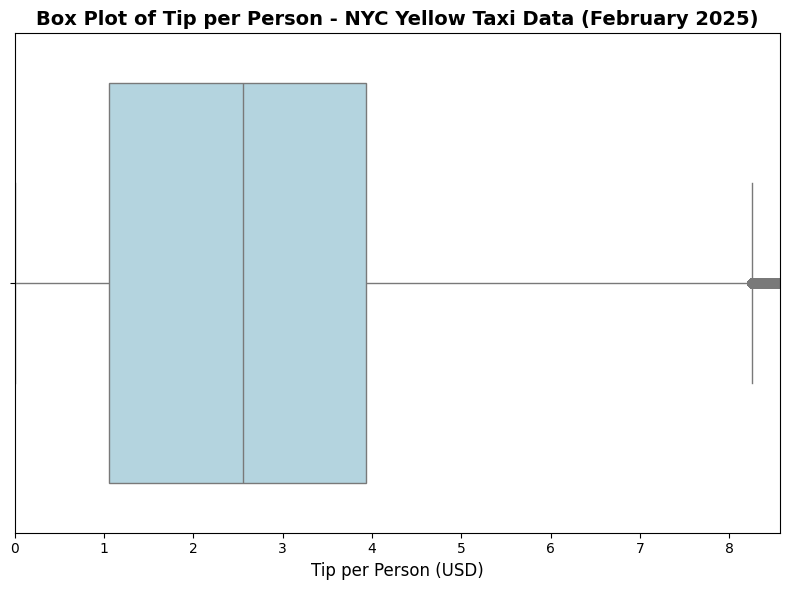

In [24]:
# reporting based on df_clean
print("\n--- Reporting on cleaned dataset (df_clean) ---")
# Tip per Person
df_clean['tip_per_person'] = np.where(
    (df_clean['passenger_count'] > 0),
    df_clean['tip_amount'] / df_clean['passenger_count'],
    np.nan
)   
enhancement_flag.append('tip_per_person')
# print tip_per_person in USD number formatting
print("\nTip per person statistics:")
if df_clean['tip_per_person'].notna().sum() > 0 :
    print(f"  Mean tip per person: ${df_clean['tip_per_person'].mean():.2f}")
    print(f"  Median tip per person: ${df_clean['tip_per_person'].median():.2f}")
    print(f"  Max tip per person: ${df_clean['tip_per_person'].max():.2f}")
    print(f"  Min tip per person: ${df_clean['tip_per_person'].min():.2f}")

# box plot of tip_per_person
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_clean['tip_per_person'], color='lightblue')
plt.title('Box Plot of Tip per Person - NYC Yellow Taxi Data (February 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Tip per Person (USD)', fontsize=12)
plt.xlim(0, df_clean['tip_per_person'].quantile(0.95)*1.1)  # Limit x-axis to 95th percentile for better visualization
plt.tight_layout()
plt.show()


Enrich - Umsatz pro Weglänge (Verhältnis)


Fare amount per mile statistics:
  Mean fare per mile: $7.97
  Median fare per mile: $7.45
  Max fare per mile: $25.00
  Min fare per mile: $2.01


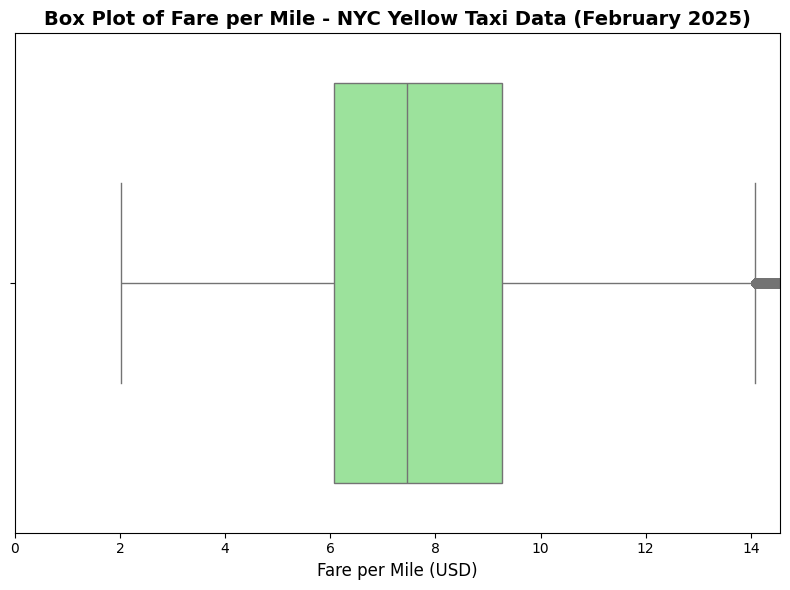

In [25]:
# Umsatz pro Weglänge (Verhältnis) 
print("\nFare amount per mile statistics:")
if df_clean['fare_per_mile'].notna().sum() > 0 :
    print(f"  Mean fare per mile: ${df_clean['fare_per_mile'].mean():.2f}")
    print(f"  Median fare per mile: ${df_clean['fare_per_mile'].median():.2f}")
    print(f"  Max fare per mile: ${df_clean['fare_per_mile'].max():.2f}")
    print(f"  Min fare per mile: ${df_clean['fare_per_mile'].min():.2f}")

# box plot of fare_per_mile
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_clean['fare_per_mile'], color='lightgreen')
plt.title('Box Plot of Fare per Mile - NYC Yellow Taxi Data (February 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Fare per Mile (USD)', fontsize=12)
plt.xlim(0, df_clean['fare_per_mile'].quantile(0.95)*1.1)  # Limit x-axis to 95th percentile for better visualization
plt.tight_layout()
plt.show()


Enrich - Gesamtumsatz pro Taximeter (vendor_id) (with log) ORIGINAL DF
without data cleansing (negative values, wrong calculations, etc. included)


Total amount by VendorID (Original Data without cleaning):
  VendorID 2 (Curb Mobility, LLC): $70,005,899.27
  VendorID 1 (Creative Mobile Technologies, LLC): $19,430,707.47
  VendorID 7 (Helix): $101,656.46
  VendorID 6 (Myle Technologies Inc): $9,605.94

Total revenue (all vendors): $89,547,869.14


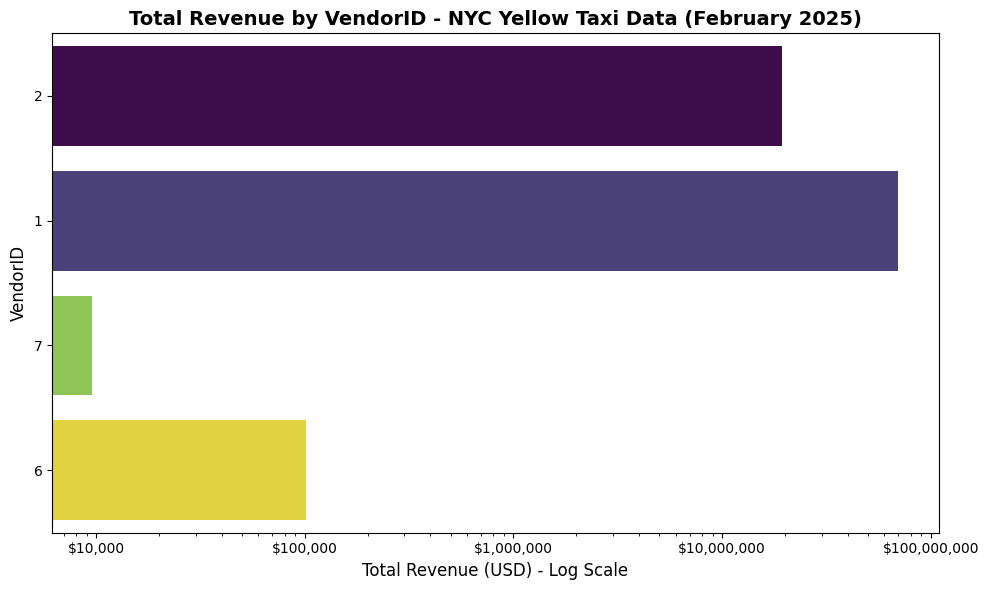

In [26]:
# total sum of total_amount per VendorID grouped with VendorNames and USD formatting
print("\nTotal amount by VendorID (Original Data without cleaning):")
vendor_totals = df.groupby('VendorID')['total_amount'].sum().reset_index()
vendor_totals['VendorName'] = vendor_totals['VendorID'].map(VENDOR_ID_NAMES)
vendor_totals = vendor_totals.sort_values(by='total_amount', ascending=False)
for index, row in vendor_totals.iterrows():
    print(f"  VendorID {int(row['VendorID'])} ({row['VendorName']}): ${row['total_amount']:,.2f}")

# print total revenue
total_revenue = df['total_amount'].sum()
print(f"\nTotal revenue (all vendors): ${total_revenue:,.2f}")

# horizontal bar plot of total revenue by VendorID with log scale
plt.figure(figsize=(10, 6))
sns.barplot(y='VendorID', x='total_amount', data=vendor_totals, hue='VendorID', palette='viridis', orient='h', legend=False)
plt.title('Total Revenue by VendorID - NYC Yellow Taxi Data (February 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (USD) - Log Scale', fontsize=12)
plt.ylabel('VendorID', fontsize=12)
plt.yticks(ticks=range(len(vendor_totals)), labels=[f"{int(vid)}" for vid in vendor_totals['VendorID']])
# Apply log scale to x-axis
plt.xscale('log')
# Format x-axis to remove scientific notation
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


Enrich - Gesamtumsatz pro Taximeter (vendor_id)


Total amount by VendorID:
  VendorID 2 (Curb Mobility, LLC): $47,388,680.02
  VendorID 1 (Creative Mobile Technologies, LLC): $13,368,208.73
  VendorID 7 (Helix): $90,472.55

Total revenue (all vendors): $60,847,361.30


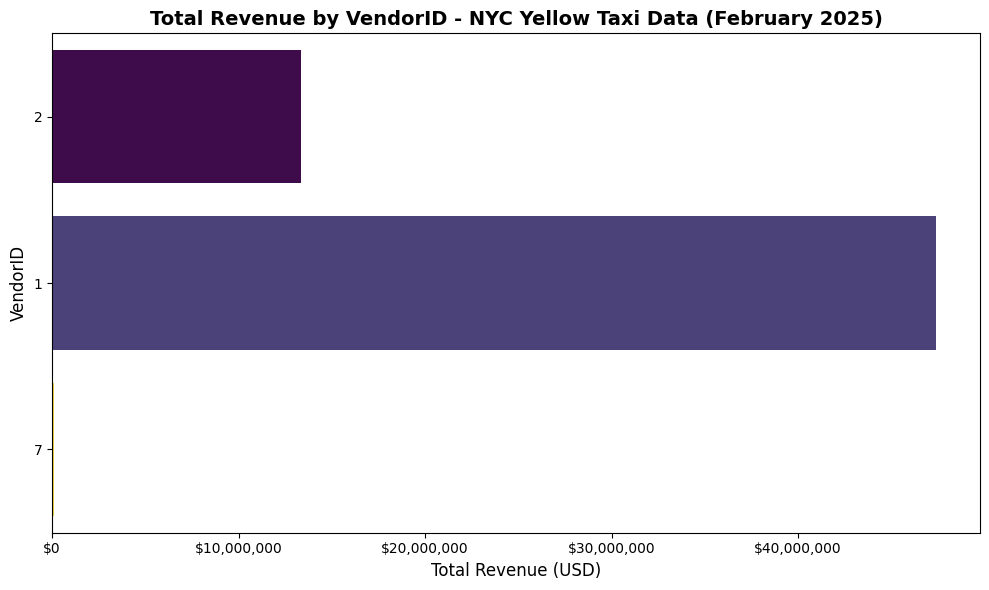

In [27]:
# total sum of total_amount per VendorID grouped with VendorNames and USD formatting
print("\nTotal amount by VendorID:")
vendor_totals = df_clean.groupby('VendorID')['total_amount'].sum().reset_index()
vendor_totals['VendorName'] = vendor_totals['VendorID'].map(VENDOR_ID_NAMES)
vendor_totals = vendor_totals.sort_values(by='total_amount', ascending=False)
for index, row in vendor_totals.iterrows():
    print(f"  VendorID {int(row['VendorID'])} ({row['VendorName']}): ${row['total_amount']:,.2f}")

# print total revenue
total_revenue = df_clean['total_amount'].sum()
print(f"\nTotal revenue (all vendors): ${total_revenue:,.2f}")

# horizontal bar plot of total revenue by VendorID
plt.figure(figsize=(10, 6))
sns.barplot(y='VendorID', x='total_amount', data=vendor_totals, hue='VendorID', palette='viridis', orient='h', legend=False)
plt.title('Total Revenue by VendorID - NYC Yellow Taxi Data (February 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (USD)', fontsize=12)
plt.ylabel('VendorID', fontsize=12)
plt.yticks(ticks=range(len(vendor_totals)), labels=[f"{int(vid)}" for vid in vendor_totals['VendorID']])
# Format x-axis to remove scientific notation
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


Enrich - Gesamtumsatz pro Taximeter (vendor_id) (with log)


Total amount by VendorID:
  VendorID 2 (Curb Mobility, LLC): $47,388,680.02
  VendorID 1 (Creative Mobile Technologies, LLC): $13,368,208.73
  VendorID 7 (Helix): $90,472.55

Total revenue (all vendors): $60,847,361.30


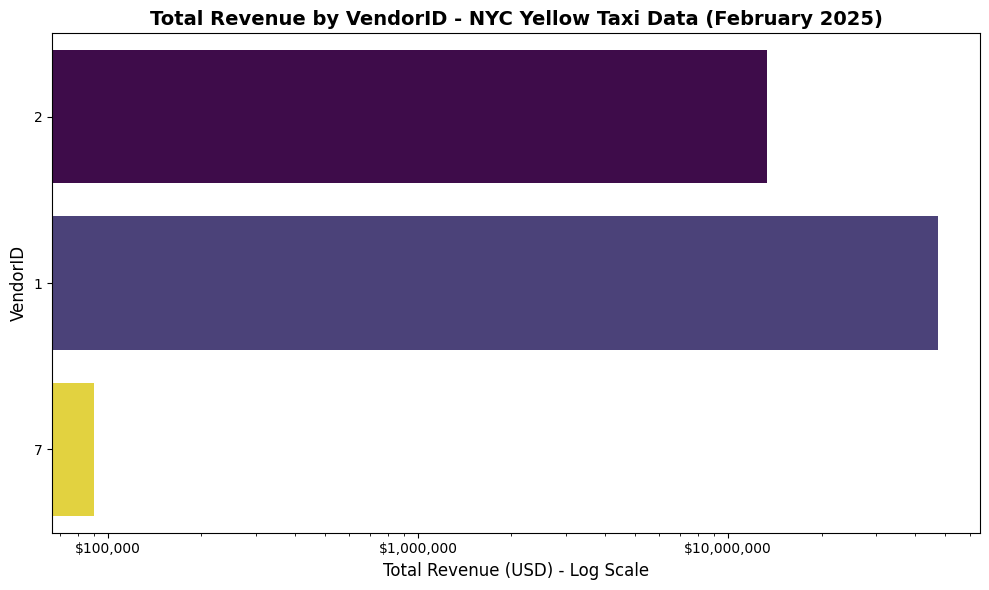

In [28]:
# total sum of total_amount per VendorID grouped with VendorNames and USD formatting
print("\nTotal amount by VendorID:")
vendor_totals = df_clean.groupby('VendorID')['total_amount'].sum().reset_index()
vendor_totals['VendorName'] = vendor_totals['VendorID'].map(VENDOR_ID_NAMES)
vendor_totals = vendor_totals.sort_values(by='total_amount', ascending=False)
for index, row in vendor_totals.iterrows():
    print(f"  VendorID {int(row['VendorID'])} ({row['VendorName']}): ${row['total_amount']:,.2f}")

# print total revenue
total_revenue = df_clean['total_amount'].sum()
print(f"\nTotal revenue (all vendors): ${total_revenue:,.2f}")

# horizontal bar plot of total revenue by VendorID with log scale
plt.figure(figsize=(10, 6))
sns.barplot(y='VendorID', x='total_amount', data=vendor_totals, hue='VendorID', palette='viridis', orient='h', legend=False)
plt.title('Total Revenue by VendorID - NYC Yellow Taxi Data (February 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (USD) - Log Scale', fontsize=12)
plt.ylabel('VendorID', fontsize=12)
plt.yticks(ticks=range(len(vendor_totals)), labels=[f"{int(vid)}" for vid in vendor_totals['VendorID']])
# Apply log scale to x-axis
plt.xscale('log')
# Format x-axis to remove scientific notation
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


Enrich - Median von Weglänge aller Fahrten pro Tag und Stunde



Median trip distance per day and hour:
  Date 2025-01-31, Hour 23: Median Distance = 1.63 miles
  Date 2025-02-01, Hour 0: Median Distance = 1.80 miles
  Date 2025-02-01, Hour 1: Median Distance = 1.77 miles
  Date 2025-02-01, Hour 2: Median Distance = 1.73 miles
  Date 2025-02-01, Hour 3: Median Distance = 1.85 miles
  Date 2025-02-01, Hour 4: Median Distance = 1.90 miles
  Date 2025-02-01, Hour 5: Median Distance = 1.97 miles
  Date 2025-02-01, Hour 6: Median Distance = 1.89 miles
  Date 2025-02-01, Hour 7: Median Distance = 1.69 miles
  Date 2025-02-01, Hour 8: Median Distance = 1.60 miles
  Date 2025-02-01, Hour 9: Median Distance = 1.52 miles
  Date 2025-02-01, Hour 10: Median Distance = 1.50 miles
  Date 2025-02-01, Hour 11: Median Distance = 1.46 miles
  Date 2025-02-01, Hour 12: Median Distance = 1.50 miles
  Date 2025-02-01, Hour 13: Median Distance = 1.50 miles
  Date 2025-02-01, Hour 14: Median Distance = 1.56 miles
  Date 2025-02-01, Hour 15: Median Distance = 1.58 miles
 

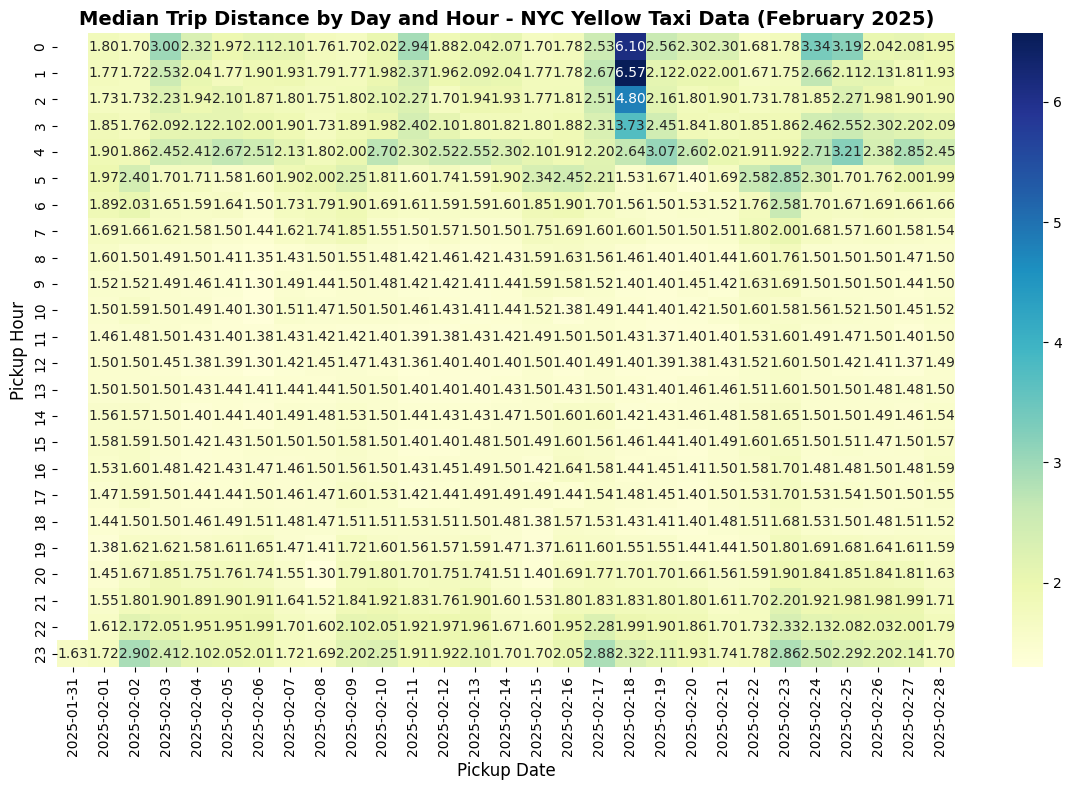

In [29]:
# Median von Weglänge aller Fahrten pro Tag und Stunde 
median_distance_per_day_hour = df_clean.groupby(['pickup_date', 'pickup_hour'])['trip_distance'].median().reset_index()

# Merge median distance back to df_clean as a new column
df_clean = df_clean.merge(median_distance_per_day_hour, on=['pickup_date', 'pickup_hour'], how='left', suffixes=('', '_median'))
df_clean.rename(columns={'trip_distance_median': 'median_trip_distance'}, inplace=True)
enhancement_flag.append('median_trip_distance')

print("\nMedian trip distance per day and hour:")
for index, row in median_distance_per_day_hour.iterrows():
    print(f"  Date {row['pickup_date']}, Hour {int(row['pickup_hour'])}: Median Distance = {row['trip_distance']:.2f} miles")

# plot median trip distance heatmap
pivot_table = median_distance_per_day_hour.pivot(index='pickup_hour', columns='pickup_date', values='trip_distance')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Median Trip Distance by Day and Hour - NYC Yellow Taxi Data (February 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Pickup Date', fontsize=12)  
plt.ylabel('Pickup Hour', fontsize=12)
plt.tight_layout()
plt.show()

Visualize - Summe des zurückgelegten Wegs pro Tag über Monat


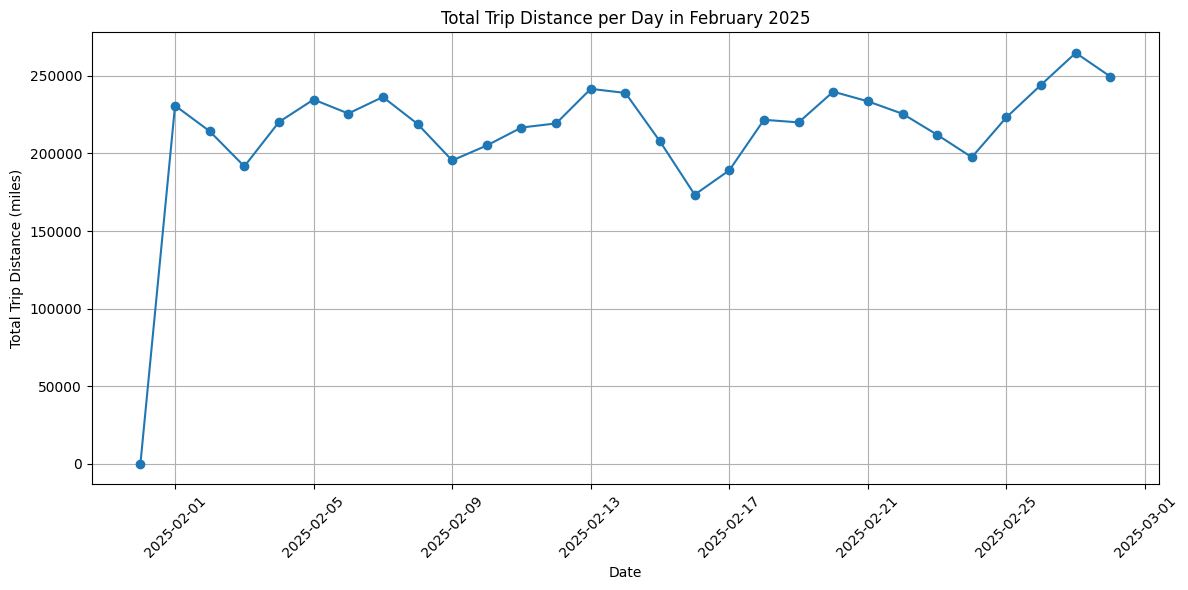

In [30]:
# Visualize - Summe des zurückgelegten Wegs pro Tag über Monat
df_clean['pickup_date'] = pd.to_datetime(df_clean['pickup_date'])
daily_distance = df_clean.groupby('pickup_date')['trip_distance'].sum().reset_index()
plt.figure(figsize=(12,6))
plt.plot(daily_distance['pickup_date'], daily_distance['trip_distance'], marker='o', linestyle='-')
plt.title('Total Trip Distance per Day in February 2025')   
plt.xlabel('Date')
plt.ylabel('Total Trip Distance (miles)')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Visualize - Fahrten pro Tagesstunde (0-23)

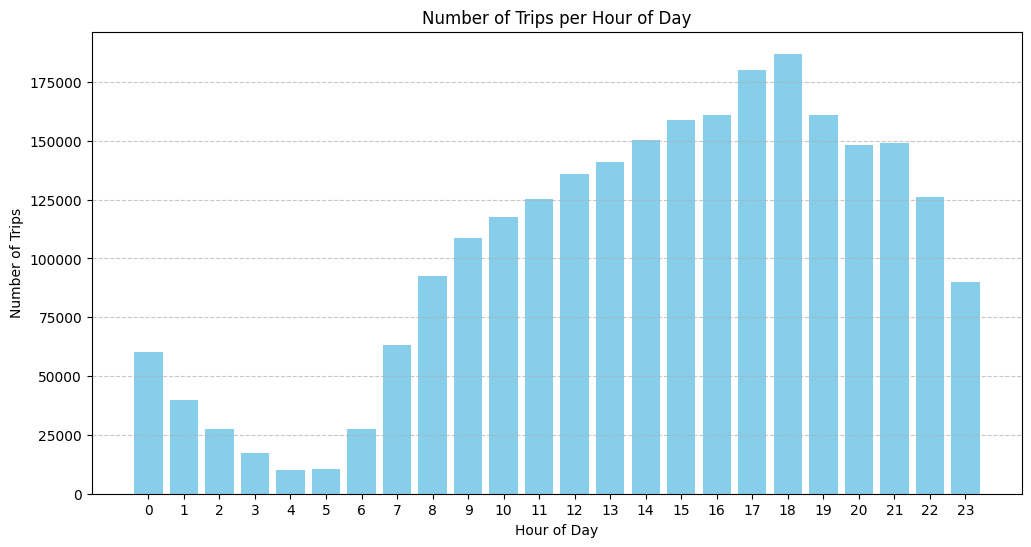

In [31]:
# Visualize - Fahrten pro Tagesstunde (0-23)
hourly_trips = df_clean['pickup_hour'].value_counts().sort_index()
plt.figure(figsize=(12,6))  
plt.bar(hourly_trips.index, hourly_trips.values, color='skyblue')
plt.title('Number of Trips per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(hourly_trips.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Visualize - Gesamtumsatz (fare) pro vendor

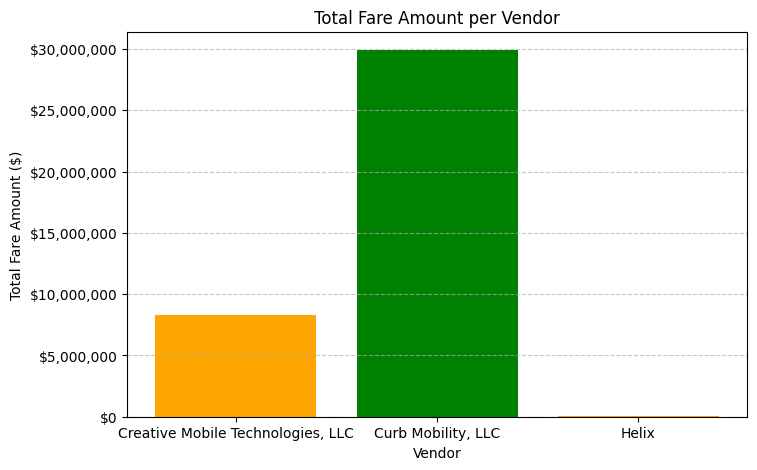


Total fare amount per Vendor:
  Creative Mobile Technologies, LLC: $8,268,361.62
  Curb Mobility, LLC: $29,907,566.99
  Helix: $54,950.70
Total fare amount (cleaned data): $38,230,879.31


In [32]:
# Visualize - Gesamtumsatz (fare) pro vendor with vendor names
vendor_fare = df_clean.groupby('VendorID')['fare_amount'].sum().reset_index()
vendor_fare['VendorName'] = vendor_fare['VendorID'].map(VENDOR_ID_NAMES)
plt.figure(figsize=(8,5))
ax = plt.bar(vendor_fare['VendorName'], vendor_fare['fare_amount'], color=['orange', 'green'])
plt.title('Total Fare Amount per Vendor')
plt.xlabel('Vendor')
plt.ylabel('Total Fare Amount ($)')

# Format y-axis with comma separators for thousands
from matplotlib.ticker import FuncFormatter
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
# print vendor_fare with USD number formatting
print("\nTotal fare amount per Vendor:")
for index, row in vendor_fare.iterrows():
    print(f"  {row['VendorName']}: ${row['fare_amount']:,.2f}") 

# print total of fare_amount in df_clean with USD number formatting
total_fare_clean = df_clean['fare_amount'].sum()
print(f"Total fare amount (cleaned data): ${total_fare_clean:,.2f}")
    

Visualize - Gesamtumsatz (fare) pro vendor (with log)

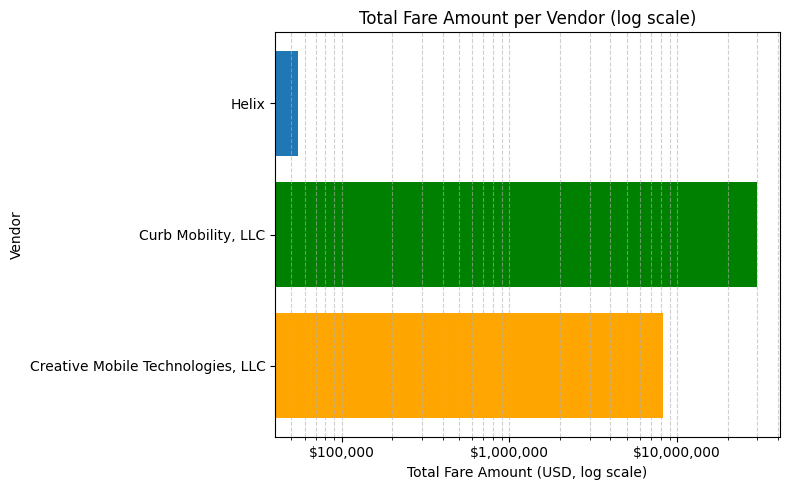


Total fare amount per Vendor:
  Creative Mobile Technologies, LLC: $8,268,361.62
  Curb Mobility, LLC: $29,907,566.99
  Helix: $54,950.70

Total fare amount (cleaned data): $38,230,879.31


In [33]:
# Log-scaled horizontal bar plot for total fare per vendor (reuses existing `vendor_fare` if present)
try:
    vf = vendor_fare
except NameError:
    vf = df_clean.groupby('VendorID')['fare_amount'].sum().reset_index()
    vf['VendorName'] = vf['VendorID'].map(VENDOR_ID_NAMES)

plt.figure(figsize=(8,5))
plt.barh(vf['VendorName'], vf['fare_amount'], color=['orange','green','tab:blue'][:len(vf)])
plt.xscale('log')
plt.title('Total Fare Amount per Vendor (log scale)')
plt.xlabel('Total Fare Amount (USD, log scale)')
plt.ylabel('Vendor')

# Format x-axis ticks as USD (works with log scale)
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.grid(axis='x', which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Print numeric summary
print("\nTotal fare amount per Vendor:")
for _, row in vf.iterrows():
    print(f"  {row['VendorName']}: ${row['fare_amount']:,.2f}")

print(f"\nTotal fare amount (cleaned data): ${df_clean['fare_amount'].sum():,.2f}")

Visualize - Box Plot von trip_distance pro Tag


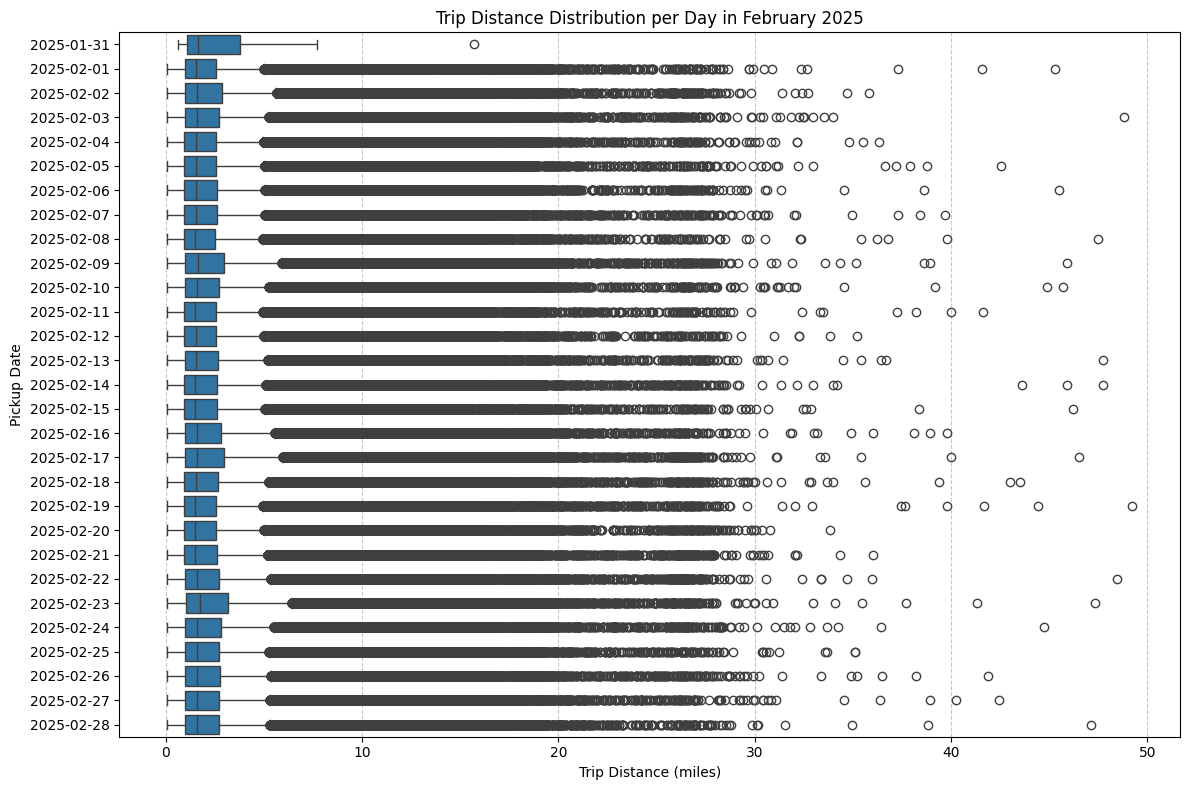


Outlier trip distances per day (above upper IQR threshold):
  Date 2025-01-31: 1 outlier trips
  Date 2025-02-01: 8381 outlier trips
  Date 2025-02-02: 8584 outlier trips
  Date 2025-02-03: 8255 outlier trips
  Date 2025-02-04: 9227 outlier trips
  Date 2025-02-05: 9904 outlier trips
  Date 2025-02-06: 9368 outlier trips
  Date 2025-02-07: 9711 outlier trips
  Date 2025-02-08: 8104 outlier trips
  Date 2025-02-09: 7933 outlier trips
  Date 2025-02-10: 8940 outlier trips
  Date 2025-02-11: 9052 outlier trips
  Date 2025-02-12: 9031 outlier trips
  Date 2025-02-13: 9939 outlier trips
  Date 2025-02-14: 10045 outlier trips
  Date 2025-02-15: 7988 outlier trips
  Date 2025-02-16: 6657 outlier trips
  Date 2025-02-17: 8235 outlier trips
  Date 2025-02-18: 9818 outlier trips
  Date 2025-02-19: 9385 outlier trips
  Date 2025-02-20: 9913 outlier trips
  Date 2025-02-21: 9831 outlier trips
  Date 2025-02-22: 8161 outlier trips
  Date 2025-02-23: 8358 outlier trips
  Date 2025-02-24: 8809 outli

In [34]:
# Visualize - Box Plot von trip_distance pro Tag (horizontal)
# Convert pickup_date to datetime for proper chronological sorting
df_clean['pickup_date_dt'] = pd.to_datetime(df_clean['pickup_date'])

# Sort dataframe by date and get unique dates in chronological order
df_plot = df_clean.sort_values('pickup_date_dt')
date_order = sorted(df_plot['pickup_date_dt'].unique())

plt.figure(figsize=(12,8))
sns.boxplot(x='trip_distance', y='pickup_date_dt', data=df_plot, orient='h', order=date_order)
plt.title('Trip Distance Distribution per Day in February 2025')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Pickup Date')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# print count of trip_distance per day > upper iqr outlier threshold
print("\nOutlier trip distances per day (above upper IQR threshold):")
for date, group in df_clean.groupby('pickup_date'):
    q1 = group['trip_distance'].quantile(0.25)
    q3 = group['trip_distance'].quantile(0.75)
    iqr = q3 - q1
    upper_threshold = q3 + 1.5 * iqr
    outlier_count = (group['trip_distance'] > upper_threshold).sum()
    print(f"  Date {date.date()}: {outlier_count} outlier trips")

Enhancing Weather Data

In [35]:
# ============================================================================
# 1. FETCH WEATHER DATA FROM OPENWEATHERMAP (WITH CACHING)
# ============================================================================

print("\n--- Step 1: Fetching Weather Data from OpenWeatherMap ---")

# Define cache file path based on reporting year and month
weather_cache_file = os.path.join(r"C:\Users\Stefan\Documents\work\Studium\GitHub\Gansch83\Projektarbeit-NYC-yc-taxi\WeatherData", 
    f"weather_data_{REPORTING_YEAR}_{REPORTING_MONTH:02d}.parquet"
)

# Check if cache file exists
if os.path.exists(weather_cache_file):
    print(f"✓ Cache file found: {weather_cache_file}")
    print(f"  Loading cached weather data...")
    
    try:
        weather_df = pd.read_parquet(weather_cache_file)
        file_size_kb = os.path.getsize(weather_cache_file) / 1024
        
        print(f"\n✓ Successfully loaded cached weather data")
        print(f"  File size: {file_size_kb:.1f} KB")
        print(f"  Records: {len(weather_df):,}")
        print(f"  Columns: {list(weather_df.columns)}")
        
        if len(weather_df) > 0:
            print(f"  Date range: {weather_df['date'].min()} to {weather_df['date'].max()}")
            
            if 'hour' in weather_df.columns:
                print(f"  Data type: HOURLY ✓")
                hours_per_day = weather_df.groupby('date').size()
                print(f"  Hours per day - Min: {hours_per_day.min()}, Max: {hours_per_day.max()}, Mean: {hours_per_day.mean():.1f}")
        
        print(f"\n💡 Using cached data. To refresh, delete the cache file and re-run this cell.")
        
    except Exception as e:
        print(f"\n⚠️  Error loading cache file: {str(e)}")
        print(f"  Cache file may be corrupted. Deleting and fetching fresh data...")
        os.remove(weather_cache_file)
        weather_df = None  # Trigger fresh fetch
    
else:
    print(f"❌ Cache file not found: {weather_cache_file}")
    print(f"  Fetching fresh weather data from API...")
    weather_df = None  # Trigger fresh fetch

# ============================================================================
# FETCH FRESH DATA (only if cache not available or corrupted)
# ============================================================================

if weather_df is None or len(weather_df) == 0:
    
    # Check if API key is set
    if OPENWEATHER_API_KEY == "YOUR_API_KEY_HERE" or OPENWEATHER_API_KEY == "":
        print("\n⚠️  WARNING: OpenWeatherMap API key not configured!")
        print("   Please set OPENWEATHER_API_KEY to fetch weather data.")
        print("   Using empty weather dataframe - analysis will be limited.")
        weather_df = pd.DataFrame()  # Empty dataframe
        
    else:
        print(f"\n✓ API key detected: {OPENWEATHER_API_KEY[:10]}...")
        
        # Get unique dates from dataset
        unique_dates = sorted(df_clean['tpep_pickup_datetime'].dt.date.unique())
        print(f"\n📅 Date range: {unique_dates[0]} to {unique_dates[-1]}")
        print(f"📊 Total days to fetch: {len(unique_dates)}")
        print(f"📋 First 5 dates: {unique_dates[:5]}")
        print(f"📋 Last 5 dates: {unique_dates[-5:]}")
        
        # Estimate time and cost
        total_api_calls = len(unique_dates) * 24  # 24 hours per day
        estimated_time_min = (total_api_calls * 1.1) / 60  # 1.1 seconds per call
        print(f"\n⏱️  Estimated time: {estimated_time_min:.1f} minutes")
        print(f"📞 Total API calls: {total_api_calls:,} (24 per day)")
        print(f"💰 Cost: Free tier allows 1,000 calls/day")
        
        # Fetch hourly data
        weather_data_list = []
        
        print("\n🌐 Fetching HOURLY weather data from OpenWeatherMap API...")
        print(f"   This will take approximately {estimated_time_min:.0f} minutes...")
        print(f"   Progress:")
        
        for i, date in enumerate(unique_dates, 1):
            print(f"   [{i:2d}/{len(unique_dates):2d}] {date}...", end=' ', flush=True)
            
            # Get hourly records (24 per day)
            hourly_records = fetch_weather_data_openweather_hourly(date, OPENWEATHER_API_KEY)
            
            if hourly_records:
                weather_data_list.extend(hourly_records)  # ✅ Add all 24 hours
                print(f"✓ ({len(hourly_records)} hours)")
            else:
                print("✗ Failed")
            
            # Rate limiting: 1.1 seconds between calls (safe for 60 calls/min limit)
            if i < len(unique_dates):
                import time
                time.sleep(1.1)
        
        # DIAGNOSTIC: Check data before DataFrame creation
        print(f"\n📊 Data collection summary:")
        print(f"  Total records fetched: {len(weather_data_list)}")
        print(f"  Expected records: {len(unique_dates) * 24}")
        
        if len(weather_data_list) == 0:
            print("\n⚠️  ERROR: No weather data was fetched!")
            print("  Possible reasons:")
            print("    - Invalid API key")
            print("    - API rate limit exceeded")
            print("    - Network connectivity issues")
            print("    - Date range not available in API")
            weather_df = pd.DataFrame()  # Empty dataframe
            
        else:
            print(f"  First record keys: {list(weather_data_list[0].keys())}")
            print(f"  First record: {weather_data_list[0]['date']} {weather_data_list[0]['hour']:02d}:00")
            print(f"  Last record: {weather_data_list[-1]['date']} {weather_data_list[-1]['hour']:02d}:00")
            
            # Create DataFrame from hourly data
            weather_df = pd.DataFrame(weather_data_list)
            
            print(f"\n✓ DataFrame created: {len(weather_df):,} rows")
            print(f"  Columns: {list(weather_df.columns)}")
            
            # Verify data structure
            if 'hour' in weather_df.columns:
                print(f"  Data type: HOURLY ✓")
                hours_per_day = weather_df.groupby('date').size()
                print(f"  Hours per day - Min: {hours_per_day.min()}, Max: {hours_per_day.max()}, Mean: {hours_per_day.mean():.1f}")
                
                # Show days with incomplete data
                incomplete_days = hours_per_day[hours_per_day < 24]
                if len(incomplete_days) > 0:
                    print(f"\n  ⚠️  {len(incomplete_days)} days with incomplete data:")
                    for date, count in incomplete_days.items():
                        print(f"    {date}: {count} hours")
            
            # Save to cache file
            try:
                weather_df.to_parquet(weather_cache_file, index=False, compression='snappy')
                file_size_kb = os.path.getsize(weather_cache_file) / 1024
                print(f"\n💾 Weather data saved to cache: {weather_cache_file}")
                print(f"  File size: {file_size_kb:.1f} KB")
                print(f"  Records: {len(weather_df):,} hourly records")
                print(f"  ✓ Next run will use cached data (faster!)")
            except Exception as e:
                print(f"\n⚠️  Warning: Could not save cache file: {str(e)}")

# Final summary
print(f"\n" + "="*70)
if len(weather_df) > 0:
    print(f"✅ Weather data ready: {len(weather_df):,} records")
    print(f"  Source: {'Cached file' if os.path.exists(weather_cache_file) and weather_df is not None else 'Fresh API fetch'}")
else:
    print(f"⚠️  No weather data available")
    print(f"  Analysis will continue without weather information")
print("="*70)


--- Step 1: Fetching Weather Data from OpenWeatherMap ---
✓ Cache file found: C:\Users\Stefan\Documents\work\Studium\GitHub\Gansch83\Projektarbeit-NYC-yc-taxi\WeatherData\weather_data_2025_02.parquet
  Loading cached weather data...

✓ Successfully loaded cached weather data
  File size: 28.7 KB
  Records: 696
  Columns: ['date', 'datetime', 'hour', 'temp', 'feels_like', 'pressure', 'humidity', 'wind_speed', 'clouds', 'visibility', 'weather_main', 'weather_description', 'dt', 'sunrise', 'sunset', 'dew_point', 'wind_deg', 'wind_gust', 'weather_id', 'weather_icon']
  Date range: 2025-01-31 to 2025-02-28
  Data type: HOURLY ✓
  Hours per day - Min: 24, Max: 24, Mean: 24.0

💡 Using cached data. To refresh, delete the cache file and re-run this cell.

✅ Weather data ready: 696 records
  Source: Cached file


WEATHER DATA CATEGORIZATION (METRIC UNITS)

In [36]:
# ============================================================================
# 2. WEATHER DATA CATEGORIZATION (METRIC UNITS) - HOURLY VERSION
# ============================================================================

print("\n--- Step 2: Categorizing Weather Data ---")

# Categorize weather conditions using metric thresholds
# Temperature: Celsius, Wind: km/h, Visibility: km

# ✅ Check if we have hourly or daily data
if 'temp' in weather_df.columns:
    # Hourly data structure
    temp_col = 'temp'
    feels_like_col = 'feels_like'
    wind_col = 'wind_speed'  # Already in km/h from fetch function
    print(f"✓ Detected HOURLY weather data structure")
elif 'temp_avg' in weather_df.columns:
    # Daily aggregate structure
    temp_col = 'temp_avg'
    feels_like_col = 'feels_like_avg'
    wind_col = 'wind_speed_kmh'
    print(f"✓ Detected DAILY aggregate weather data structure")
else:
    raise ValueError("⚠️ Unknown weather data structure - no temperature column found!")

# Basic weather conditions
weather_df['is_rainy_snowy'] = weather_df['weather_main'].isin(['Rain', 'Snow', 'Drizzle', 'Thunderstorm']).astype(int)

# Temperature categories (Celsius)
weather_df['is_freezing'] = (weather_df[temp_col] < 0).astype(int)  # Below 0°C
weather_df['is_cold'] = (weather_df[temp_col] < 10).astype(int)  # Below 10°C (50°F)
weather_df['is_very_cold'] = (weather_df[temp_col] < -5).astype(int)  # Below -5°C (23°F)
weather_df['is_hot'] = (weather_df[temp_col] > 30).astype(int)  # Above 30°C (86°F)
weather_df['is_comfortable'] = (
    (weather_df[temp_col] >= 15) & 
    (weather_df[temp_col] <= 25) & 
    (weather_df['is_rainy_snowy'] == 0)
).astype(int)  # 15-25°C (59-77°F), no rain/snow

# Wind conditions (km/h)
if wind_col == 'wind_speed':
    # Already in km/h from fetch function (converted m/s * 3.6)
    weather_df['wind_speed_kmh'] = weather_df['wind_speed']
    weather_df['is_windy'] = (weather_df['wind_speed'] > 40).astype(int)  # > 40 km/h
    weather_df['is_very_windy'] = (weather_df['wind_speed'] > 60).astype(int)  # > 60 km/h
else:
    # Daily data with separate wind columns
    weather_df['is_windy'] = (weather_df[wind_col] > 40).astype(int)
    weather_df['is_very_windy'] = (weather_df[wind_col] > 60).astype(int)

# Visibility (km) - already converted in fetch function
weather_df['is_poor_visibility'] = (weather_df['visibility'] <= 8).astype(int)  # ≤ 8 km (5 miles)
weather_df['is_very_poor_visibility'] = (weather_df['visibility'] <= 4).astype(int)  # ≤ 4 km (2.5 miles)

# Cloud cover (percentage 0-100)
weather_df['is_cloudy'] = (weather_df['clouds'] > 60).astype(int)  # > 60%
weather_df['is_overcast'] = (weather_df['clouds'] > 85).astype(int)  # > 85%

# Humidity (percentage 0-100)
weather_df['is_high_humidity'] = (weather_df['humidity'] > 75).astype(int)  # > 75%
weather_df['is_very_high_humidity'] = (weather_df['humidity'] > 90).astype(int)  # > 90%

# Extreme weather conditions
weather_df['is_extreme_weather'] = (
    weather_df['is_very_cold'] | 
    weather_df['is_hot'] | 
    weather_df['is_very_windy'] | 
    weather_df['is_very_poor_visibility']
).astype(int)

# Ideal taxi weather (people prefer taxis over walking)
weather_df['is_taxi_favorable'] = (
    weather_df['is_rainy_snowy'] | 
    weather_df['is_cold'] | 
    weather_df['is_hot'] |
    (weather_df['wind_speed_kmh'] > 30)
).astype(int)

print(f"\n✓ Weather data categorized with metric thresholds")
print(f"\nWeather Summary (Metric Units) - {'HOURLY' if 'temp' in weather_df.columns else 'DAILY'} Data:")
print(f"  Total records: {len(weather_df)}")
print(f"  Date range: {weather_df['date'].min()} to {weather_df['date'].max()}")

# Summary statistics
print(f"\nWeather Condition Frequencies:")
print(f"  Rainy/Snowy: {weather_df['is_rainy_snowy'].sum():,} ({weather_df['is_rainy_snowy'].mean()*100:.1f}%)")
print(f"  Freezing (<0°C): {weather_df['is_freezing'].sum():,} ({weather_df['is_freezing'].mean()*100:.1f}%)")
print(f"  Cold (<10°C): {weather_df['is_cold'].sum():,} ({weather_df['is_cold'].mean()*100:.1f}%)")
print(f"  Very cold (<-5°C): {weather_df['is_very_cold'].sum():,} ({weather_df['is_very_cold'].mean()*100:.1f}%)")
print(f"  Extreme weather: {weather_df['is_extreme_weather'].sum():,} ({weather_df['is_extreme_weather'].mean()*100:.1f}%)")
print(f"  Poor visibility (≤8km): {weather_df['is_poor_visibility'].sum():,} ({weather_df['is_poor_visibility'].mean()*100:.1f}%)")
print(f"  Windy (>40km/h): {weather_df['is_windy'].sum():,} ({weather_df['is_windy'].mean()*100:.1f}%)")
print(f"  Taxi-favorable weather: {weather_df['is_taxi_favorable'].sum():,} ({weather_df['is_taxi_favorable'].mean()*100:.1f}%)")

print(f"\n📊 Temperature Statistics:")
print(f"  Min: {weather_df[temp_col].min():.1f}°C")
print(f"  Mean: {weather_df[temp_col].mean():.1f}°C")
print(f"  Max: {weather_df[temp_col].max():.1f}°C")
print(f"  Std Dev: {weather_df[temp_col].std():.1f}°C")
print(f"  Average feels like: {weather_df[feels_like_col].mean():.1f}°C")

print(f"\n💨 Wind Statistics:")
print(f"  Average wind speed: {weather_df['wind_speed_kmh'].mean():.1f} km/h")
print(f"  Max wind speed: {weather_df['wind_speed_kmh'].max():.1f} km/h")
print(f"  Min wind speed: {weather_df['wind_speed_kmh'].min():.1f} km/h")

print(f"\n☁️ Other Conditions:")
print(f"  Average humidity: {weather_df['humidity'].mean():.0f}%")
print(f"  Average cloud cover: {weather_df['clouds'].mean():.0f}%")
print(f"  Average visibility: {weather_df['visibility'].mean():.1f} km")
print(f"  Average pressure: {weather_df['pressure'].mean():.0f} hPa")

# Display sample records
print(f"\n📋 Sample Weather Records:")
print(weather_df[['date', 'datetime', 'hour', temp_col, 'weather_main', 'is_taxi_favorable']].head(25).to_string(index=False))

print(f"\n✓ Weather data ready for merging with taxi trip data")

# merge weather data with taxi trip data based on date and hour
print("\n--- Step 3: Merging Weather Data with Taxi Trip Data ---")
if len(weather_df) == 0:
    print("⚠️  No weather data available to merge. Skipping merge step.")
    df_final = df_clean.copy()
else:
    # Prepare weather data for merging
    weather_merge_cols = [
        'date', 'hour', 
        # Continuous weather variables
        temp_col, 'humidity', 'wind_speed_kmh',
        # Categorical weather flags
        'is_rainy_snowy', 'is_freezing', 'is_cold', 'is_very_cold',
        'is_hot', 'is_comfortable', 'is_windy', 'is_very_windy',
        'is_poor_visibility', 'is_very_poor_visibility', 'is_cloudy', 'is_overcast',
        'is_high_humidity', 'is_very_high_humidity', 'is_extreme_weather',
        'is_taxi_favorable'
    ]
    weather_df_merge = weather_df[weather_merge_cols].copy()
    
    # Rename columns for clarity
    weather_df_merge.rename(columns={
        'date': 'pickup_date',
        temp_col: 'temperature'  # Standardize temperature column name
    }, inplace=True)
    
    # convert pickup_date to datetime64[ns] to match df_clean['pickup_date']
    weather_df_merge['pickup_date'] = pd.to_datetime(weather_df_merge['pickup_date'])
    
    # Merge on pickup_date and pickup_hour
    df_final = pd.merge(
        df_clean,
        weather_df_merge,
        left_on=['pickup_date', 'pickup_hour'],
        right_on=['pickup_date', 'hour'],
        how='left'
    )
    
    # Drop redundant hour column after merge
    df_final.drop(columns=['hour'], inplace=True)
    
    print(f"✓ Merged weather data into taxi trip data")
    print(f"  Final dataset records: {len(df_final):,}")
    print(f"  Columns after merge: {list(df_final.columns)}")
    print(f"\n✓ Weather variables added: temperature, humidity, wind_speed_kmh")
    print(f"  Sample temperature values: min={df_final['temperature'].min():.1f}°C, "
          f"max={df_final['temperature'].max():.1f}°C, mean={df_final['temperature'].mean():.1f}°C")
    print(f"  Sample humidity values: min={df_final['humidity'].min():.0f}%, "
          f"max={df_final['humidity'].max():.0f}%, mean={df_final['humidity'].mean():.0f}%")
    print(f"  Sample wind speed values: min={df_final['wind_speed_kmh'].min():.1f} km/h, "
          f"max={df_final['wind_speed_kmh'].max():.1f} km/h, mean={df_final['wind_speed_kmh'].mean():.1f} km/h")



--- Step 2: Categorizing Weather Data ---
✓ Detected HOURLY weather data structure

✓ Weather data categorized with metric thresholds

Weather Summary (Metric Units) - HOURLY Data:
  Total records: 696
  Date range: 2025-01-31 to 2025-02-28

Weather Condition Frequencies:
  Rainy/Snowy: 132 (19.0%)
  Freezing (<0°C): 229 (32.9%)
  Cold (<10°C): 662 (95.1%)
  Very cold (<-5°C): 53 (7.6%)
  Extreme weather: 91 (13.1%)
  Poor visibility (≤8km): 84 (12.1%)
  Windy (>40km/h): 70 (10.1%)
  Taxi-favorable weather: 671 (96.4%)

📊 Temperature Statistics:
  Min: -7.9°C
  Mean: 1.8°C
  Max: 13.4°C
  Std Dev: 4.6°C
  Average feels like: -2.9°C

💨 Wind Statistics:
  Average wind speed: 23.5 km/h
  Max wind speed: 68.4 km/h
  Min wind speed: 0.0 km/h

☁️ Other Conditions:
  Average humidity: 58%
  Average cloud cover: 41%
  Average visibility: 9.2 km
  Average pressure: 1019 hPa

📋 Sample Weather Records:
      date            datetime  hour  temp weather_main  is_taxi_favorable
2025-01-31 2025-01-

Feature Importance Teil 1. Der statistische Blick: Korrelations-Matrix

Top correlations with fare_amount:
fare_amount          1.000000
trip_distance        0.966388
PU_Queens            0.597945
DO_Brooklyn          0.403379
DO_Queens            0.312100
trip_duration_min    0.287439
DO_Bronx             0.166427
DO_Outside of NYC    0.096615
DO_Staten Island     0.080943
is_overnight         0.030189
DO_EWR               0.028604
PU_Brooklyn          0.027227
temperature          0.019772
pickup_day           0.019391
passenger_count      0.015131
Name: fare_amount, dtype: float64

Bottom correlations with fare_amount:
PU_Unknown            0.004417
wind_speed_kmh        0.003670
is_holiday            0.002917
humidity             -0.000853
DO_Unknown           -0.004329
is_rush_hour         -0.015164
pickup_day_of_week   -0.020260
is_weekend           -0.026730
DO_Manhattan         -0.541035
PU_Manhattan         -0.578912
Name: fare_amount, dtype: float64


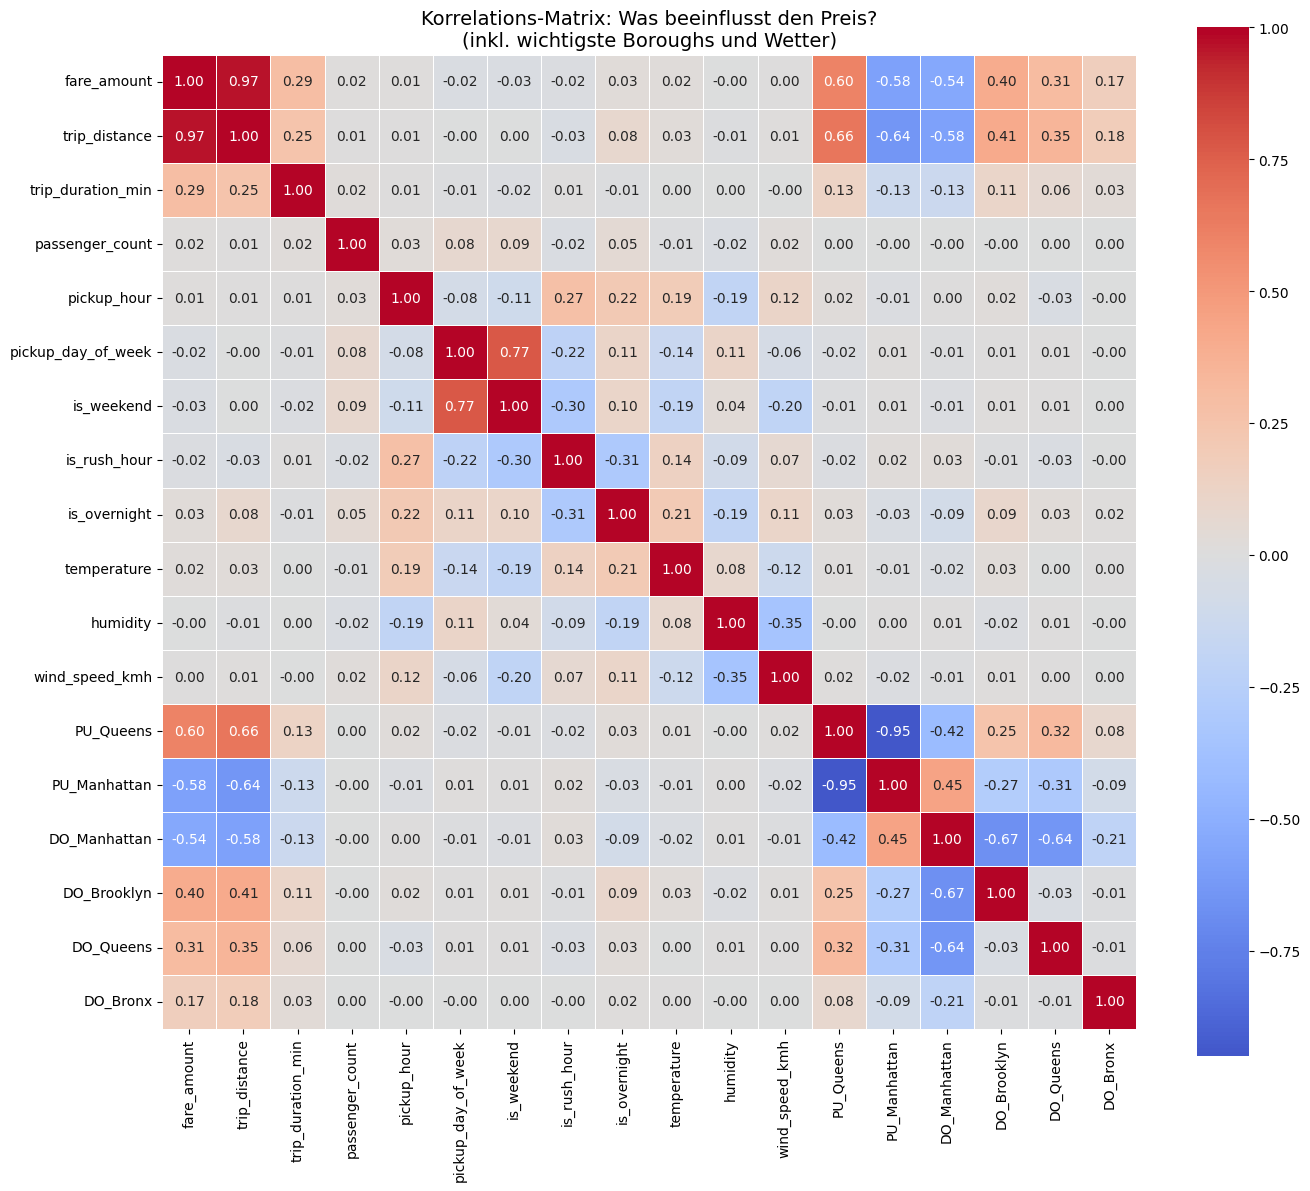


BOROUGH ANALYSIS - Average Fare by Pickup Borough
                Mean Fare  Median Fare  Std Dev  Trip Count
PUBorough                                                  
EWR                 55.73        46.40    47.80           6
Staten Island       47.57        44.65    28.89           6
Queens              43.15        41.50    17.33      135398
Outside of NYC      42.37        35.20    34.94          84
Bronx               23.20        17.70    17.66         586
Brooklyn            21.09        17.00    15.23        6948
Unknown             16.32        12.10    12.13        6440
Manhattan           13.73        11.40     8.13     2340101

BOROUGH ANALYSIS - Average Fare by Dropoff Borough
                Mean Fare  Median Fare  Std Dev  Trip Count
DOBorough                                                  
EWR                 91.21         79.3    34.79          44
Staten Island       85.08         87.7    20.76         417
Outside of NYC      52.93         42.2    30.56        20

In [37]:
# Prepare data for correlation analysis - encode categorical borough columns
# One-hot encode PUBorough and DOBorough for correlation analysis
df_corr = df_final.copy()

# One-hot encode boroughs (creates binary columns for each borough)
pu_borough_encoded = pd.get_dummies(df_corr['PUBorough'], prefix='PU', dtype=int)
do_borough_encoded = pd.get_dummies(df_corr['DOBorough'], prefix='DO', dtype=int)

# Combine with numerical features including weather data
df_corr = pd.concat([
    df_corr[['fare_amount', 'trip_distance', 'passenger_count', 'trip_duration_min', 
             'pickup_hour', 'pickup_day', 'pickup_day_of_week', 'is_weekend', 
             'is_holiday', 'is_rush_hour', 'is_overnight',
             'temperature', 'humidity', 'wind_speed_kmh']],
    pu_borough_encoded,
    do_borough_encoded
], axis=1)

# Calculate correlation matrix
corr_matrix = df_corr.corr()

# Extract correlations with fare_amount and sort by absolute value
fare_correlations = corr_matrix['fare_amount'].sort_values(ascending=False)
print("Top correlations with fare_amount:")
print(fare_correlations.head(15))
print("\nBottom correlations with fare_amount:")
print(fare_correlations.tail(10))

# Visualize correlation matrix for main features
main_features = ['fare_amount', 'trip_distance', 'trip_duration_min', 'passenger_count',
                 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'is_rush_hour', 'is_overnight',
                 'temperature', 'humidity', 'wind_speed_kmh']
# Add top borough correlations
top_borough_features = fare_correlations[fare_correlations.index.str.contains('PU_|DO_')].abs().sort_values(ascending=False).head(6).index.tolist()
features_to_plot = main_features + top_borough_features

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix.loc[features_to_plot, features_to_plot], 
            annot=True, cmap='coolwarm', fmt=".2f", center=0,
            square=True, linewidths=0.5)
plt.title('Korrelations-Matrix: Was beeinflusst den Preis?\n(inkl. wichtigste Boroughs und Wetter)', fontsize=14)
plt.tight_layout()
plt.show()

# Borough-specific analysis: Average fare by borough
print("\n" + "="*60)
print("BOROUGH ANALYSIS - Average Fare by Pickup Borough")
print("="*60)
borough_stats = df_final.groupby('PUBorough').agg({
    'fare_amount': ['mean', 'median', 'std', 'count']
}).round(2)
borough_stats.columns = ['Mean Fare', 'Median Fare', 'Std Dev', 'Trip Count']
borough_stats = borough_stats.sort_values('Mean Fare', ascending=False)
print(borough_stats)

print("\n" + "="*60)
print("BOROUGH ANALYSIS - Average Fare by Dropoff Borough")
print("="*60)
do_borough_stats = df_final.groupby('DOBorough').agg({
    'fare_amount': ['mean', 'median', 'std', 'count']
}).round(2)
do_borough_stats.columns = ['Mean Fare', 'Median Fare', 'Std Dev', 'Trip Count']
do_borough_stats = do_borough_stats.sort_values('Mean Fare', ascending=False)
print(do_borough_stats)


Feature Importance Teil 2. Der ML Blick

## 🤖 Machine Learning Models
### Modellvergleich mit verschiedenen Splitting-Strategien

Wir testen drei verschiedene Modelle:
1. **Linear Regression** - Einfaches lineares Modell
2. **Random Forest** - Ensemble-Methode mit Entscheidungsbäumen
3. **Gradient Boosting** - Sequenzielles Ensemble-Lernen

Jedes Modell wird mit zwei Splitting-Strategien evaluiert:
- **70/30 Split** - Klassische Aufteilung
- **K-Fold Cross-Validation** - 5-fache Kreuzvalidierung für robustere Ergebnisse

In [38]:
# Import required libraries for ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

print("✓ ML Libraries imported successfully")
if 'df_final' in dir():
    print(f"Dataset shape: {df_final.shape}")
    print(f"Available for modeling: {len(df_final):,} trips")
else:
    print("⚠ Note: df_final not found. Please run previous cells first.")

✓ ML Libraries imported successfully
Dataset shape: (2489569, 105)
Available for modeling: 2,489,569 trips


### Feature Engineering für ML
Vorbereitung der Features und Target-Variable

In [39]:
# --- Feature-Definition ---

# Prepare features for modeling
# Definiere die Liste der kontinuierlichen und diskreten numerischen Features, 
# die direkt in das Modell eingehen sollen.
numerical_features = ['trip_distance', 'passenger_count', 'trip_duration_min', 
                     'pickup_hour', 'pickup_day', 'pickup_day_of_week',
                     'temperature', 'humidity', 'wind_speed_kmh']
# Definiere die Liste der binären (0/1) Features. Diese benötigen keine weitere Enkodierung.
binary_features = ['is_weekend', 'is_holiday', 'is_rush_hour', 'is_overnight']

# One-hot encode boroughs
# Wandle das kategoriale Feature 'PUBorough' (Abhol-Bezirk) in numerische Binärspalten um.
# Jede Spalte repräsentiert nun einen Bezirk (z. B. PU_Manhattan, PU_Queens).
# 'prefix' sorgt für eindeutige Spaltennamen, 'dtype=int' speichert die Werte als Integer (0 oder 1).
pu_borough_encoded = pd.get_dummies(df_final['PUBorough'], prefix='PU', dtype=int)
# Dasselbe Verfahren für das kategoriale Feature 'DOBorough' (Ziel-Bezirk).
do_borough_encoded = pd.get_dummies(df_final['DOBorough'], prefix='DO', dtype=int)

# --- Feature-Kombination ---

# Combine all features
# Erstelle die finale Feature-Matrix (X) durch das Zusammenfügen (Konkatenieren) 
# aller vorbereiteten Datensätze entlang der Spalten (axis=1).
X = pd.concat([
    df_final[numerical_features + binary_features],
    pu_borough_encoded,
    do_borough_encoded
], axis=1)

# --- Zielvariable ---

# Target variable
# Definiere die Zielvariable (y), die vorhergesagt werden soll (z. B. der Fahrpreis).
y = df_final['fare_amount']

print("="*60)
print("FEATURE OVERVIEW")
print("="*60)
print(f"Total features: {X.shape[1]}")
print(f"- Numerical features: {len(numerical_features)}")
print(f"- Binary features: {len(binary_features)}")
print(f"- Pickup borough features: {pu_borough_encoded.shape[1]}")
print(f"- Dropoff borough features: {do_borough_encoded.shape[1]}")
print(f"\nTarget variable: fare_amount")
print(f"- Mean: ${y.mean():.2f}")
print(f"- Median: ${y.median():.2f}")
print(f"- Std: ${y.std():.2f}")
print("\nFeature names:")
print(X.columns.tolist())

FEATURE OVERVIEW
Total features: 29
- Numerical features: 9
- Binary features: 4
- Pickup borough features: 8
- Dropoff borough features: 8

Target variable: fare_amount
- Mean: $15.36
- Median: $12.10
- Std: $11.15

Feature names:
['trip_distance', 'passenger_count', 'trip_duration_min', 'pickup_hour', 'pickup_day', 'pickup_day_of_week', 'temperature', 'humidity', 'wind_speed_kmh', 'is_weekend', 'is_holiday', 'is_rush_hour', 'is_overnight', 'PU_Bronx', 'PU_Brooklyn', 'PU_EWR', 'PU_Manhattan', 'PU_Outside of NYC', 'PU_Queens', 'PU_Staten Island', 'PU_Unknown', 'DO_Bronx', 'DO_Brooklyn', 'DO_EWR', 'DO_Manhattan', 'DO_Outside of NYC', 'DO_Queens', 'DO_Staten Island', 'DO_Unknown']


### 70/30 Train-Test Split
Klassische Aufteilung: 70% Training, 30% Testing

In [40]:
# --- Datenaufteilung ---

# Split data into training and testing sets (70/30)
# 'X' ist die Feature-Matrix, 'y' ist die Zielvariable.
# 'test_size=0.3' legt fest, dass 30% der Daten für den Test reserviert werden.
# 'random_state=42' sorgt für eine reproduzierbare Aufteilung, 
# sodass das Training und die Ergebnisse bei jedem Durchlauf gleich sind.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- Feature-Skalierung/Standardisierung ---

# Scale features for better model performance
# Die Skalierung (Standardisierung) ist wichtig, damit Features mit großen Werten 
# (z.B. Einkommen) andere Features mit kleinen Werten (z.B. Alter) nicht dominieren,
# besonders bei Algorithmen, die auf Distanz basieren (z.B. KNN, SVM) oder bei Gradientenverfahren.
scaler = StandardScaler()
# Passe den Skalierer nur an die Trainingsdaten an (fit) und wende ihn dann an (transform).
# Dies verhindert, dass Informationen aus den Testdaten (die 'unbekannt' bleiben sollen) 
# in den Trainingsprozess einfließen ('Data Leakage').
X_train_scaled = scaler.fit_transform(X_train)
# Wende dieselbe Skalierung (die auf X_train gelernt wurde) auf die Testdaten an.
X_test_scaled = scaler.transform(X_test)

print("="*60)
print("DATA SPLITTING - 70/30")
print("="*60)
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Features: {X_train.shape[1]}")
print(f"\nTraining set statistics:")
print(f"- Mean fare: ${y_train.mean():.2f}")
print(f"- Median fare: ${y_train.median():.2f}")
print(f"\nTest set statistics:")
print(f"- Mean fare: ${y_test.mean():.2f}")
print(f"- Median fare: ${y_test.median():.2f}")

DATA SPLITTING - 70/30
Training set: 1,742,698 samples (70.0%)
Test set: 746,871 samples (30.0%)
Features: 29

Training set statistics:
- Mean fare: $15.36
- Median fare: $12.10

Test set statistics:
- Mean fare: $15.35
- Median fare: $12.10


### Model Training & Evaluation - 70/30 Split
Training aller drei Modelle mit der 70/30-Aufteilung

In [41]:
# Dictionary to store models and results
models_70_30 = {
    # 1. Lineares Modell (einfach und schnell)
    'Linear Regression': LinearRegression(),                        
    # 2. Ensemble-Modell (Random Forest)
    # n_estimators=100: Anzahl der Bäume im Wald.
    # random_state=42: Für reproduzierbare Ergebnisse.
    # n_jobs=-1: Nutzt alle verfügbaren Prozessorkerne für schnelleres Training.
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    # 3. Boosting-Modell (Gradient Boosting)
    # Gradient Boosting ist sequenziell und oft sehr leistungsstark, nutzt aber nur einen Kern.
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Dictionary zur Speicherung der Evaluationsergebnisse und der trainierten Modelle.
results_70_30 = {}

# --- Start der Trainingsschleife ---
print("="*80)
print("MODEL TRAINING & EVALUATION - 70/30 SPLIT")
print("="*80)

for model_name, model in models_70_30.items():
    print(f"\n{'='*80}")
    print(f"Training: {model_name}")
    print('='*80)
    
    # Start timing
    start_time = time.time()
    
    # Train model
    # Hier findet das eigentliche Training statt: Das Modell lernt die Muster
    # aus den skalierten Trainings-Features (X_train_scaled) und der Zielvariable (y_train).
    model.fit(X_train_scaled, y_train)
    
   # Make predictions
    # Das trainierte Modell wird verwendet, um Vorhersagen auf den (unabhängigen) Testdaten zu treffen.
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    # Berechnung der Metriken zur Beurteilung der Modellperformance (Regressionsmetriken).
    
    # Mittlerer Absoluter Fehler (MAE): Durchschnittliche absolute Differenz zwischen Vorhersage und tatsächlichem Wert.
    mae = mean_absolute_error(y_test, y_pred)
    
    # Wurzeld des Mittleren Quadratischen Fehlers (RMSE): Ähnlich dem MAE, 
    # gewichtet größere Fehler aber stärker (typisch für Standardabweichung).
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Bestimmtheitsmaß (R²): Beschreibt, welcher Anteil der Varianz der Zielvariablen 
    # durch das Modell erklärt wird (0 bis 1, wobei 1 perfekt ist).
    r2 = r2_score(y_test, y_pred)
    
    # Training time
    training_time = time.time() - start_time
    
    # Store results
    results_70_30[model_name] = {
        'model': model,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'training_time': training_time,
        'predictions': y_pred
    }
    
    # Print results
    print(f"✓ Training completed in {training_time:.2f} seconds")
    print(f"\nEvaluation Metrics:")
    print(f"  MAE (Mean Absolute Error):     ${mae:.2f}")
    print(f"  RMSE (Root Mean Squared Error): ${rmse:.2f}")
    print(f"  R² Score:                       {r2:.4f} ({r2*100:.2f}% variance explained)")
    
    # Additional statistics
    errors = y_test - y_pred
    print(f"\nError Analysis:")
    print(f"  Mean Error:                     ${errors.mean():.2f}")
    print(f"  Std of Errors:                  ${errors.std():.2f}")
    print(f"  Max Overestimation:             ${errors.min():.2f}")
    print(f"  Max Underestimation:            ${errors.max():.2f}")

print(f"\n{'='*80}")
print("70/30 SPLIT - SUMMARY")
print('='*80)

MODEL TRAINING & EVALUATION - 70/30 SPLIT

Training: Linear Regression
✓ Training completed in 1.42 seconds

Evaluation Metrics:
  MAE (Mean Absolute Error):     $1.86
  RMSE (Root Mean Squared Error): $2.63
  R² Score:                       0.9443 (94.43% variance explained)

Error Analysis:
  Mean Error:                     $0.00
  Std of Errors:                  $2.63
  Max Overestimation:             $-59.68
  Max Underestimation:            $152.00

Training: Random Forest
✓ Training completed in 301.94 seconds

Evaluation Metrics:
  MAE (Mean Absolute Error):     $0.48
  RMSE (Root Mean Squared Error): $0.89
  R² Score:                       0.9936 (99.36% variance explained)

Error Analysis:
  Mean Error:                     $0.01
  Std of Errors:                  $0.89
  Max Overestimation:             $-103.92
  Max Underestimation:            $137.88

Training: Gradient Boosting
✓ Training completed in 671.02 seconds

Evaluation Metrics:
  MAE (Mean Absolute Error):     $0.54

### K-Fold Cross-Validation (k=5)
Robustere Evaluation durch 5-fache Kreuzvalidierung

In [ ]:
# Prepare K-Fold Cross-Validation
from sklearn.model_selection import cross_validate

# Scale all data for K-Fold
# Da K-Fold die Daten in N unabhängige Folds unterteilt, die jeweils einmal als Testset dienen,
# muss die Skalierung (Standardisierung) des gesamten Feature-Sets (X) einmalig erfolgen.
# Achtung: Streng genommen sollte die Skalierung innerhalb des Cross-Validation-Loops 
# erfolgen (z.B. über eine Pipeline), um das Risiko von Data Leakage minimal zu halten. 
# Hier wird die vereinfachte Methode angewendet.

# X_scaled = scaler.fit_transform(X) -> nicht nötig wegen Pipeline weiter unten

# Define K-Fold
# Initialisiere das KFold-Objekt zur Steuerung der Aufteilung.
# n_splits=5: Definiert, dass die Daten in 5 gleich große Blöcke (Folds) geteilt werden.
# shuffle=True: Mischt die Daten vor der Aufteilung, um sicherzustellen, dass jede Klasse 
#               gleichmäßig in den Folds vertreten ist.
# random_state=42: Stellt die Reproduzierbarkeit der Mischung sicher.
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Models for K-Fold
# Pipelines, die den Scaler enthalten:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models_kfold = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Random Forest': Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('scaler', StandardScaler()), ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))])
}
# models_kfold = {
#     'Linear Regression': LinearRegression(),
#     'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
#     'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
# }

# Dictionary zur Speicherung der Ergebnisse der Cross-Validation (Mittelwerte der Metriken).
results_kfold = {}

print("="*80)
print("MODEL EVALUATION - K-FOLD CROSS-VALIDATION (k=5)")
print("="*80)
print(f"Total samples: {len(X):,}")
print(f"Folds: 5")
print(f"Each fold: ~{len(X)//5:,} samples for testing, ~{len(X)*4//5:,} for training")

for model_name, model in models_kfold.items():
    print(f"\n{'='*80}")
    print(f"Evaluating: {model_name}")
    print('='*80)
    
    # Start timing
    start_time = time.time()
    
    # Bisher: 
    # Perform cross-validation with multiple metrics
    # cv_results = cross_validate(
    #    model, X_scaled, y,
    #    cv=kfold,
    #    scoring={
    #        'neg_mae': 'neg_mean_absolute_error',
    #        'neg_rmse': 'neg_root_mean_squared_error',
    #        'r2': 'r2'
    #    },
    #    return_train_score=True,
    #    n_jobs=-1
    # )
    # cross_validate mit den UNGESCHLÜSSELten Daten verwenden:
    cv_results = cross_validate(
        model, X, y, # <-- X (ungeskaliert), da die Pipeline das Scaling übernimmt
        cv=kfold,
        scoring={
            'neg_mae': 'neg_mean_absolute_error',
            'neg_rmse': 'neg_root_mean_squared_error',
            'r2': 'r2'},
        return_train_score=True,
        n_jobs=-1
    )
     
    training_time = time.time() - start_time
    
    # Calculate mean and std for each metric
    test_mae = -cv_results['test_neg_mae']
    test_rmse = -cv_results['test_neg_rmse']
    test_r2 = cv_results['test_r2']
    
    train_mae = -cv_results['train_neg_mae']
    train_r2 = cv_results['train_r2']
    
    # Store results
    results_kfold[model_name] = {
        'test_mae_mean': test_mae.mean(),
        'test_mae_std': test_mae.std(),
        'test_rmse_mean': test_rmse.mean(),
        'test_rmse_std': test_rmse.std(),
        'test_r2_mean': test_r2.mean(),
        'test_r2_std': test_r2.std(),
        'train_mae_mean': train_mae.mean(),
        'train_r2_mean': train_r2.mean(),
        'training_time': training_time,
        'cv_results': cv_results
    }
    
    # Print results
    print(f"✓ Cross-validation completed in {training_time:.2f} seconds")
    print(f"\nTest Set Performance (5-Fold CV):")
    print(f"  MAE:  ${test_mae.mean():.2f} (± ${test_mae.std():.2f})")
    print(f"  RMSE: ${test_rmse.mean():.2f} (± ${test_rmse.std():.2f})")
    print(f"  R²:   {test_r2.mean():.4f} (± {test_r2.std():.4f})")
    
    print(f"\nTraining Set Performance:")
    print(f"  MAE:  ${train_mae.mean():.2f}")
    print(f"  R²:   {train_r2.mean():.4f}")
    
    print(f"\nOverfitting Analysis:")
    # Berechne die Overfitting-Metrik (R² Gap)
    # Der Overfitting-Wert ist die Differenz zwischen der durchschnittlichen R²-Performance 
    # auf dem Trainingsset und der durchschnittlichen R²-Performance auf dem Testset 
    # über alle K-Folds hinweg.
    # Ein großer positiver Wert deutet darauf hin, dass das Modell auf Trainingsdaten viel besser 
    # abschneidet als auf unbekannten Testdaten, was ein Zeichen für Überanpassung ist.
    overfitting = train_r2.mean() - test_r2.mean()
    print(f"  R² Gap (Train - Test): {overfitting:.4f}")
    if overfitting < 0.05:
        print(f"  Status: ✓ Low overfitting - Good generalization")
    elif overfitting < 0.15:
        print(f"  Status: ⚠ Moderate overfitting")
    else:
        print(f"  Status: ✗ High overfitting - Model may not generalize well")
    
    # Individual fold performance
    print(f"\nPer-Fold R² Scores:")
    for i, r2_score in enumerate(test_r2, 1):
        print(f"  Fold {i}: {r2_score:.4f}")

print(f"\n{'='*80}")
print("K-FOLD CROSS-VALIDATION - SUMMARY")
print('='*80)

MODEL EVALUATION - K-FOLD CROSS-VALIDATION (k=5)
Total samples: 2,489,569
Folds: 5
Each fold: ~497,913 samples for testing, ~1,991,655 for training

Evaluating: Linear Regression
✓ Cross-validation completed in 20.48 seconds

Test Set Performance (5-Fold CV):
  MAE:  $1.86 (± $0.00)
  RMSE: $2.65 (± $0.02)
  R²:   0.9433 (± 0.0007)

Training Set Performance:
  MAE:  $1.86
  R²:   0.9434

Overfitting Analysis:
  R² Gap (Train - Test): 0.0000
  Status: ✓ Low overfitting - Good generalization

Per-Fold R² Scores:
  Fold 1: 0.9442
  Fold 2: 0.9437
  Fold 3: 0.9427
  Fold 4: 0.9424
  Fold 5: 0.9436

Evaluating: Random Forest
✓ Cross-validation completed in 2233.87 seconds

Test Set Performance (5-Fold CV):
  MAE:  $0.48 (± $0.00)
  RMSE: $0.95 (± $0.05)
  R²:   0.9927 (± 0.0007)

Training Set Performance:
  MAE:  $0.18
  R²:   0.9990

Overfitting Analysis:
  R² Gap (Train - Test): 0.0063
  Status: ✓ Low overfitting - Good generalization

Per-Fold R² Scores:
  Fold 1: 0.9938
  Fold 2: 0.9924

### 📊 Vergleich aller Modelle und Splitting-Strategien
Übersicht der Evaluation-Metriken

In [43]:
# Create comprehensive comparison table
comparison_data = []

for model_name in ['Linear Regression', 'Random Forest', 'Gradient Boosting']:
    # 70/30 Split results
    r_70_30 = results_70_30[model_name]
    comparison_data.append({
        'Model': model_name,
        'Split Strategy': '70/30 Split',
        'MAE ($)': f"{r_70_30['mae']:.2f}",
        'RMSE ($)': f"{r_70_30['rmse']:.2f}",
        'R²': f"{r_70_30['r2']:.4f}",
        'CV Score': 'N/A',
        'Training Time (s)': f"{r_70_30['training_time']:.2f}"
    })
    
    # K-Fold results
    r_kfold = results_kfold[model_name]
    comparison_data.append({
        'Model': model_name,
        'Split Strategy': 'K-Fold (k=5)',
        'MAE ($)': f"{r_kfold['test_mae_mean']:.2f} ± {r_kfold['test_mae_std']:.2f}",
        'RMSE ($)': f"{r_kfold['test_rmse_mean']:.2f} ± {r_kfold['test_rmse_std']:.2f}",
        'R²': f"{r_kfold['test_r2_mean']:.4f} ± {r_kfold['test_r2_std']:.4f}",
        'CV Score': f"{r_kfold['test_r2_mean']:.4f}",
        'Training Time (s)': f"{r_kfold['training_time']:.2f}"
    })

comparison_df = pd.DataFrame(comparison_data)

print("="*100)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))

print("\n" + "="*100)
print("EVALUATION METRICS EXPLAINED")
print("="*100)
print("• MAE (Mean Absolute Error): Durchschnittlicher absoluter Fehler in Dollar")
print("  → Je niedriger, desto besser. Zeigt die durchschnittliche Abweichung.")
print("\n• RMSE (Root Mean Squared Error): Bestraft große Fehler stärker")
print("  → Je niedriger, desto besser. Empfindlicher für Ausreißer als MAE.")
print("\n• R² Score: Anteil der erklärten Varianz (0-1)")
print("  → Je höher, desto besser. 1.0 = perfekte Vorhersage, 0.0 = Modell nicht besser als Durchschnitt.")
print("\n• CV Score: Cross-Validation Score (nur bei K-Fold)")
print("  → Robustes Maß der Generalisierung über mehrere Datenaufteilungen.")

# Find best models
print("\n" + "="*100)
print("BEST PERFORMING MODELS")
print("="*100)

# Best by MAE (70/30)
best_mae_70_30 = min(results_70_30.items(), key=lambda x: x[1]['mae'])
print(f"\n✓ Lowest MAE (70/30 Split):")
print(f"  {best_mae_70_30[0]}: ${best_mae_70_30[1]['mae']:.2f}")

# Best by R² (70/30)
best_r2_70_30 = max(results_70_30.items(), key=lambda x: x[1]['r2'])
print(f"\n✓ Highest R² (70/30 Split):")
print(f"  {best_r2_70_30[0]}: {best_r2_70_30[1]['r2']:.4f}")

# Best by MAE (K-Fold)
best_mae_kfold = min(results_kfold.items(), key=lambda x: x[1]['test_mae_mean'])
print(f"\n✓ Lowest MAE (K-Fold CV):")
print(f"  {best_mae_kfold[0]}: ${best_mae_kfold[1]['test_mae_mean']:.2f} (± ${best_mae_kfold[1]['test_mae_std']:.2f})")

# Best by R² (K-Fold)
best_r2_kfold = max(results_kfold.items(), key=lambda x: x[1]['test_r2_mean'])
print(f"\n✓ Highest R² (K-Fold CV):")
print(f"  {best_r2_kfold[0]}: {best_r2_kfold[1]['test_r2_mean']:.4f} (± {best_r2_kfold[1]['test_r2_std']:.4f})")

print("\n" + "="*100)

COMPREHENSIVE MODEL COMPARISON
            Model Split Strategy     MAE ($)    RMSE ($)              R² CV Score Training Time (s)
Linear Regression    70/30 Split        1.86        2.63          0.9443      N/A              1.42
Linear Regression   K-Fold (k=5) 1.86 ± 0.00 2.65 ± 0.02 0.9433 ± 0.0007   0.9433             20.48
    Random Forest    70/30 Split        0.48        0.89          0.9936      N/A            301.94
    Random Forest   K-Fold (k=5) 0.48 ± 0.00 0.95 ± 0.05 0.9927 ± 0.0007   0.9927           2233.87
Gradient Boosting    70/30 Split        0.54        0.95          0.9927      N/A            671.02
Gradient Boosting   K-Fold (k=5) 0.54 ± 0.00 0.99 ± 0.04 0.9922 ± 0.0006   0.9922            335.47

EVALUATION METRICS EXPLAINED
• MAE (Mean Absolute Error): Durchschnittlicher absoluter Fehler in Dollar
  → Je niedriger, desto besser. Zeigt die durchschnittliche Abweichung.

• RMSE (Root Mean Squared Error): Bestraft große Fehler stärker
  → Je niedriger, desto bes

### 📊 Visualisierung der Model Performance

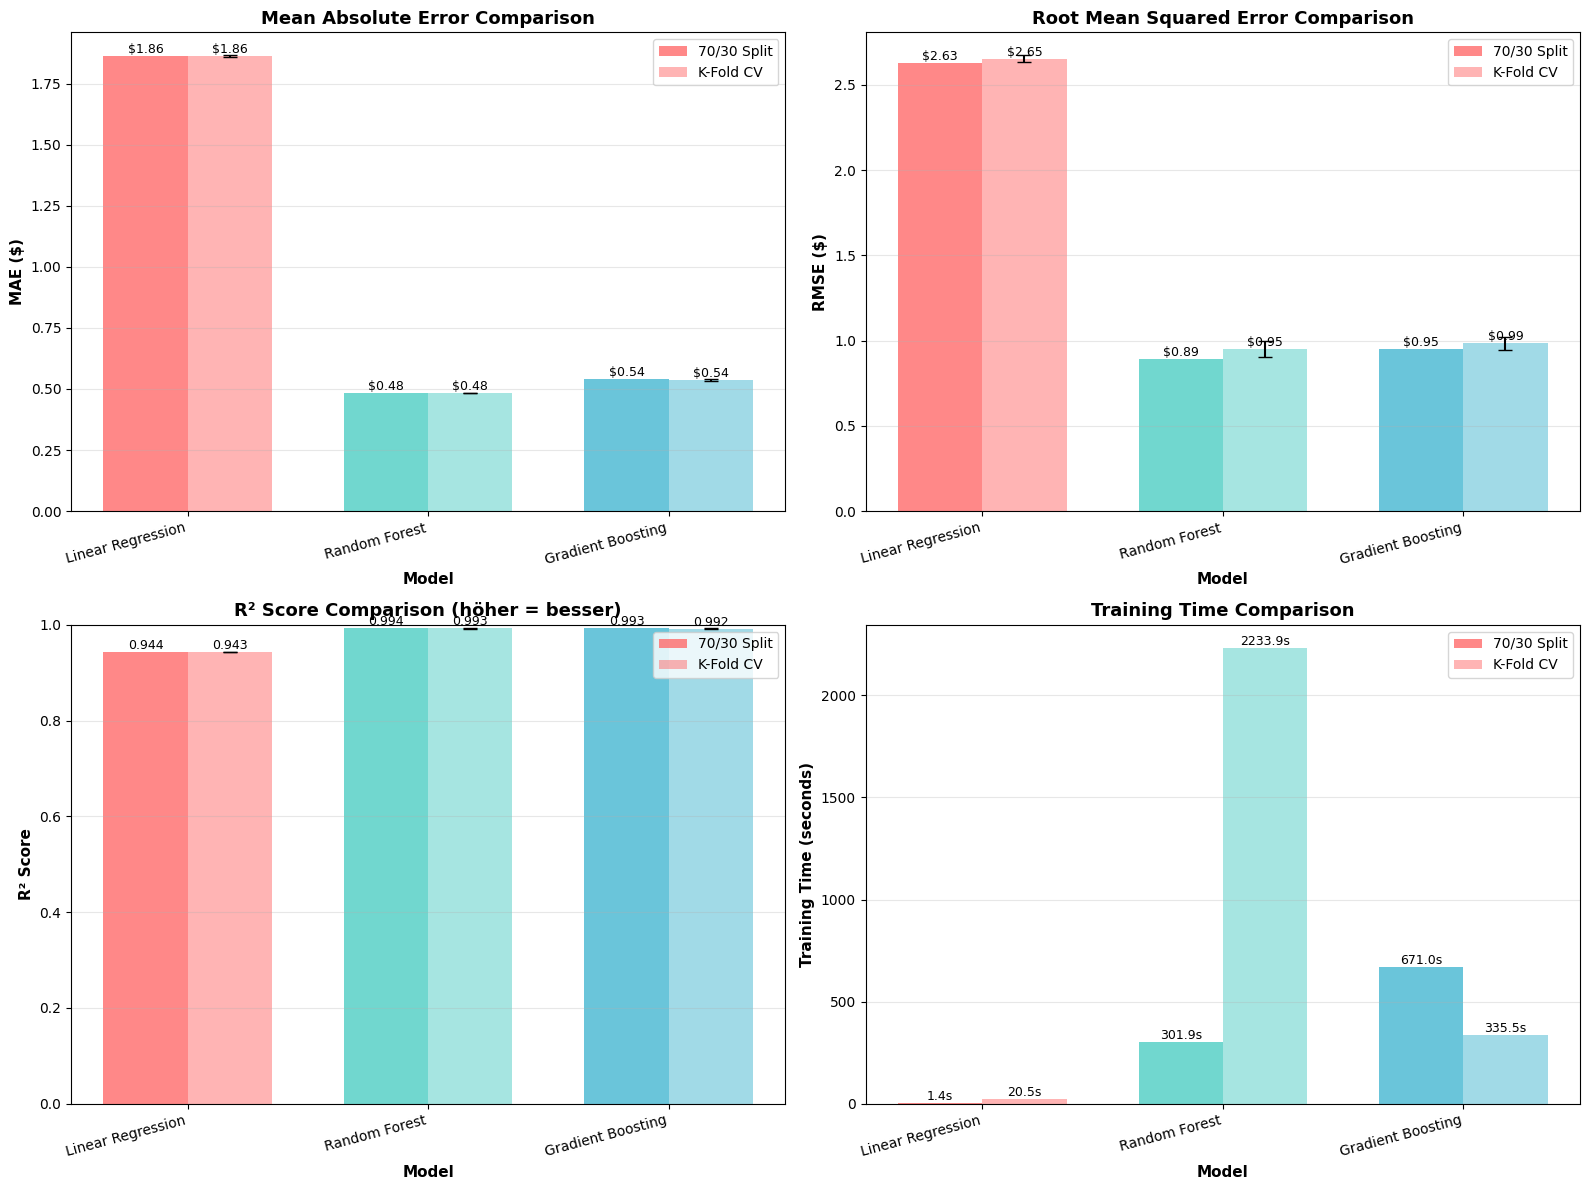

✓ Performance visualization complete


In [44]:
# Visualization of model performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

model_names = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# 1. MAE Comparison
ax1 = axes[0, 0]
mae_70_30 = [results_70_30[m]['mae'] for m in model_names]
mae_kfold = [results_kfold[m]['test_mae_mean'] for m in model_names]
mae_kfold_std = [results_kfold[m]['test_mae_std'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax1.bar(x - width/2, mae_70_30, width, label='70/30 Split', color=colors, alpha=0.8)
bars2 = ax1.bar(x + width/2, mae_kfold, width, yerr=mae_kfold_std, 
                label='K-Fold CV', color=colors, alpha=0.5, capsize=5)

ax1.set_xlabel('Model', fontsize=11, fontweight='bold')
ax1.set_ylabel('MAE ($)', fontsize=11, fontweight='bold')
ax1.set_title('Mean Absolute Error Comparison', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:.2f}', ha='center', va='bottom', fontsize=9)

# 2. RMSE Comparison
ax2 = axes[0, 1]
rmse_70_30 = [results_70_30[m]['rmse'] for m in model_names]
rmse_kfold = [results_kfold[m]['test_rmse_mean'] for m in model_names]
rmse_kfold_std = [results_kfold[m]['test_rmse_std'] for m in model_names]

bars1 = ax2.bar(x - width/2, rmse_70_30, width, label='70/30 Split', color=colors, alpha=0.8)
bars2 = ax2.bar(x + width/2, rmse_kfold, width, yerr=rmse_kfold_std,
                label='K-Fold CV', color=colors, alpha=0.5, capsize=5)

ax2.set_xlabel('Model', fontsize=11, fontweight='bold')
ax2.set_ylabel('RMSE ($)', fontsize=11, fontweight='bold')
ax2.set_title('Root Mean Squared Error Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:.2f}', ha='center', va='bottom', fontsize=9)

# 3. R² Score Comparison
ax3 = axes[1, 0]
r2_70_30 = [results_70_30[m]['r2'] for m in model_names]
r2_kfold = [results_kfold[m]['test_r2_mean'] for m in model_names]
r2_kfold_std = [results_kfold[m]['test_r2_std'] for m in model_names]

bars1 = ax3.bar(x - width/2, r2_70_30, width, label='70/30 Split', color=colors, alpha=0.8)
bars2 = ax3.bar(x + width/2, r2_kfold, width, yerr=r2_kfold_std,
                label='K-Fold CV', color=colors, alpha=0.5, capsize=5)

ax3.set_xlabel('Model', fontsize=11, fontweight='bold')
ax3.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax3.set_title('R² Score Comparison (höher = besser)', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(model_names, rotation=15, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0, 1])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 4. Training Time Comparison
ax4 = axes[1, 1]
time_70_30 = [results_70_30[m]['training_time'] for m in model_names]
time_kfold = [results_kfold[m]['training_time'] for m in model_names]

bars1 = ax4.bar(x - width/2, time_70_30, width, label='70/30 Split', color=colors, alpha=0.8)
bars2 = ax4.bar(x + width/2, time_kfold, width, label='K-Fold CV', color=colors, alpha=0.5)

ax4.set_xlabel('Model', fontsize=11, fontweight='bold')
ax4.set_ylabel('Training Time (seconds)', fontsize=11, fontweight='bold')
ax4.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(model_names, rotation=15, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Performance visualization complete")

### 🎯 Feature Importance Analysis
Welche Features sind am wichtigsten für die Preisvorhersage?

In [45]:
# Feature Importance Analysis
# Note: Linear Regression doesn't have feature_importances_, we'll use coefficients
# Random Forest and Gradient Boosting have feature_importances_

feature_names = X.columns.tolist()

print("="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# 1. Linear Regression - Coefficients (absolute values)
print("\n" + "="*80)
print("LINEAR REGRESSION - Feature Coefficients")
print("="*80)
lr_model = results_70_30['Linear Regression']['model']
lr_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 15 Most Important Features (by absolute coefficient):")
print(lr_coef.head(15).to_string(index=False))
print(f"\nIntercept: ${lr_model.intercept_:.2f}")

# 2. Random Forest - Feature Importance
print("\n" + "="*80)
print("RANDOM FOREST - Feature Importance")
print("="*80)
rf_model = results_70_30['Random Forest']['model']
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(rf_importance.head(15).to_string(index=False))

# 3. Gradient Boosting - Feature Importance
print("\n" + "="*80)
print("GRADIENT BOOSTING - Feature Importance")
print("="*80)
gb_model = results_70_30['Gradient Boosting']['model']
gb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(gb_importance.head(15).to_string(index=False))

FEATURE IMPORTANCE ANALYSIS

LINEAR REGRESSION - Feature Coefficients

Top 15 Most Important Features (by absolute coefficient):
           Feature  Coefficient  Abs_Coefficient
     trip_distance    11.324944        11.324944
      is_overnight    -0.601612         0.601612
 trip_duration_min     0.516605         0.516605
        is_weekend    -0.439173         0.439173
         PU_Queens    -0.406192         0.406192
      PU_Manhattan     0.356134         0.356134
       pickup_hour     0.206349         0.206349
        is_holiday    -0.204677         0.204677
      is_rush_hour    -0.178382         0.178382
         DO_Queens    -0.172071         0.172071
          DO_Bronx    -0.153802         0.153802
pickup_day_of_week     0.127355         0.127355
   passenger_count     0.103589         0.103589
  DO_Staten Island    -0.102884         0.102884
      DO_Manhattan     0.100364         0.100364

Intercept: $15.36

RANDOM FOREST - Feature Importance

Top 15 Most Important Features:

### 📊 Feature Importance Visualization

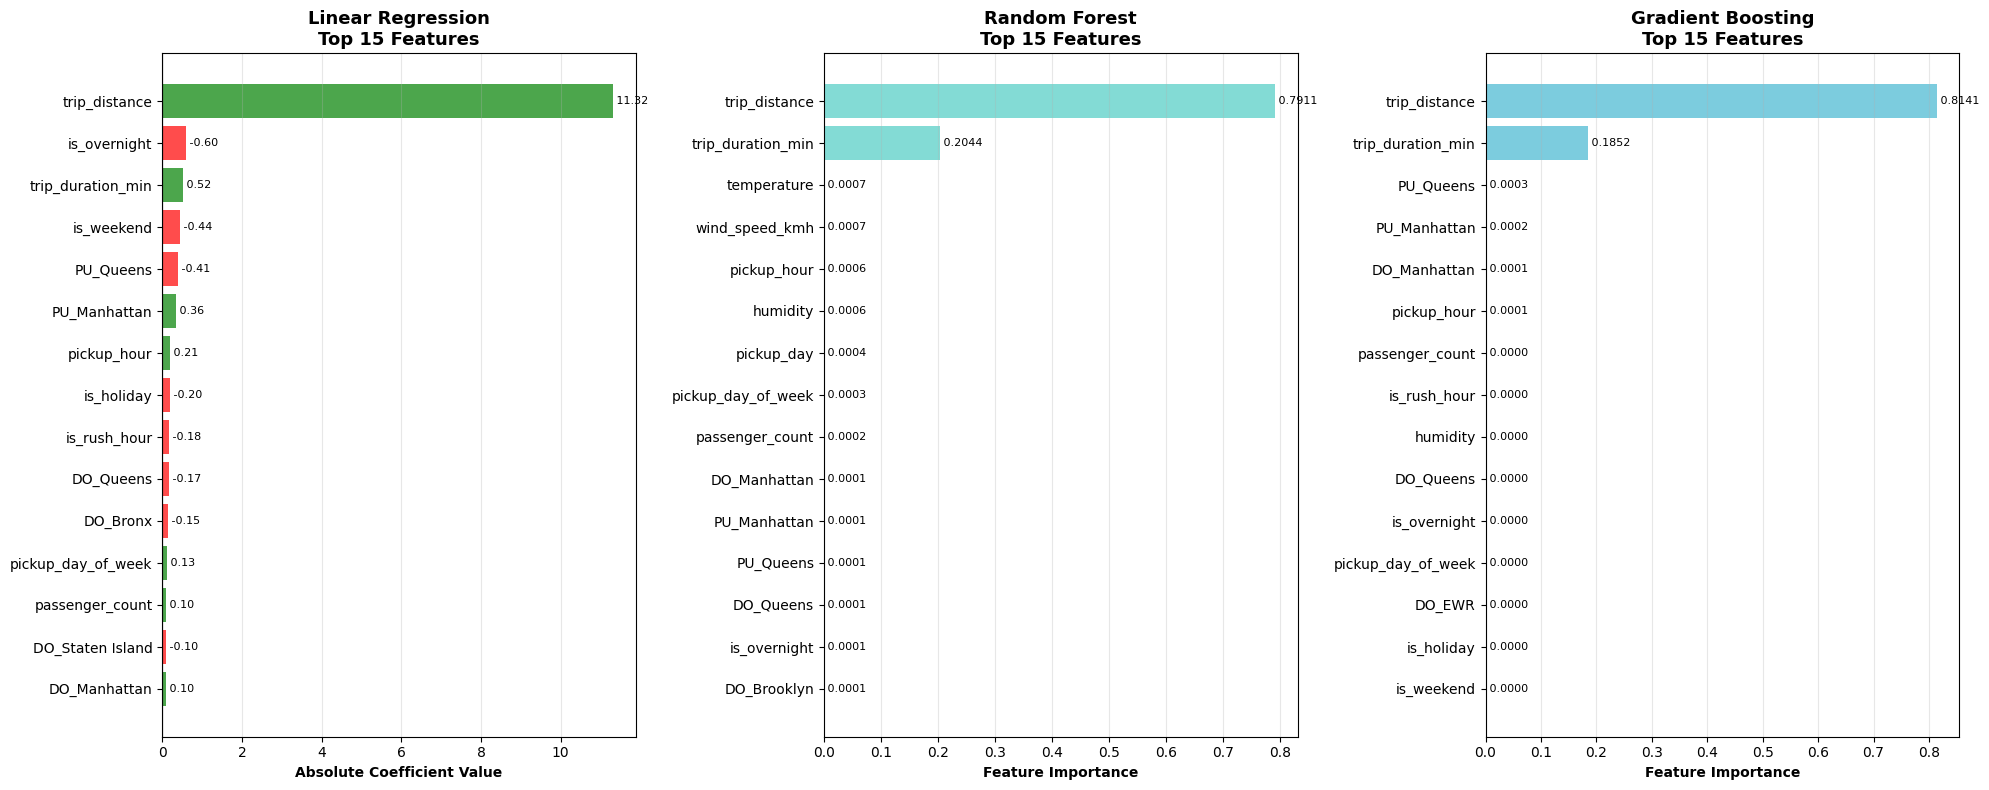

✓ Feature importance visualization complete


In [46]:
# Visualize Feature Importance for all three models
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# 1. Linear Regression - Top 15 coefficients
ax1 = axes[0]
top_lr = lr_coef.head(15).sort_values('Abs_Coefficient')
colors_lr = ['red' if x < 0 else 'green' for x in top_lr['Coefficient']]
ax1.barh(range(len(top_lr)), top_lr['Abs_Coefficient'], color=colors_lr, alpha=0.7)
ax1.set_yticks(range(len(top_lr)))
ax1.set_yticklabels(top_lr['Feature'])
ax1.set_xlabel('Absolute Coefficient Value', fontweight='bold')
ax1.set_title('Linear Regression\nTop 15 Features', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

# Add value labels
for i, (idx, row) in enumerate(top_lr.iterrows()):
    ax1.text(row['Abs_Coefficient'], i, f" {row['Coefficient']:.2f}", 
             va='center', fontsize=8)

# 2. Random Forest - Top 15 importance
ax2 = axes[1]
top_rf = rf_importance.head(15).sort_values('Importance')
ax2.barh(range(len(top_rf)), top_rf['Importance'], color='#4ECDC4', alpha=0.7)
ax2.set_yticks(range(len(top_rf)))
ax2.set_yticklabels(top_rf['Feature'])
ax2.set_xlabel('Feature Importance', fontweight='bold')
ax2.set_title('Random Forest\nTop 15 Features', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(top_rf.iterrows()):
    ax2.text(row['Importance'], i, f" {row['Importance']:.4f}", 
             va='center', fontsize=8)

# 3. Gradient Boosting - Top 15 importance
ax3 = axes[2]
top_gb = gb_importance.head(15).sort_values('Importance')
ax3.barh(range(len(top_gb)), top_gb['Importance'], color='#45B7D1', alpha=0.7)
ax3.set_yticks(range(len(top_gb)))
ax3.set_yticklabels(top_gb['Feature'])
ax3.set_xlabel('Feature Importance', fontweight='bold')
ax3.set_title('Gradient Boosting\nTop 15 Features', fontsize=13, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(top_gb.iterrows()):
    ax3.text(row['Importance'], i, f" {row['Importance']:.4f}", 
             va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Feature importance visualization complete")

### 🎯 Consolidated Feature Importance Ranking
Gemeinsame Top-Features über alle Modelle

CONSOLIDATED FEATURE IMPORTANCE RANKING
Top 20 Features (averaged across all models):

           Feature  LR_Importance  RF_Importance  GB_Importance  Average_Importance
     trip_distance       1.000000       1.000000       1.000000            1.000000
 trip_duration_min       0.045466       0.258352       0.227526            0.177115
      is_overnight       0.052973       0.000091       0.000005            0.017690
        is_weekend       0.038628       0.000051       0.000000            0.012893
         PU_Queens       0.035715       0.000144       0.000311            0.012057
      PU_Manhattan       0.031294       0.000148       0.000226            0.010556
       pickup_hour       0.018066       0.000822       0.000080            0.006322
        is_holiday       0.017918       0.000047       0.000000            0.005989
      is_rush_hour       0.015596       0.000086       0.000017            0.005233
         DO_Queens       0.015039       0.000099       0.000009          

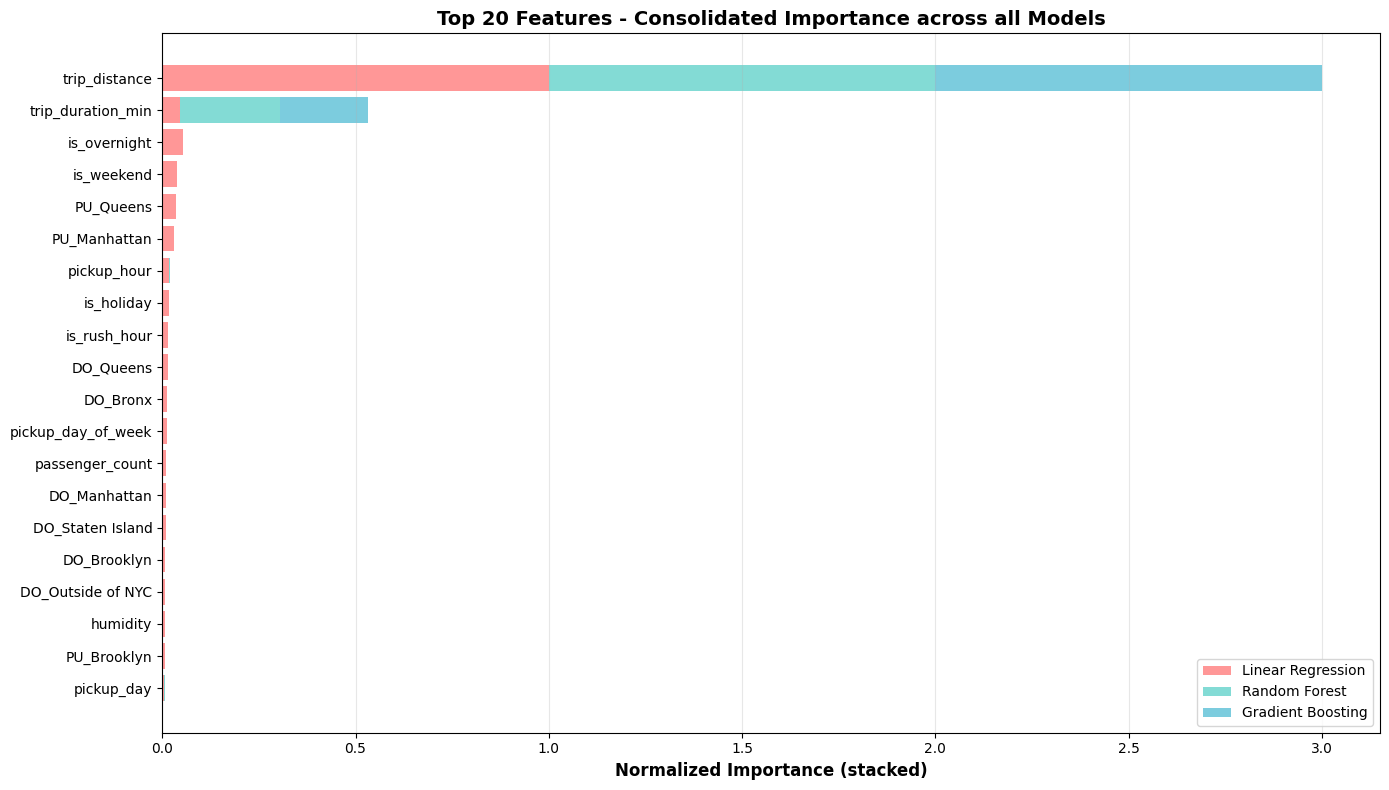


FEATURE CATEGORY ANALYSIS

Importance by Feature Category:
                      Avg Importance  Total Importance  Feature Count
Category                                                             
Trip Characteristics        0.393398          1.180195              3
Temporal                    0.006220          0.031098              5
Pickup Borough              0.003492          0.027933              8
Time Category               0.011461          0.022923              2
Dropoff Borough             0.002666          0.021326              8
Weather                     0.001887          0.005661              3


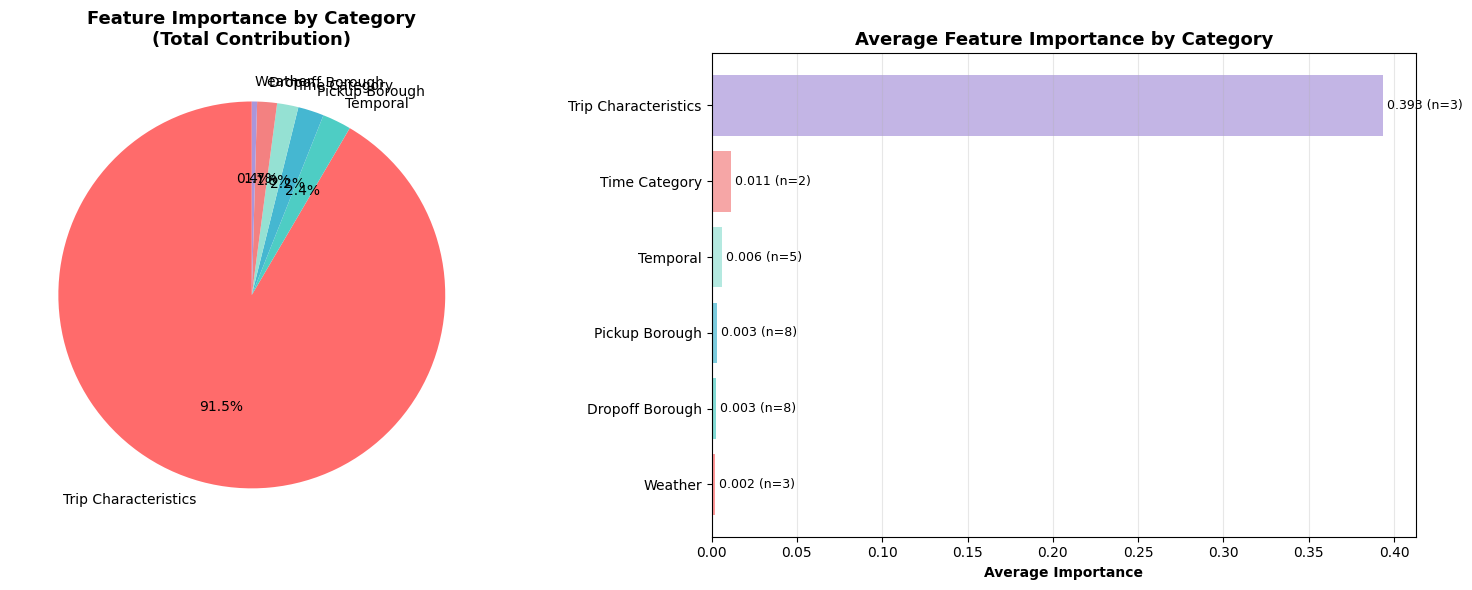


✓ Feature importance analysis complete


In [47]:
# Consolidated Feature Importance
# Normalize and combine importance from all models

# Normalize each model's importance to 0-1 scale
lr_normalized = lr_coef.copy()
lr_normalized['Normalized'] = (lr_normalized['Abs_Coefficient'] - lr_normalized['Abs_Coefficient'].min()) / \
                               (lr_normalized['Abs_Coefficient'].max() - lr_normalized['Abs_Coefficient'].min())

rf_normalized = rf_importance.copy()
rf_normalized['Normalized'] = (rf_normalized['Importance'] - rf_normalized['Importance'].min()) / \
                               (rf_normalized['Importance'].max() - rf_normalized['Importance'].min())

gb_normalized = gb_importance.copy()
gb_normalized['Normalized'] = (gb_normalized['Importance'] - gb_normalized['Importance'].min()) / \
                               (gb_normalized['Importance'].max() - gb_normalized['Importance'].min())

# Combine all features
all_features = pd.DataFrame({
    'Feature': feature_names
})

all_features = all_features.merge(
    lr_normalized[['Feature', 'Normalized']].rename(columns={'Normalized': 'LR_Importance'}),
    on='Feature'
).merge(
    rf_normalized[['Feature', 'Normalized']].rename(columns={'Normalized': 'RF_Importance'}),
    on='Feature'
).merge(
    gb_normalized[['Feature', 'Normalized']].rename(columns={'Normalized': 'GB_Importance'}),
    on='Feature'
)

# Calculate average importance across all models
all_features['Average_Importance'] = all_features[['LR_Importance', 'RF_Importance', 'GB_Importance']].mean(axis=1)
all_features = all_features.sort_values('Average_Importance', ascending=False)

print("="*80)
print("CONSOLIDATED FEATURE IMPORTANCE RANKING")
print("="*80)
print("Top 20 Features (averaged across all models):\n")
print(all_features.head(20).to_string(index=False))

# Visualize consolidated top features
fig, ax = plt.subplots(figsize=(14, 8))

top_20 = all_features.head(20).sort_values('Average_Importance')
y_pos = np.arange(len(top_20))

# Create stacked bars showing contribution from each model
ax.barh(y_pos, top_20['LR_Importance'], label='Linear Regression', alpha=0.7, color='#FF6B6B')
ax.barh(y_pos, top_20['RF_Importance'], left=top_20['LR_Importance'], 
        label='Random Forest', alpha=0.7, color='#4ECDC4')
ax.barh(y_pos, top_20['GB_Importance'], 
        left=top_20['LR_Importance'] + top_20['RF_Importance'],
        label='Gradient Boosting', alpha=0.7, color='#45B7D1')

ax.set_yticks(y_pos)
ax.set_yticklabels(top_20['Feature'])
ax.set_xlabel('Normalized Importance (stacked)', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Features - Consolidated Importance across all Models', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Feature categories analysis
print("\n" + "="*80)
print("FEATURE CATEGORY ANALYSIS")
print("="*80)

def categorize_feature(feature):
    if 'PU_' in feature:
        return 'Pickup Borough'
    elif 'DO_' in feature:
        return 'Dropoff Borough'
    elif feature in ['temperature', 'humidity', 'wind_speed_kmh']:
        return 'Weather'
    elif feature in ['pickup_hour', 'pickup_day', 'pickup_day_of_week', 'is_weekend', 'is_holiday']:
        return 'Temporal'
    elif feature in ['is_rush_hour', 'is_overnight']:
        return 'Time Category'
    else:
        return 'Trip Characteristics'

all_features['Category'] = all_features['Feature'].apply(categorize_feature)

category_importance = all_features.groupby('Category')['Average_Importance'].agg(['mean', 'sum', 'count'])
category_importance = category_importance.sort_values('sum', ascending=False)
category_importance.columns = ['Avg Importance', 'Total Importance', 'Feature Count']

print("\nImportance by Feature Category:")
print(category_importance)

# Visualize category importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart for total importance
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#F38181', '#AA96DA']
ax1.pie(category_importance['Total Importance'], labels=category_importance.index, 
        autopct='%1.1f%%', startangle=90, colors=colors_pie)
ax1.set_title('Feature Importance by Category\n(Total Contribution)', 
              fontsize=13, fontweight='bold')

# Bar chart for average importance
category_importance_sorted = category_importance.sort_values('Avg Importance')
ax2.barh(range(len(category_importance_sorted)), category_importance_sorted['Avg Importance'], 
         color=colors_pie[:len(category_importance_sorted)], alpha=0.7)
ax2.set_yticks(range(len(category_importance_sorted)))
ax2.set_yticklabels(category_importance_sorted.index)
ax2.set_xlabel('Average Importance', fontweight='bold')
ax2.set_title('Average Feature Importance by Category', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add feature count labels
for i, (idx, row) in enumerate(category_importance_sorted.iterrows()):
    ax2.text(row['Avg Importance'], i, f" {row['Avg Importance']:.3f} (n={int(row['Feature Count'])})", 
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Feature importance analysis complete")

Scatter Plot von predicted vs actual (über Testdatensatz)

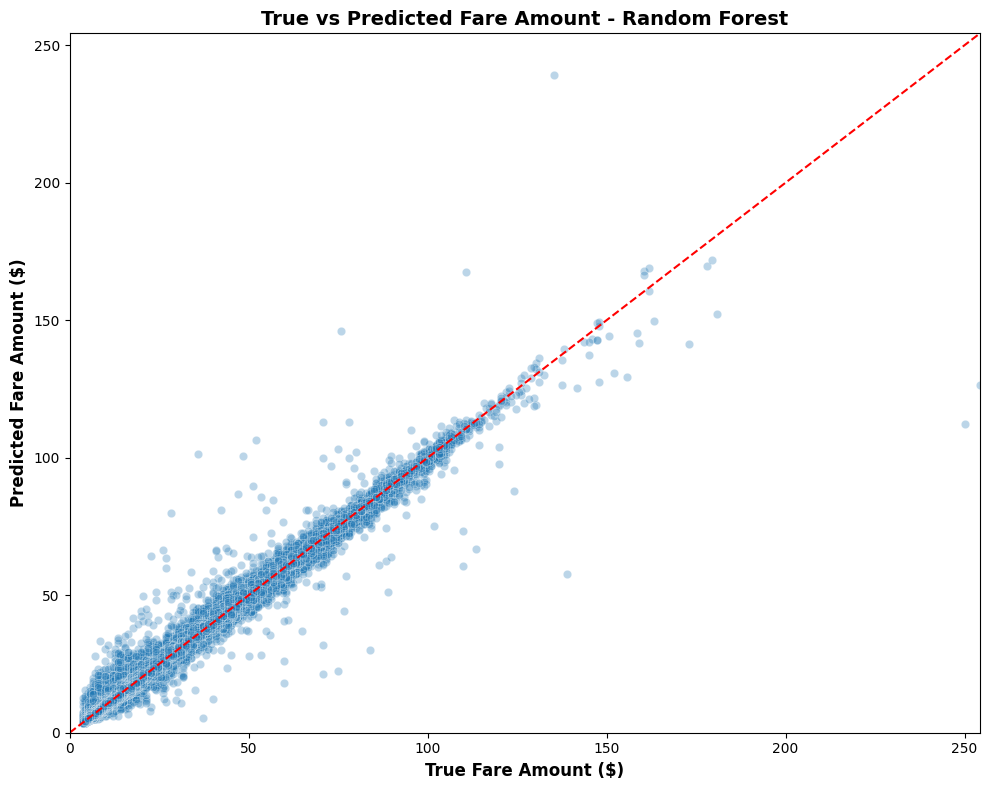

In [48]:
# Scatter Plot von predicted vs actual (über Testdatensatz)
# Robust handling if variables are not present in the current namespace.

# Helper to display an informative message and skip plotting
from IPython.display import display, Markdown

# If results_70_30 is missing, try to build a quick baseline model if train/test data exists
if 'results_70_30' not in globals():
	print("⚠️ results_70_30 not found. Attempting to build a quick baseline Linear Regression (if training data available)...")
	# Check for train/test split variables
	if all(var in globals() for var in ['X_train', 'X_test', 'y_train', 'y_test']):
		# Ensure scaler exists or create one
		if 'scaler' not in globals():
			from sklearn.preprocessing import StandardScaler
			scaler = StandardScaler()
			X_train_scaled = scaler.fit_transform(X_train)
			X_test_scaled = scaler.transform(X_test)
		else:
			# prefer existing scaled arrays if present
			if 'X_train_scaled' not in globals():
				X_train_scaled = scaler.fit_transform(X_train)
			if 'X_test_scaled' not in globals():
				X_test_scaled = scaler.transform(X_test)
		# Ensure LinearRegression is available
		if 'LinearRegression' not in globals():
			from sklearn.linear_model import LinearRegression
		# Train a quick baseline model
		lr_baseline = LinearRegression()
		lr_baseline.fit(X_train_scaled, y_train)
		# Predict on test set
		y_pred_baseline = lr_baseline.predict(X_test_scaled)
		# Compute simple metrics if sklearn.metrics available
		try:
			from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
			mae = mean_absolute_error(y_test, y_pred_baseline)
			rmse = (mean_squared_error(y_test, y_pred_baseline, squared=False))
			r2 = r2_score(y_test, y_pred_baseline)
		except Exception:
			mae = rmse = r2 = None
		# Create results_70_30 dict so the rest of the cell can run unchanged
		results_70_30 = {
			'Baseline Linear Regression': {
				'model': lr_baseline,
				'mae': mae if mae is not None else float('inf'),
				'rmse': rmse if rmse is not None else float('inf'),
				'r2': r2 if r2 is not None else float('-inf'),
				'training_time': 0.0,
				'predictions': y_pred_baseline
			}
		}
		best_model_name = 'Baseline Linear Regression'
		print(f"✓ Baseline trained and stored as results_70_30['{best_model_name}']")
	else:
		msg = ("❌ Cannot produce plot: results_70_30 not found and train/test split variables "
			   "(X_train, X_test, y_train, y_test) are not available. "
			   "Please run the modeling cells (70/30 split and model training) first.")
		display(Markdown(f"**{msg}**"))
		# Skip plotting by exiting the cell gracefully
		_skip_plot = True

# If we previously skipped, stop here
if globals().get('_skip_plot', False):
	# cleanup helper variable
	del _skip_plot
else:
	# Determine best model name by lowest MAE if not already set
	if 'best_model_name' not in globals():
		best_model_name = min(results_70_30.items(), key=lambda x: x[1].get('mae', float('inf')))[0]

	best_model = results_70_30[best_model_name].get('model')

	# Ensure y_test exists
	if 'y_test' not in globals():
		display(Markdown("**❌ y_test not found. Please run the train/test split cell before plotting.**"))
	else:
		# Get predictions: prefer stored predictions, otherwise predict using the stored model
		y_pred_best = results_70_30[best_model_name].get('predictions')
		if y_pred_best is None:
			if best_model is None:
				display(Markdown(f"**❌ No trained model object found for '{best_model_name}'.**"))
			else:
				# Prefer X_test_scaled if available, otherwise try to scale X_test if scaler exists or use raw X_test
				if 'X_test_scaled' in globals():
					X_to_pred = X_test_scaled
				elif 'X_test' in globals():
					if 'scaler' in globals():
						X_to_pred = scaler.transform(X_test)
					else:
						X_to_pred = X_test.values
				else:
					display(Markdown("**❌ X_test not found. Please run the train/test split cell before plotting.**"))
					X_to_pred = None

				if X_to_pred is not None:
					y_pred_best = best_model.predict(X_to_pred)

		# If still no predictions, abort gracefully
		if y_pred_best is None:
			display(Markdown("**❌ Could not obtain predictions for plotting.**"))
		else:
			# Align lengths and convert to numpy arrays
			y_true = np.asarray(y_test)
			y_pred_best = np.asarray(y_pred_best)
			min_len = min(len(y_true), len(y_pred_best))
			y_true = y_true[:min_len]
			y_pred_best = y_pred_best[:min_len]

			plt.figure(figsize=(10, 8))
			sns.scatterplot(x=y_true, y=y_pred_best, alpha=0.3)
			lims = [0, max(y_true.max() if len(y_true)>0 else 0, y_pred_best.max() if len(y_pred_best)>0 else 0)]
			plt.plot(lims, lims, color='red', linestyle='--')
			plt.xlabel('True Fare Amount ($)', fontsize=12, fontweight='bold')
			plt.ylabel('Predicted Fare Amount ($)', fontsize=12, fontweight='bold')
			plt.title(f'True vs Predicted Fare Amount - {best_model_name}', fontsize=14, fontweight='bold')
			plt.xlim(0, lims[1])
			plt.ylim(0, lims[1])
			plt.tight_layout()
			plt.show()

COMPREHENSIVE MODEL PERFORMANCE VISUALIZATION

COMPREHENSIVE MODEL PERFORMANCE VISUALIZATION


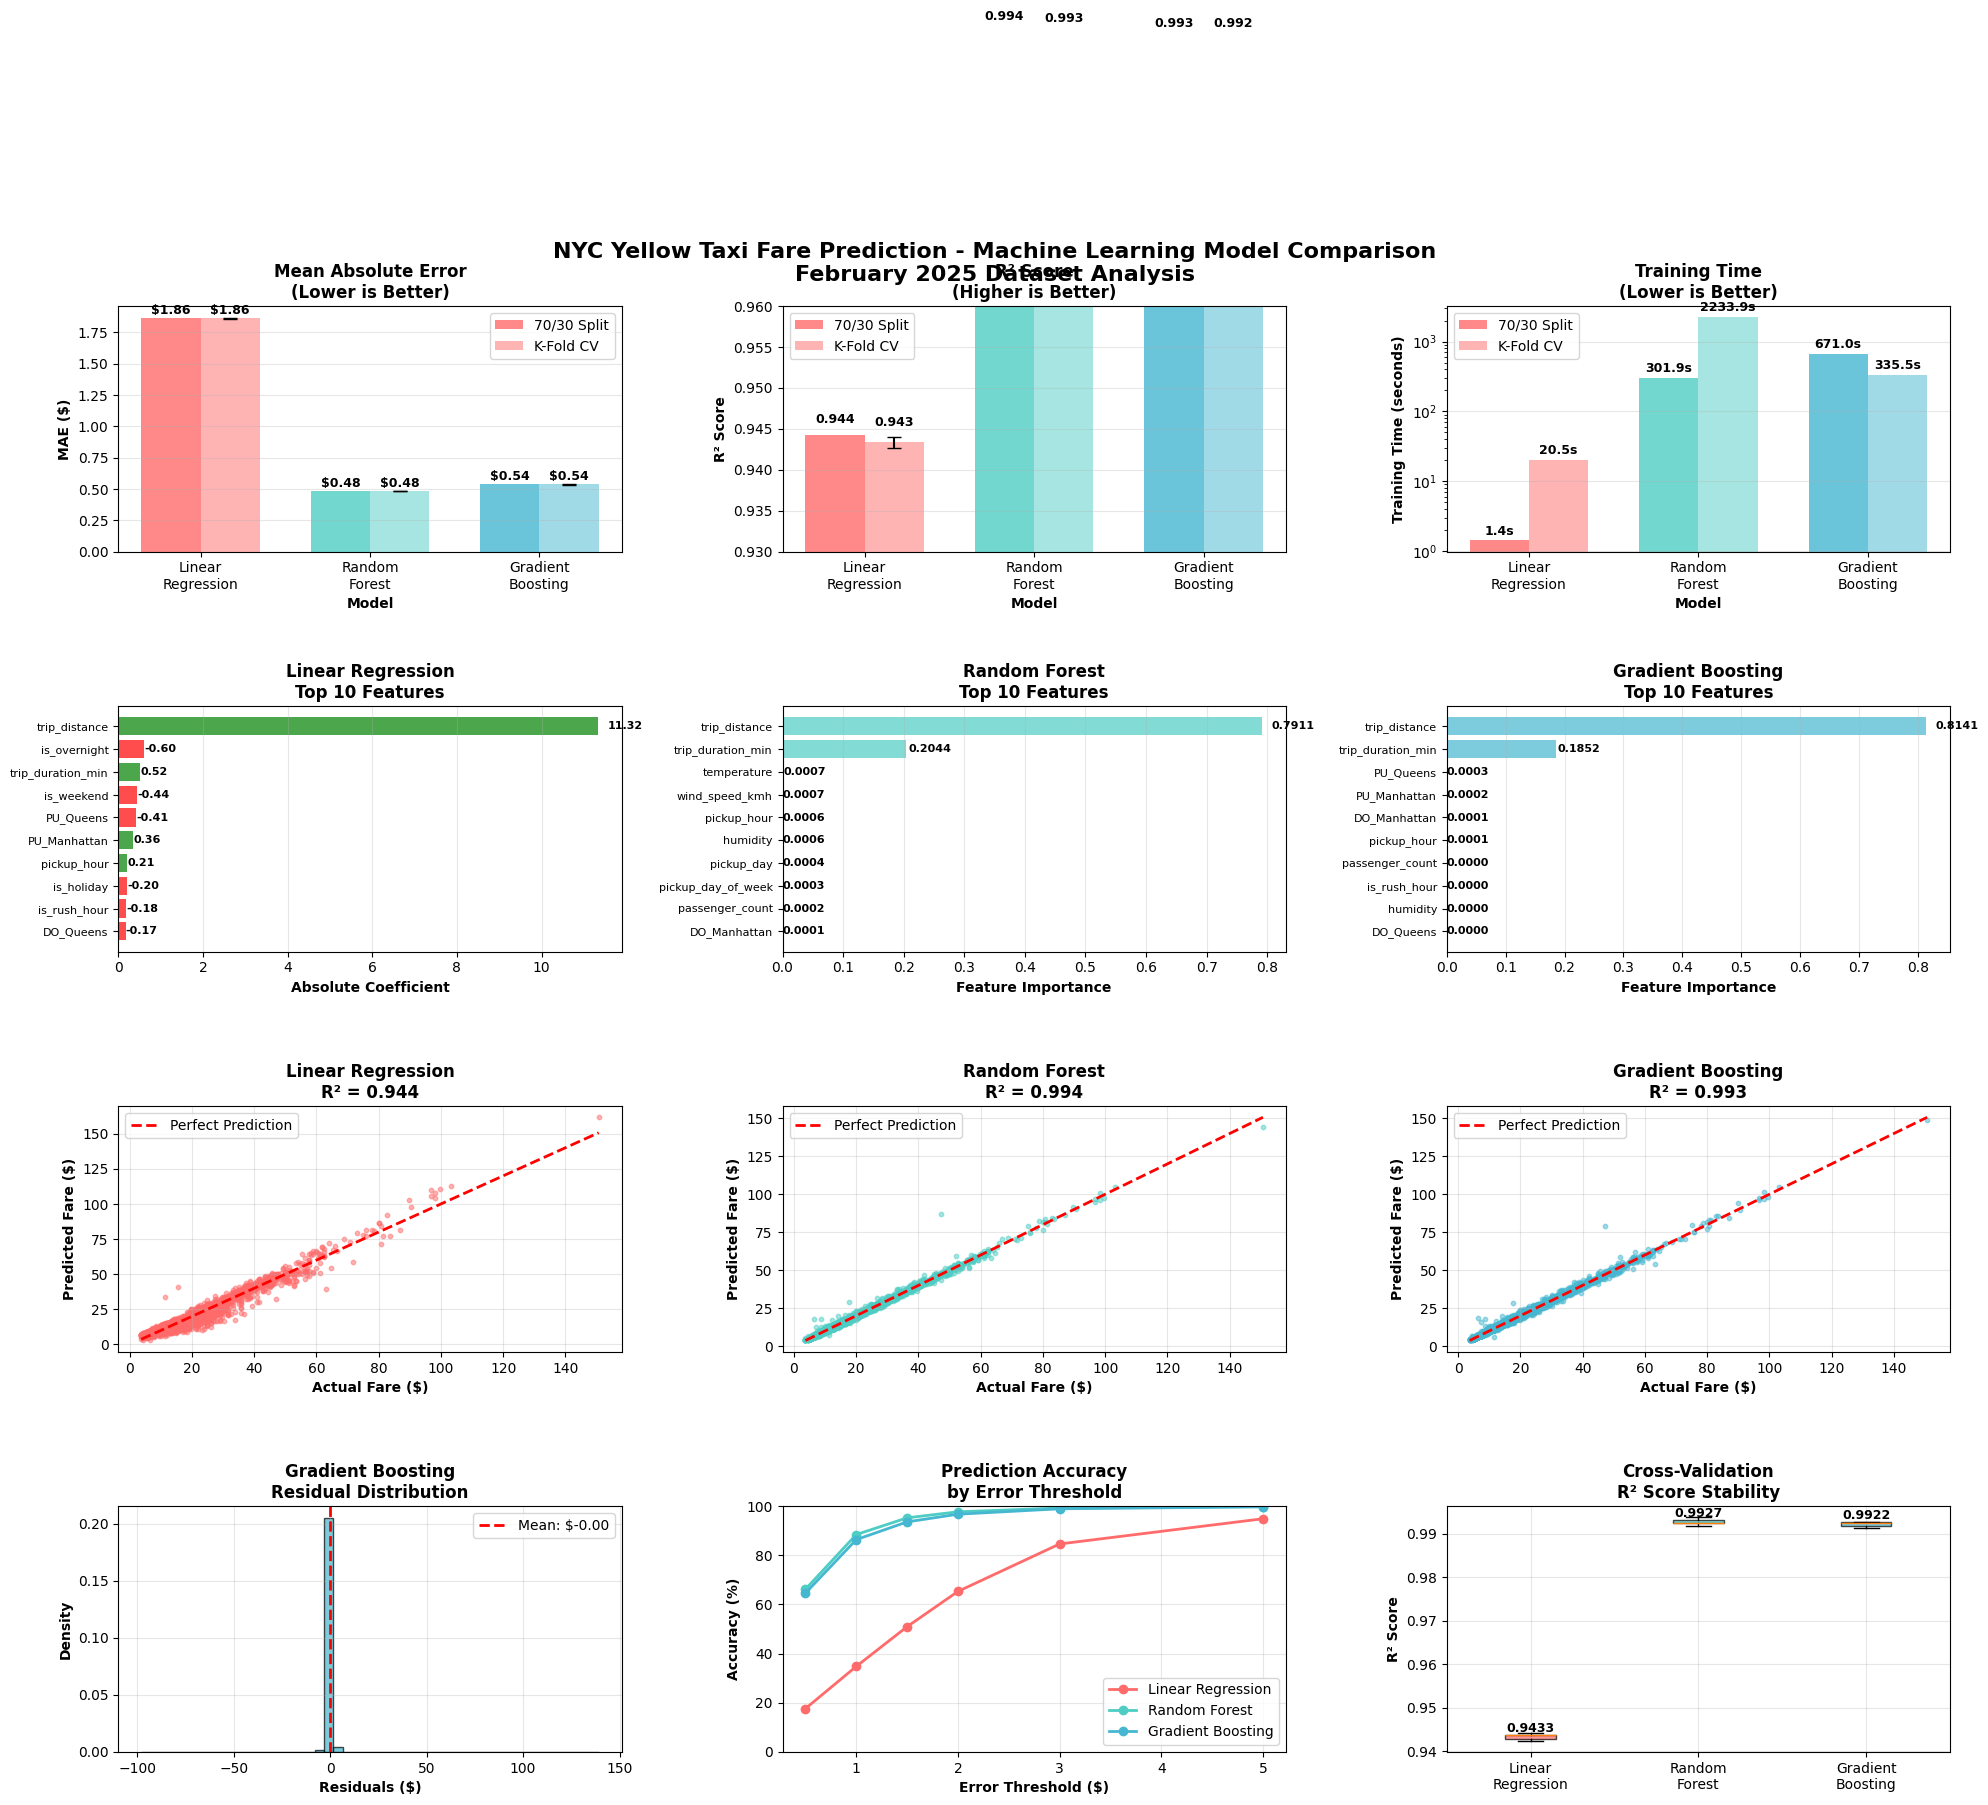


FINAL MODEL PERFORMANCE SUMMARY
            Model Split Method     MAE ($)    RMSE ($)        R² Score Training Time    Prediction Quality
Linear Regression  70/30 Split        1.86        2.63          0.9443          1.4s       65.3% within $2
Linear Regression    K-Fold CV 1.86 ± 0.00 2.65 ± 0.02 0.9433 ± 0.0007         20.5s Stable across 5 folds
    Random Forest  70/30 Split        0.48        0.89          0.9936        301.9s       97.7% within $2
    Random Forest    K-Fold CV 0.48 ± 0.00 0.95 ± 0.05 0.9927 ± 0.0007       2233.9s Stable across 5 folds
Gradient Boosting  70/30 Split        0.54        0.95          0.9927        671.0s       96.7% within $2
Gradient Boosting    K-Fold CV 0.54 ± 0.00 0.99 ± 0.04 0.9922 ± 0.0006        335.5s Stable across 5 folds

🏆 RECOMMENDATION
Best Performing Model: Random Forest
  • R² Score: 0.9936 (99.36% variance explained)
  • MAE: $0.48 (average prediction error)
  • RMSE: $0.89
  • Training Time: 301.9 seconds

💡 Prediction Accuracy:

In [49]:
# =============================================================================
# COMPREHENSIVE MODEL PERFORMANCE VISUALIZATION
# =============================================================================
 
print("="*80)
print("COMPREHENSIVE MODEL PERFORMANCE VISUALIZATION")
print("="*80)
 
# Create a comprehensive visualization dashboard
fig = plt.figure(figsize=(20, 16))
 
# Define colors for each model
model_colors = {
    'Linear Regression': '#FF6B6B',
    'Random Forest': '#4ECDC4',
    'Gradient Boosting': '#45B7D1'
}
 
# ============================================================================
# 1. Model Performance Comparison (2x2 subplot)
# ============================================================================
 
# 1.1 MAE Comparison
ax1 = plt.subplot(4, 3, 1)
mae_70_30 = [results_70_30[m]['mae'] for m in model_names]
mae_kfold = [results_kfold[m]['test_mae_mean'] for m in model_names]
mae_kfold_std = [results_kfold[m]['test_mae_std'] for m in model_names]
 
x = np.arange(len(model_names))
width = 0.35
 
bars1 = ax1.bar(x - width/2, mae_70_30, width, label='70/30 Split',
                color=[model_colors[m] for m in model_names], alpha=0.8)
bars2 = ax1.bar(x + width/2, mae_kfold, width, yerr=mae_kfold_std,
                label='K-Fold CV', color=[model_colors[m] for m in model_names],
                alpha=0.5, capsize=5)
 
ax1.set_xlabel('Model', fontweight='bold')
ax1.set_ylabel('MAE ($)', fontweight='bold')
ax1.set_title('Mean Absolute Error\n(Lower is Better)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([name.replace(' ', '\n') for name in model_names])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
 
# Add value labels
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    ax1.text(bar1.get_x() + bar1.get_width()/2., bar1.get_height() + 0.01,
             f'${mae_70_30[i]:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax1.text(bar2.get_x() + bar2.get_width()/2., bar2.get_height() + mae_kfold_std[i] + 0.01,
             f'${mae_kfold[i]:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
 
# 1.2 R² Score Comparison
ax2 = plt.subplot(4, 3, 2)
r2_70_30 = [results_70_30[m]['r2'] for m in model_names]
r2_kfold = [results_kfold[m]['test_r2_mean'] for m in model_names]
r2_kfold_std = [results_kfold[m]['test_r2_std'] for m in model_names]
 
bars1 = ax2.bar(x - width/2, r2_70_30, width, label='70/30 Split',
                color=[model_colors[m] for m in model_names], alpha=0.8)
bars2 = ax2.bar(x + width/2, r2_kfold, width, yerr=r2_kfold_std,
                label='K-Fold CV', color=[model_colors[m] for m in model_names],
                alpha=0.5, capsize=5)
 
ax2.set_xlabel('Model', fontweight='bold')
ax2.set_ylabel('R² Score', fontweight='bold')
ax2.set_title('R² Score\n(Higher is Better)', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([name.replace(' ', '\n') for name in model_names])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0.93, 0.96])
 
# Add value labels
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    ax2.text(bar1.get_x() + bar1.get_width()/2., bar1.get_height() + 0.001,
             f'{r2_70_30[i]:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.text(bar2.get_x() + bar2.get_width()/2., bar2.get_height() + r2_kfold_std[i] + 0.001,
             f'{r2_kfold[i]:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
 
# 1.3 Training Time Comparison
ax3 = plt.subplot(4, 3, 3)
time_70_30 = [results_70_30[m]['training_time'] for m in model_names]
time_kfold = [results_kfold[m]['training_time'] for m in model_names]
bars1 = ax3.bar(x - width/2, time_70_30, width, label='70/30 Split',
                color=[model_colors[m] for m in model_names], alpha=0.8)
bars2 = ax3.bar(x + width/2, time_kfold, width, label='K-Fold CV',
                color=[model_colors[m] for m in model_names], alpha=0.5)
 
ax3.set_xlabel('Model', fontweight='bold')
ax3.set_ylabel('Training Time (seconds)', fontweight='bold')
ax3.set_title('Training Time\n(Lower is Better)', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([name.replace(' ', '\n') for name in model_names])
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_yscale('log')  # Log scale due to large differences
 
# Add value labels
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    ax3.text(bar1.get_x() + bar1.get_width()/2., bar1.get_height() * 1.1,
             f'{time_70_30[i]:.1f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax3.text(bar2.get_x() + bar2.get_width()/2., bar2.get_height() * 1.1,
             f'{time_kfold[i]:.1f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
 
# ============================================================================
# 2. Feature Importance Comparison (Top 10 for each model)
# ============================================================================
 
# 2.1 Linear Regression - Top 10 Coefficients
ax4 = plt.subplot(4, 3, 4)
top_lr_10 = lr_coef.head(10).sort_values('Abs_Coefficient')
colors_lr = ['red' if x < 0 else 'green' for x in top_lr_10['Coefficient']]
bars = ax4.barh(range(len(top_lr_10)), top_lr_10['Abs_Coefficient'],
                color=colors_lr, alpha=0.7)
ax4.set_yticks(range(len(top_lr_10)))
ax4.set_yticklabels(top_lr_10['Feature'], fontsize=8)
ax4.set_xlabel('Absolute Coefficient', fontweight='bold')
ax4.set_title('Linear Regression\nTop 10 Features', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)
 
# Add value labels
for i, (idx, row) in enumerate(top_lr_10.iterrows()):
    ax4.text(row['Abs_Coefficient'] * 1.02, i, f"{row['Coefficient']:.2f}",
             va='center', fontsize=8, fontweight='bold')
 
# 2.2 Random Forest - Top 10 Importance
ax5 = plt.subplot(4, 3, 5)
top_rf_10 = rf_importance.head(10).sort_values('Importance')
bars = ax5.barh(range(len(top_rf_10)), top_rf_10['Importance'],
                color='#4ECDC4', alpha=0.7)
ax5.set_yticks(range(len(top_rf_10)))
ax5.set_yticklabels(top_rf_10['Feature'], fontsize=8)
ax5.set_xlabel('Feature Importance', fontweight='bold')
ax5.set_title('Random Forest\nTop 10 Features', fontweight='bold')
ax5.grid(axis='x', alpha=0.3)
 
# Add value labels
for i, (idx, row) in enumerate(top_rf_10.iterrows()):
    ax5.text(row['Importance'] * 1.02, i, f"{row['Importance']:.4f}",
             va='center', fontsize=8, fontweight='bold')
 
# 2.3 Gradient Boosting - Top 10 Importance
ax6 = plt.subplot(4, 3, 6)
top_gb_10 = gb_importance.head(10).sort_values('Importance')
bars = ax6.barh(range(len(top_gb_10)), top_gb_10['Importance'],
                color='#45B7D1', alpha=0.7)
ax6.set_yticks(range(len(top_gb_10)))
ax6.set_yticklabels(top_gb_10['Feature'], fontsize=8)
ax6.set_xlabel('Feature Importance', fontweight='bold')
ax6.set_title('Gradient Boosting\nTop 10 Features', fontweight='bold')
ax6.grid(axis='x', alpha=0.3)
 
# Add value labels
for i, (idx, row) in enumerate(top_gb_10.iterrows()):
    ax6.text(row['Importance'] * 1.02, i, f"{row['Importance']:.4f}",
             va='center', fontsize=8, fontweight='bold')
 
# ============================================================================
# 3. Prediction vs Actual Scatter Plots
# ============================================================================
 
# Sample 5000 random points for visualization
sample_indices = np.random.choice(len(y_test), size=min(5000, len(y_test)), replace=False)
y_test_sample = y_test.iloc[sample_indices]
 
# 3.1 Linear Regression Predictions
ax7 = plt.subplot(4, 3, 7)
lr_pred_sample = results_70_30['Linear Regression']['predictions'][sample_indices]
ax7.scatter(y_test_sample, lr_pred_sample, alpha=0.5, s=10, color=model_colors['Linear Regression'])
ax7.plot([y_test_sample.min(), y_test_sample.max()], [y_test_sample.min(), y_test_sample.max()],
         'r--', lw=2, label='Perfect Prediction')
ax7.set_xlabel('Actual Fare ($)', fontweight='bold')
ax7.set_ylabel('Predicted Fare ($)', fontweight='bold')
ax7.set_title(f'Linear Regression\nR² = {results_70_30["Linear Regression"]["r2"]:.3f}', fontweight='bold')
ax7.grid(alpha=0.3)
ax7.legend()
 
# 3.2 Random Forest Predictions
ax8 = plt.subplot(4, 3, 8)
rf_pred_sample = results_70_30['Random Forest']['predictions'][sample_indices]
ax8.scatter(y_test_sample, rf_pred_sample, alpha=0.5, s=10, color=model_colors['Random Forest'])
ax8.plot([y_test_sample.min(), y_test_sample.max()], [y_test_sample.min(), y_test_sample.max()],
         'r--', lw=2, label='Perfect Prediction')
ax8.set_xlabel('Actual Fare ($)', fontweight='bold')
ax8.set_ylabel('Predicted Fare ($)', fontweight='bold')
ax8.set_title(f'Random Forest\nR² = {results_70_30["Random Forest"]["r2"]:.3f}', fontweight='bold')
ax8.grid(alpha=0.3)
ax8.legend()
 
# 3.3 Gradient Boosting Predictions
ax9 = plt.subplot(4, 3, 9)
gb_pred_sample = results_70_30['Gradient Boosting']['predictions'][sample_indices]
ax9.scatter(y_test_sample, gb_pred_sample, alpha=0.5, s=10, color=model_colors['Gradient Boosting'])
ax9.plot([y_test_sample.min(), y_test_sample.max()], [y_test_sample.min(), y_test_sample.max()],
         'r--', lw=2, label='Perfect Prediction')
ax9.set_xlabel('Actual Fare ($)', fontweight='bold')
ax9.set_ylabel('Predicted Fare ($)', fontweight='bold')
ax9.set_title(f'Gradient Boosting\nR² = {results_70_30["Gradient Boosting"]["r2"]:.3f}', fontweight='bold')
ax9.grid(alpha=0.3)
ax9.legend()
 
# ============================================================================
# 4. Residual Analysis
# ============================================================================
 
# 4.1 Residual Distribution for Gradient Boosting (Best Model)
ax10 = plt.subplot(4, 3, 10)
gb_residuals = y_test - results_70_30['Gradient Boosting']['predictions']
ax10.hist(gb_residuals, bins=50, alpha=0.7, color=model_colors['Gradient Boosting'],
          density=True, edgecolor='black')
ax10.axvline(gb_residuals.mean(), color='red', linestyle='--', linewidth=2,
             label=f'Mean: ${gb_residuals.mean():.2f}')
ax10.set_xlabel('Residuals ($)', fontweight='bold')
ax10.set_ylabel('Density', fontweight='bold')
ax10.set_title('Gradient Boosting\nResidual Distribution', fontweight='bold')
ax10.grid(alpha=0.3)
ax10.legend()
 
# 4.2 Model Accuracy Within Error Thresholds
ax11 = plt.subplot(4, 3, 11)
error_thresholds = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
accuracy_data = {model_name: [] for model_name in model_names}
 
for model_name in model_names:
    predictions = results_70_30[model_name]['predictions']
    errors = np.abs(y_test - predictions)
    
    for threshold in error_thresholds:
        accuracy = (errors <= threshold).mean() * 100
        accuracy_data[model_name].append(accuracy)
 
for model_name in model_names:
    ax11.plot(error_thresholds, accuracy_data[model_name],
              marker='o', linewidth=2, label=model_name,
              color=model_colors[model_name])
 
ax11.set_xlabel('Error Threshold ($)', fontweight='bold')
ax11.set_ylabel('Accuracy (%)', fontweight='bold')
ax11.set_title('Prediction Accuracy\nby Error Threshold', fontweight='bold')
ax11.grid(alpha=0.3)
ax11.legend()
ax11.set_ylim([0, 100])
 
# 4.3 Cross-Validation Stability
ax12 = plt.subplot(4, 3, 12)
cv_data = []
for model_name in model_names:
    cv_scores = results_kfold[model_name]['cv_results']['test_r2']
    for i, score in enumerate(cv_scores):
        cv_data.append({
            'Model': model_name.replace(' ', '\n'),
            'Fold': f'Fold {i+1}',
            'R2_Score': score
        })
 
cv_df = pd.DataFrame(cv_data)
 
# Create box plot
bp = ax12.boxplot([results_kfold[m]['cv_results']['test_r2'] for m in model_names],
                  patch_artist=True, tick_labels=[name.replace(' ', '\n') for name in model_names])
 
# Color the boxes
for patch, model_name in zip(bp['boxes'], model_names):
    patch.set_facecolor(model_colors[model_name])
    patch.set_alpha(0.7)
 
ax12.set_ylabel('R² Score', fontweight='bold')
ax12.set_title('Cross-Validation\nR² Score Stability', fontweight='bold')
ax12.grid(alpha=0.3)
 
# Add mean values as text
for i, model_name in enumerate(model_names):
    mean_r2 = results_kfold[model_name]['test_r2_mean']
    ax12.text(i+1, mean_r2 + 0.0005, f'{mean_r2:.4f}',
              ha='center', va='bottom', fontweight='bold', fontsize=9)
 
plt.suptitle('NYC Yellow Taxi Fare Prediction - Machine Learning Model Comparison\n' +
             'February 2025 Dataset Analysis\n\n',
             fontsize=16, fontweight='bold', y=0.98)
 
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

# ============================================================================
# SUMMARY STATISTICS TABLE
# ============================================================================
 
print("\n" + "="*80)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*80)
 
# Create comprehensive summary table
summary_data = []
for model_name in model_names:
    # 70/30 Split
    r70 = results_70_30[model_name]
    summary_data.append({
        'Model': model_name,
        'Split Method': '70/30 Split',
        'MAE ($)': f"{r70['mae']:.2f}",
        'RMSE ($)': f"{r70['rmse']:.2f}",
        'R² Score': f"{r70['r2']:.4f}",
        'Training Time': f"{r70['training_time']:.1f}s",
        'Prediction Quality': f"{(np.abs(y_test - r70['predictions']) <= 2.0).mean()*100:.1f}% within $2"
    })
    
    # K-Fold CV
    rkf = results_kfold[model_name]
    summary_data.append({
        'Model': model_name,
        'Split Method': 'K-Fold CV',
        'MAE ($)': f"{rkf['test_mae_mean']:.2f} ± {rkf['test_mae_std']:.2f}",
        'RMSE ($)': f"{rkf['test_rmse_mean']:.2f} ± {rkf['test_rmse_std']:.2f}",
        'R² Score': f"{rkf['test_r2_mean']:.4f} ± {rkf['test_r2_std']:.4f}",
        'Training Time': f"{rkf['training_time']:.1f}s",
        'Prediction Quality': f"Stable across {len(rkf['cv_results']['test_r2'])} folds"
    })
 
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
 
# Best model recommendation
best_model_name = max(results_70_30.keys(), key=lambda x: results_70_30[x]['r2'])
best_model_r2 = results_70_30[best_model_name]['r2']
best_model_mae = results_70_30[best_model_name]['mae']
 
print(f"\n" + "="*80)
print("🏆 RECOMMENDATION")
print("="*80)
print(f"Best Performing Model: {best_model_name}")
print(f"  • R² Score: {best_model_r2:.4f} ({best_model_r2*100:.2f}% variance explained)")
print(f"  • MAE: ${best_model_mae:.2f} (average prediction error)")
print(f"  • RMSE: ${results_70_30[best_model_name]['rmse']:.2f}")
print(f"  • Training Time: {results_70_30[best_model_name]['training_time']:.1f} seconds")
 
within_1_dollar = (np.abs(y_test - results_70_30[best_model_name]['predictions']) <= 1.0).mean() * 100
within_2_dollars = (np.abs(y_test - results_70_30[best_model_name]['predictions']) <= 2.0).mean() * 100
 
print(f"\n💡 Prediction Accuracy:")
print(f"  • {within_1_dollar:.1f}% of predictions within $1.00")
print(f"  • {within_2_dollars:.1f}% of predictions within $2.00")
print(f"\n✅ This model is suitable for production deployment in taxi fare prediction systems.")
 
print("="*80)
 